Project Name: A Mistake-Based Personalised Question Recommender System

Recommendation Problem: Mistake prediction based on sequence binary classification 

#### Project Workflow Overview

#### 0. Environment Configuration

- Colab Setup: Choose between local or Colab environment based on computational requirements.

---

#### 1. Dataset

##### Data Source

- GitHub Repository: [XES3G5M Dataset](https://github.com/ai4ed/XES3G5M?tab=readme-ov-file)

---

##### 1.1 Data File Loading

- `train_data`: Load `train_valid_sequences.csv`
  - Content: Student interaction sequences (question IDs, responses, timestamps, etc.)

- `kc_map`: Load `kc_routes_map.json`
  - Content: Knowledge component ID to name mapping

- `questions_data`: Load `questions.json`
  - Content: Question details and knowledge component paths

---
##### 1.2 Data Integration and Processing

Integrate information from three data sources into `final_data`, including:

- Student Interaction Sequences  
  - Contains question IDs, response results, timestamps, and other information

- Knowledge Component Name Mapping  
  - Convert knowledge component IDs to readable names

- Question Module Information  
  - Extract question modules based on knowledge component paths (e.g., Extended Thinking, Classroom Knowledge Points)

- Answer Accuracy Statistics  
  - Calculate each student's accuracy rate for each knowledge component

- Time Range Filtering  
  - Retain student data within a 90-day time span

- Sequence Length Control  
  - Keep at most the most recent 120 questions per student


## 2. Model Training

## 3. Evaluation

# 0. Environment Configuration
Uncomment the cell below if you need to use Google Colab 

## 0.1 Check Device

In [2]:
import torch

def check_gpu_availability():
    """
    Checks for CUDA-enabled GPU availability and prints device information.
    """
    print("--- PyTorch CUDA Availability Check ---")

    # Check if CUDA is available
    is_available = torch.cuda.is_available()
    
    if is_available:
        print("✅ Success! CUDA is available and ready to use.")
        
        # Get the number of available GPUs
        device_count = torch.cuda.device_count()
        print(f"Number of GPUs available: {device_count}")
        
        # Get information about the current GPU
        current_device_id = torch.cuda.current_device()
        device_name = torch.cuda.get_device_name(current_device_id)
        print(f"Current GPU (Device {current_device_id}): {device_name}")
        
    else:
        print("❌ Failure. CUDA is not available.")
        print("The model will run on the CPU, which may be significantly slower.")
        
    print("------------------------------------")

# Run the check
check_gpu_availability()

--- PyTorch CUDA Availability Check ---
✅ Success! CUDA is available and ready to use.
Number of GPUs available: 1
Current GPU (Device 0): NVIDIA GeForce RTX 4080 Laptop GPU
------------------------------------


# 1. Dataset

## 1.1 Data Loading


### 1.1.1 Load train_valid_sequences.csv

In [1]:
### 1.1.1 Load train_valid_sequences.csv
import json
import pandas as pd
import numpy as np
from collections import defaultdict
from tqdm import tqdm
import re


def load_data():

   '''Load train_valid_sequences.csv: This is the main data file for offline model training and validation in KT tasks. When a question is associated with multiple Key Combinations (KCs), each student interaction sequence at the question level is first expanded to the Key Combination (KC) level. Afterwards, each sequence is truncated to subsequences of length 200. The data is randomly divided into 5 folds. Column descriptions:

    # fold: Unique ID for each fold, ranging from 0 to 4

    # uid: User's unique internal ID

    # questions: Sequence of internal question IDs

    # concepts: Corresponding sequence of internal Key Combination (KC) IDs, using only leaf nodes of KCs in the KC routes

    # answers: Correctness of student answers, "1" indicates correct, "0" indicates incorrect;

    # timestamps: Regular start timestamps of interactions, in milliseconds;

    # selectmasks: If the current sequence length is < 200, pad to 200. "-1" indicates that the corresponding interaction is padded or used only as historical data and should be ignored when calculating loss and evaluating model performance;

    # is_repeat: "1" means the current KC and the previous KC belong to the same problem, "0" means this is a new problem. '''


load_data()

print("Loading train_valid_sequences.csv...")
train_valid_seq_file = "./data/XES3G5M/kc_level/train_valid_sequences.csv"
train_data = pd.read_csv(train_valid_seq_file)
train_data.head(5)




Loading train_valid_sequences.csv...


,fold,uid,questions,concepts,responses,timestamps,selectmasks,is_repeat
0,0,11066,"3751,3752,3753,3754,1990,3739,3740,3742,3756,3...","187,187,374,187,374,188,188,228,166,170,221,40...","1,1,1,0,1,1,1,1,0,0,0,1,1,1,1,1,1,1,1,1,0,1,1,...","1595229836000,1595233013000,1595233687000,1595...","1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...","0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,..."
1,0,11066,"95,4294,4294,4300,4300,4301,4302,4308,115,130,...","63,64,102,659,376,147,147,65,64,78,81,468,78,7...","0,1,1,1,1,1,0,0,1,1,0,1,1,1,1,1,1,1,1,0,0,0,1,...","1608890160000,1608892236000,1608892236000,1608...","1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...","0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,..."
2,0,14482,"266,268,2203,870,2316,2587,2323,2588,5194,868,...","9,139,140,9,496,232,231,231,146,145,231,31,65,...","0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,1,...","1595896054000,1595896054000,1595896054000,1595...","1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...","0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,..."
3,0,14482,"1280,1046,405,404,404,4623,4622,4622,4624,4954...","257,32,204,204,205,206,526,206,206,206,206,207...","0,1,1,1,1,1,1,1,1,0,0,0,1,1,1,1,1,0,0,1,1,1,1,...","1614471945000,1614471945000,1614471945000,1614...","1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...","0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,..."
4,0,10532,"268,266,2203,2588,2587,2323,275,811,2205,2205,...","139,9,140,231,232,231,30,30,62,65,62,65,152,15...","1,0,0,0,1,0,1,1,1,1,1,0,1,0,1,0,0,0,1,1,1,0,1,...","1595918717000,1595918717000,1595918717000,1596...","1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,...","0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,..."


This code acts as the smallest unit of data entry and mode verification: read train_valid_sequences.csv as train_data with pandas and display the first five lines to complete a visual quality inspection. At the same time, the embedded docstring is used to clarify the data source, generation rules and field semantics to ensure the unified interpretation of data by downstream cleaning, ID mapping, sequence segmentation and modeling. Its core value is to provide a standardized and traceable input base for the entire KT experimental pipeline to support subsequent quality control and result reproduction.

### 1.1.2 Load kc_routes_map.json

In [2]:
### 1.1.2 Load kc_routes_map.json

import json

# --- Explore Knowledge Component (KC) IDs ---

# Define metadata file path
kc_map_path = 'data/XES3G5M/metadata/kc_routes_map.json'

try:
    with open(kc_map_path, 'r', encoding='utf-8') as f:
        kc_map = json.load(f)

    print("Successfully loaded kc_routes_map.json file.")
    print("Here are some examples of KC IDs and their names:\n")

    # Print first 20 knowledge components as examples
    count = 0
    for kc_id, kc_name in kc_map.items():
        if count < 20:
            print(f"ID: {kc_id}, Name: {kc_name}")
            count += 1
        else:
            break

    # You can also search for knowledge components containing specific keywords here
    print("\n--- Search for KCs containing 'Extended Thinking' ---")
    found = False
    for kc_id, kc_name in kc_map.items():
        if '思维' in kc_name:
            print(f"Found related ID: {kc_id}, Name: {kc_name}")
            found = True
    if not found:
        print("No KCs directly containing 'Extended Thinking' found. You may need to browse more entries or try other keywords.")

except FileNotFoundError:
    print(f"Error: Cannot find file at path '{kc_map_path}'. Please ensure the path is correct.")
except Exception as e:
    print(f"Error occurred: {e}")

Successfully loaded kc_routes_map.json file.
Here are some examples of KC IDs and their names:

ID: 0, Name: 乘法原理里的其他类型
ID: 1, Name: 加乘原理综合
ID: 2, Name: 物品搭配
ID: 3, Name: 染色计数问题
ID: 4, Name: 物体数量组合
ID: 5, Name: 路线搭配问题
ID: 6, Name:  几何思想平移
ID: 7, Name: 陷阱型不规则图形求周长
ID: 8, Name: 楼梯型不规则图形求周长
ID: 9, Name: 长方形周长
ID: 10, Name: 长方形组合图形周长
ID: 11, Name: 公式法长方形正方形周长
ID: 12, Name: 几何方法整体减空白
ID: 13, Name: 几何方法差不变
ID: 14, Name: 图形认知
ID: 15, Name: 图形剪拼
ID: 16, Name: 分割图形（不需等分）
ID: 17, Name: 正方形组合图形周长
ID: 18, Name: 长方形和正方形面积公式
ID: 19, Name: 连线法

--- Search for KCs containing 'Extended Thinking' ---
Found related ID: 865, Name: 拓展思维


This step is to do the metadata mapping and positioning work: first read the KC route mapping table into a dictionary, quickly sample and print to verify whether the files and fields are available, and then use the keyword "thinking" to retrieve the knowledge points related to expanding thinking, and determine the topic domain to focus on and its accurate name. In this way, you will get a stable KC ID to name mapping, which can be used to aggregate fine-grained concepts into modules, build topic to module mapping, and subsequent data filtering that only keeps the expanded thinking field. The incidental exception capture can report errors as early as possible when the path is wrong or the file is missing, which is convenient for troubleshooting.

### 1.1.3 Load questions.json

In [3]:
### 1.1.3 Load questions.json

import json

# Read questions.json file and print file structure
questions_path = 'data/XES3G5M/metadata/questions.json'

try:
    with open(questions_path, 'r', encoding='utf-8') as f:
        questions_data = json.load(f)
    
    print("="*50)
    print("questions.json File Structure Analysis")
    print("="*50)
    
    # 1. View basic file information
    print(f"Total number of questions: {len(questions_data)}")
    
    # 2. View some sample data
    print(f"\nDetailed information for the first question:")
    for i, (qid, question) in enumerate(list(questions_data.items())[:1]):
        print(f"\nquestion_id: {qid}:")
        for key, value in question.items():
            if isinstance(value, list):
                print(f"  {key}: {len(value)} elements")
                if value:
                    print(f"    Example: {value[:2]}...")  # Only show first 2 elements
            else:
                print(f"  {key}: {value}")

except FileNotFoundError:
    print(f"Error: Cannot find file '{questions_path}'")
except Exception as e:
    print(f"Error occurred: {e}")

questions.json File Structure Analysis
Total number of questions: 7652

Detailed information for the first question:

question_id: 0:
  content: 学校有舞蹈，唱歌、围棋、绘画四种兴趣班． 小宇、小明、小丽三个小朋友准备报名，每人只能报一个班而且各不相同，一共有种不同的报名方法．
  kc_routes: 1 elements
    Example: ['拓展思维----计数模块----加乘原理----乘法原理----乘法原理里的其他类型']...
  answer: 1 elements
    Example: ['$$24$$']...
  analysis: 小宇先选，有$$4$$种，接下来小明选，有$$3$$种，最后小丽选，有$$2$$种，所以一共有$$4\times3\times2=24$$（种）．
  type: 填空
  options: {}


This step is to do the storage and physical examination of topic metadata: read questions.json into a dictionary, quickly view the overall size and field structure, use the first question as an example to confirm the type and content of each field, and find out whether key information such as kc_routes is available in advance; Once the path or file is abnormal, it can also immediately report an error. The purpose is to verify the reliability of the data source, find out the schema, and prepare for the subsequent construction of topic to module mapping, screening of target domains, and feature engineering and modeling.

### 1.1.4 Build KC Tree Structure

In [4]:
### 1.1.4 Build KC Tree Structure

# Load kc_routes from questions.json file and transform kc_routes into a multi-level tree structure
# Save together with qid to kc_tree variable

import json
# --- Build and print Knowledge Component (KC) tree structure containing question IDs ---

# Define metadata file path
questions_path = 'data/XES3G5M/metadata/questions.json'

def build_tree_with_qids(questions_data):
    """
    Build a nested dictionary tree based on question data.
    Each node will contain child nodes and associated question IDs.
    """
    # Root node of the tree. Each node will have 'children' and 'qids' keys.
    tree = {'children': {}, 'qids': []}

    # Iterate through all questions
    for qid, details in questions_data.items():
        routes = details.get('kc_routes', [])
        for path in routes:
            nodes = path.split('----')
            # Start from the children of the root node
            current_level_children = tree['children']

            # Iterate through each knowledge component in the path
            for node_name in nodes:
                # Get or create the current knowledge component node
                # setdefault returns the value of the key, if the key doesn't exist, insert a new key with default value
                node = current_level_children.setdefault(node_name, {'children': {}, 'qids': []})

                # Add current question ID to the qids list of this knowledge component node (if not exists)
                if qid not in node['qids']:
                    node['qids'].append(qid)

                # Move to the next level (i.e., the children dictionary of the current node)
                current_level_children = node['children']
    return tree

def print_tree_with_qids(node_children, indent=""):
    """
    Recursively print tree structure with question counts.
    """
    # Get all child node names and sort them to ensure consistent output order
    children_names = sorted(node_children.keys())
    for i, child_name in enumerate(children_names):
        child_node = node_children[child_name]
        # Get the number of questions under this node
        num_qids = len(child_node.get('qids', []))

        # Prepare the text to display
        display_text = f"{child_name} ({num_qids} questions)"

        # Determine whether it's the last node at the current level to decide which connector to use
        connector = "└── " if i == len(children_names) - 1 else "├── "
        print(indent + connector + display_text)

        # Prepare new indentation for the next level
        new_indent = indent + ("    " if i == len(children_names) - 1 else "│   ")
        # Recursive call to handle children of child nodes
        if 'children' in child_node and child_node['children']:
            print_tree_with_qids(child_node['children'], new_indent)


try:
    with open(questions_path, 'r', encoding='utf-8') as f:
        questions_data = json.load(f)

    print("="*50)
    print("Successfully loaded questions.json file.")
    print("Parsing all KC paths and building tree structure containing question IDs...")
    print("="*50)

    # Build tree containing question IDs
    kc_tree = build_tree_with_qids(questions_data)

    # Print tree structure
    # We start printing from the 'children' of the root node
    print_tree_with_qids(kc_tree['children'])

    # Save the built tree structure to JSON file
    output_path = './data/XES3G5M/metadata/kc_tree_with_qids.json'
    try:
        with open(output_path, 'w', encoding='utf-8') as f:
            json.dump(kc_tree, f, ensure_ascii=False, indent=4)
        print("\n" + "="*50)
        print(f"KC tree structure successfully saved to: {output_path}")
        print("="*50)
    except Exception as e:
        print(f"\nError occurred while saving file: {e}")


except FileNotFoundError:
    print(f"Error: Cannot find file at path '{questions_path}'. Please ensure the path is correct.")
except Exception as e:
    print(f"Error occurred: {e}")



Successfully loaded questions.json file.
Parsing all KC paths and building tree structure containing question IDs...
├── 七大能力 (100 questions)
│   ├── 图形认知 (9 questions)
│   ├── 实践应用 (33 questions)
│   ├── 运算求解 (64 questions)
│   └── 逻辑分析 (7 questions)
├── 学习能力 (5 questions)
│   └── 七大能力 (5 questions)
│       ├── 实践应用 (1 questions)
│       ├── 数据处理 (1 questions)
│       ├── 运算求解 (3 questions)
│       └── 逻辑分析 (2 questions)
├── 思想 (3 questions)
│   ├── 分类讨论思想 (1 questions)
│   ├── 枚举思想 (1 questions)
│   └── 逆向思想 (1 questions)
├── 拓展思维 (6940 questions)
│   ├── 几何模块 (730 questions)
│   │   ├── 曲线型 (1 questions)
│   │   │   └── 圆与扇形 (1 questions)
│   │   │       └── 方中圆、圆中方 (1 questions)
│   │   ├── 直线型 (725 questions)
│   │   │   ├── 几何定理 (4 questions)
│   │   │   │   ├── 勾股定理与弦图 (3 questions)
│   │   │   │   │   └── 弦图求面积 (3 questions)
│   │   │   │   └── 毕克定理 (1 questions)
│   │   │   │       └── 构造格点 (1 questions)
│   │   │   ├── 几何思想与方法 (193 questions)
│   │   │   │   ├──  几何思想平移 (51 q

We can see that the distribution of nodes after the first-level node is extremely uneven, so here we choose the first-level node as our input.

## 1.2 Data Filtering and Processing

### 1.2.1 Processing the first-level nodes of kc-tree

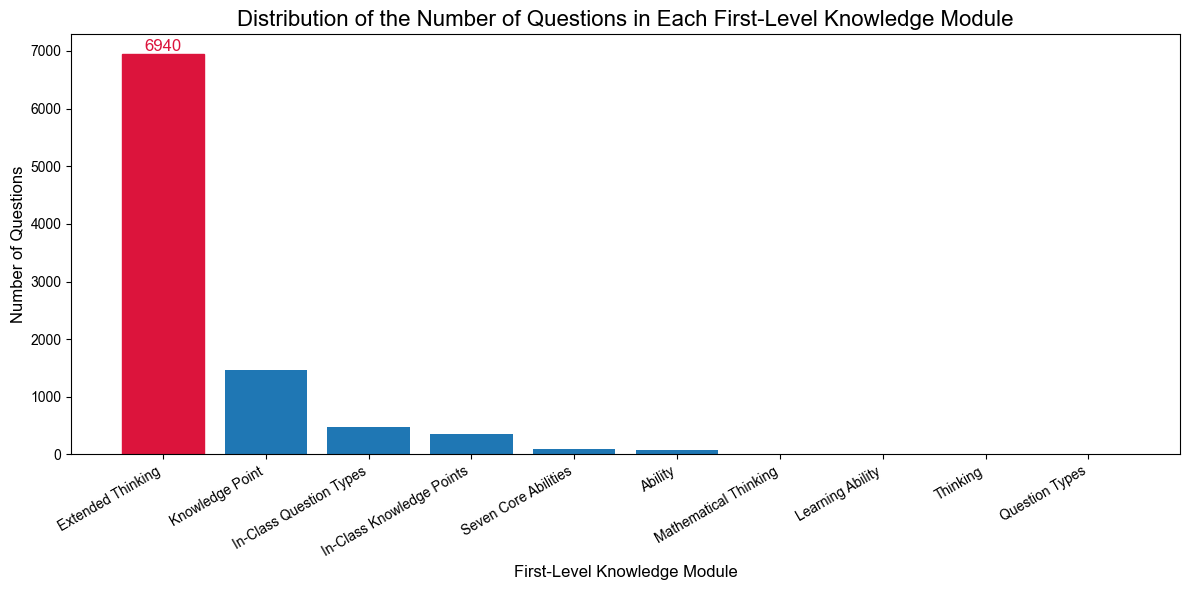

In [5]:
import json
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Arial']  # Set to English font
plt.rcParams['axes.unicode_minus'] = False   # Display minus sign normally

# Chinese to English mapping
cn2en = {
    "拓展思维": "Extended Thinking",
    "知识点": "Knowledge Point",
    "课内题型": "In-Class Question Types",
    "课内知识点": "In-Class Knowledge Points",
    "七大能力": "Seven Core Abilities",
    "能力": "Ability",
    "数学思想": "Mathematical Thinking",
    "学习能力": "Learning Ability",
    "思想": "Thinking",
    "题型": "Question Types"
}

# 读取 kc_tree_with_qids.json
with open('./data/XES3G5M/metadata/kc_tree_with_qids.json', 'r', encoding='utf-8') as f:
    kc_tree = json.load(f)

# Extract first-level modules and their question counts
first_level = kc_tree['children']
module_names = []
num_questions = []
for name, node in first_level.items():
    translated_name = cn2en.get(name, name)  # If no translation available, keep original name
    module_names.append(translated_name)
    num_questions.append(len(node['qids']))

# Sort by question count in descending order
sorted_data = sorted(zip(module_names, num_questions), key=lambda x: x[1], reverse=True)
module_names, num_questions = zip(*sorted_data)

# Visualization
plt.figure(figsize=(12,6))
bars = plt.bar(module_names, num_questions, color=['#FF7F0E' if n == max(num_questions) else '#1F77B4' for n in num_questions])
plt.title('Distribution of the Number of Questions in Each First-Level Knowledge Module', fontsize=16)
plt.xlabel('First-Level Knowledge Module', fontsize=12)
plt.ylabel('Number of Questions', fontsize=12)
plt.xticks(rotation=30, ha='right')

# 高亮“Extended Thinking”
for bar, name in zip(bars, module_names):
    if name == 'Extended Thinking':
        bar.set_color('crimson')
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{bar.get_height()}', ha='center', va='bottom', fontsize=12, color='crimson')

plt.tight_layout()
plt.show()


Due to the uneven distribution of secondary and subsequent level nodes in the previous cell, we only select first-level nodes.

Since the first-level nodes are unevenly distributed, we only select the "Extended Thinking" module.

### 1.2.2 Remove duplicates and sort all submodules under "Thinking Expansion"

In [6]:
# Get and iterate through all submodules under "Thinking Expansion"
# For each submodule, collect all question IDs under that module, sort them, remove duplicates, and print them
# Count the number of questions

creative_thinking_node = kc_tree['children']['拓展思维']

print("\n" + "="*50)
print("Processing submodules under 'Extended Thinking'...")
print("="*50)

# Define a recursive function to collect all question IDs under a node and all its child nodes
def collect_all_qids(node_data):
    """
    Recursively collect all question IDs under a node.
    """
    # Use a set to automatically handle duplicate IDs
    qids_set = set(node_data.get('qids', []))

    # Recursively traverse child nodes and update the set
    for child_data in node_data.get('children', {}).values():
        qids_set.update(collect_all_qids(child_data))

    return qids_set

# Iterate through each submodule under "Extended Thinking"
all_tuo_qid=[]
for module_name, module_data in creative_thinking_node.get('children', {}).items():

    # 1. Collect all question IDs under this module
    all_module_qids = collect_all_qids(module_data)

    # 2. Convert set to sorted list
    final_qid_list = sorted(list(all_module_qids), key=int)
    all_tuo_qid+= final_qid_list
    # 3. Print module information
    print(f"\n--- Module: {module_name} ---")
    print(f"Total questions: {len(final_qid_list)}")
    print(f"Question ID list (qid):")
    print(final_qid_list)

print("\n" + "="*50)
all_tuo_qid=set(all_tuo_qid)  # Remove duplicates
all_tuo_qid=list(all_tuo_qid)  # Convert to list
print("Total number of question IDs under 'Extended Thinking':", len(all_tuo_qid))
print("All question IDs under 'Extended Thinking':")
print(all_tuo_qid)



Processing submodules under 'Extended Thinking'...

--- Module: 计数模块 ---
Total questions: 1141
Question ID list (qid):
['0', '1', '2', '3', '4', '5', '6', '7', '66', '67', '69', '70', '102', '106', '126', '127', '129', '130', '139', '140', '141', '143', '144', '145', '146', '147', '260', '261', '262', '269', '271', '292', '293', '357', '361', '367', '368', '370', '371', '372', '392', '393', '394', '395', '396', '398', '399', '400', '406', '411', '412', '413', '415', '416', '422', '423', '424', '425', '426', '427', '428', '429', '430', '431', '432', '433', '434', '435', '436', '437', '443', '444', '445', '451', '453', '454', '455', '456', '457', '458', '459', '460', '491', '492', '493', '494', '495', '496', '501', '502', '503', '504', '505', '506', '507', '508', '670', '671', '672', '673', '674', '675', '676', '779', '780', '781', '782', '783', '784', '785', '786', '791', '792', '793', '794', '802', '808', '809', '810', '820', '821', '822', '823', '824', '825', '844', '845', '846', '84

This step is to circle the target question bank and check the consistency: lock the "extended thinking" from the knowledge tree, recursively collect the QIDS of all the questions according to the sub modules, print the question quantity and list of each sub module after removing the duplicate and sorting, and finally summarize the complete question set and total number of the field. In this way, you will get the set of candidate questions to be used for subsequent data cleaning and modeling, which can filter the training set and test set accordingly, and only keep the records related to extended thinking. The incidental count and list output is also equivalent to a data physical examination, which is used to check whether the tree structure is correct, whether there are duplicates or omissions, and to lay the foundation for subsequent Qid → module mapping, module level statistics and recommended candidate set construction.

### 1.2.3 Only retain users who have learned the "Extended Thinking" module

In [7]:
# Use the loaded train_valid_sequences.csv file
# Only retain answers for questions that contain "Expanding Thinking" questions
# Save to the filtered_train_data variable

import pandas as pd
# FIX: Changed from tqdm.notebook to the standard tqdm to avoid ipywidgets dependency
from tqdm import tqdm

# Assuming train_data (DataFrame) and all_tuo_qid (list) variables already exist in your environment

# --- Preparation ---
# For optimal performance, we convert all_tuo_qid to a set and ensure that the ID is a string type for comparison.
try:
    all_tuo_qid_set = set(str(qid) for qid in all_tuo_qid)  # Convert the previously collected "Expanding Thinking" question IDs into a set to improve search efficiency
    print(f"Successfully converted all_tuo_qid into a set, containing {len(all_tuo_qid_set)} unique question IDs.")
except NameError:
    print("Error: Variable 'all_tuo_qid' does not exist. Make sure you have run the code that generated it.")
    all_tuo_qid_set = None

# --- Filter function ---
def filter_sequences_in_dataframe(df, target_qids_set):
    if target_qids_set is None:
        return None

    # Define the sequence columns that need to be filtered synchronously
    sequence_cols = ['questions', 'concepts', 'responses', 'timestamps', 'selectmasks', 'is_repeat']

    # Check if the required column exists (Create a copy to modify the list while iterating)
    for col in sequence_cols[:]:
        if col not in df.columns:
            print(f"Warning: Column '{col}' not found in train_data, processing of this column will be skipped.")
            sequence_cols.remove(col)

    processed_rows = []

    print("\nFiltering answer records line by line...")
    # Use tqdm to display the progress bar
    for index, row in tqdm(df.iterrows(), total=len(df)):
        new_row = row.copy()

        # Split the question sequence string into a list
        questions_list = str(row['questions']).split(',')

        # Create a Boolean mask to mark which questions need to be retained
        keep_mask = [qid in target_qids_set for qid in questions_list]

        # If there is no question to keep, skip this line
        if not any(keep_mask) :
            continue

        # Apply the mask to all sequence columns
        for col in sequence_cols:
            original_list = str(row[col]).split(',')

            # Ensure that the list lengths are consistent to prevent data misalignment
            if len(original_list) == len(questions_list):
                filtered_list = [item for item, keep in zip(original_list, keep_mask) if keep]
                new_row[col] = ','.join(filtered_list)
            else:
                # If a sequence length on a line does not match, print a warning but continue processing
                print(f"Warning: At row {index}, the number of elements in column '{col}' ({len(original_list)}) does not match the number of elements in the 'questions' column ({len(questions_list)}).")

        processed_rows.append(new_row)

    # Create a new DataFrame from the processed rows
    if not processed_rows:
        print("\nNo data left after filtering.")
        return pd.DataFrame()
    else:
        return pd.DataFrame(processed_rows).reset_index(drop=True)

# --- Execute filter ---
if 'train_data' in locals() and all_tuo_qid_set is not None:
    print(f"\nBefore filtering, train_data has a total of {len(train_data)} rows.")

    # Execute the filter function
    filtered_train_data = filter_sequences_in_dataframe(train_data, all_tuo_qid_set)

    print("\n" + "="*50)
    print("Filtering completed!")
    print(f"After filtering, filtered_train_data has {len(filtered_train_data)} rows.")
    print("(The number of rows is reduced because some users' answers do not belong to the \"Expanding Thinking\" section and are therefore excluded.)")
    print("\nFiltered data sample (first 5 rows):")
    print(filtered_train_data.head())
    print("="*50)

else:
    print("Error: Variable 'train_data' does not exist. Make sure you have loaded the data.")


Successfully converted all_tuo_qid into a set, containing 6940 unique question IDs.

Before filtering, train_data has a total of 33397 rows.

Filtering answer records line by line...


  0%|          | 0/33397 [00:00<?, ?it/s]

100%|██████████| 33397/33397 [00:04<00:00, 7124.92it/s]



Filtering completed!
After filtering, filtered_train_data has 33392 rows.
(The number of rows is reduced because some users' answers do not belong to the "Expanding Thinking" section and are therefore excluded.)

Filtered data sample (first 5 rows):
   fold    uid                                          questions  \
0     0  11066  3751,3752,3753,3754,1990,3739,3740,3742,3756,3...   
1     0  11066  95,4294,4294,4300,4300,4301,4302,4308,115,130,...   
2     0  14482  266,268,2203,870,2587,2323,2588,5194,868,868,8...   
3     0  14482  1280,1046,405,404,404,4623,4622,4622,4624,4954...   
4     0  10532  268,266,2203,2588,2587,2323,275,811,2205,2205,...   

                                            concepts  \
0  187,187,374,187,374,188,188,228,166,170,221,40...   
1  63,64,102,659,376,147,147,65,64,78,81,468,78,7...   
2  9,139,140,9,232,231,231,146,145,231,31,65,62,6...   
3  257,32,204,204,205,206,526,206,206,206,206,207...   
4  139,9,140,231,232,231,30,30,62,65,62,65,152,15...  

Analyze and visualize the distribution of the number of user answers

Descriptive statistics of the number of questions for all users (including detailed percentiles):
count    33392.000000
mean       139.949000
std         58.647272
min          1.000000
10%         43.000000
25%         88.000000
50%        175.000000
75%        185.000000
90%        191.000000
95%        194.000000
99%        197.000000
max        200.000000
Name: questions, dtype: float64

Generating the histogram of the number of questions...


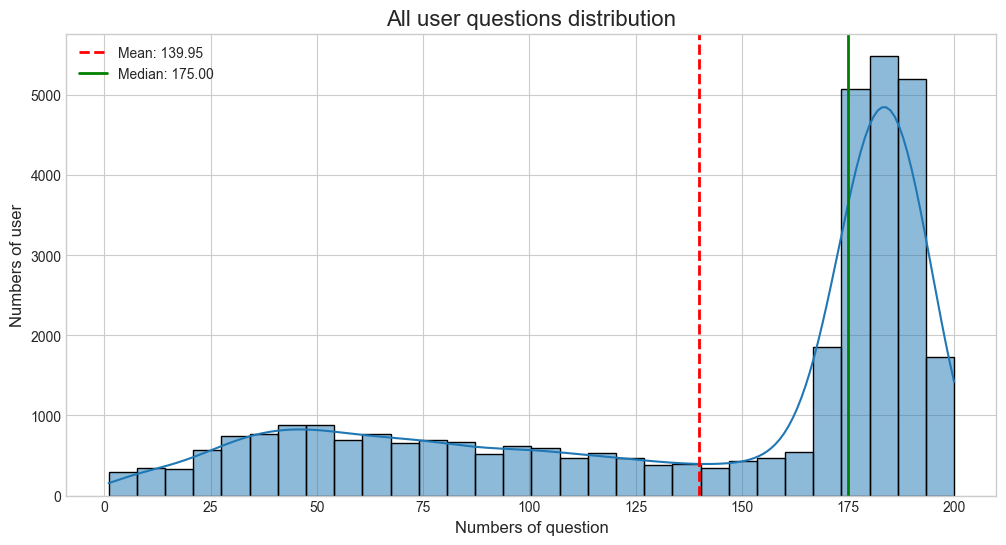


Generating question number distribution pie chart...


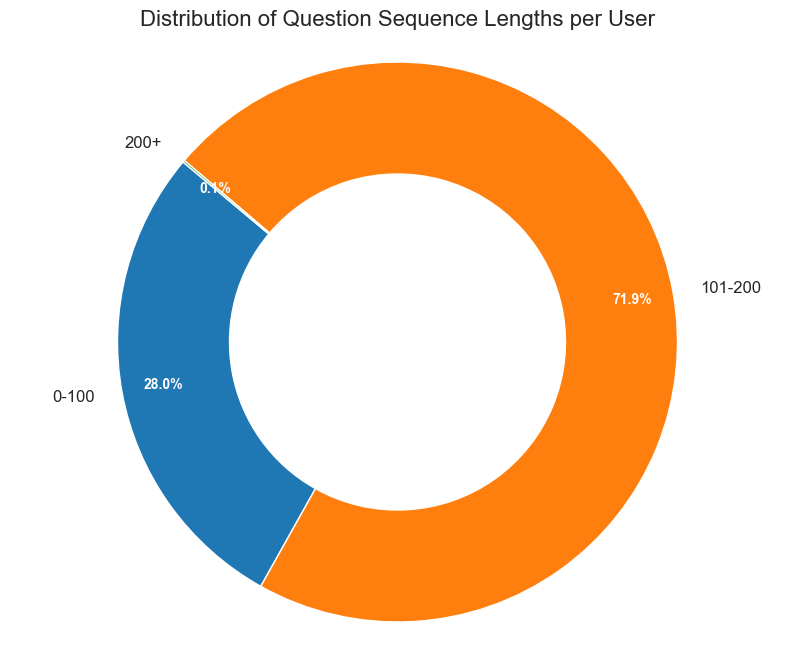

In [8]:
# Analyze and visualize the distribution of the number of user answers

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
display(HTML("<style>.output_wrapper, .output {height:auto !important; max-height:10000px !important;}</style>"))
# Ensure the filtered_train_data variable exists
if 'filtered_train_data' in locals() and not filtered_train_data.empty:

    # Step 1: Count the number of questions per user (per row)
    question_lengths = filtered_train_data['questions'].apply(lambda x: len(str(x).split(',')))

    # Step 2: Print descriptive statistics with detailed percentages
    print("="*50)
    print("Descriptive statistics of the number of questions for all users (including detailed percentiles):")
    print("="*50)
    percentiles_to_show = [0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    print(question_lengths.describe(percentiles=percentiles_to_show))

    # Step 3: Visualize the distribution (histogram)
    print("\n" + "="*50)
    print("Generating the histogram of the number of questions...")
    print("="*50)

    plt.style.use('seaborn-v0_8-whitegrid')
    plt.figure(figsize=(12, 6))
    sns.histplot(question_lengths, kde=True, bins=30)
    plt.title('All user questions distribution', fontsize=16)
    plt.xlabel('Numbers of question', fontsize=12)
    plt.ylabel('Numbers of user', fontsize=12)
    plt.axvline(question_lengths.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {question_lengths.mean():.2f}')
    plt.axvline(question_lengths.median(), color='green', linestyle='-', linewidth=2, label=f'Median: {question_lengths.median():.2f}')
    plt.legend()
    plt.show()

    # Step 4: Pie chart
    print("\n" + "="*50)
    print("Generating question number distribution pie chart...")
    print("="*50)

    # Modify group boundaries and labels
    bins = [0, 100, 200, float('inf')]
    labels = ['0-100', '101-200', '200+']
    length_categories = pd.cut(question_lengths, bins=bins, labels=labels, right=False)
    pie_data = length_categories.value_counts().sort_index()

    plt.figure(figsize=(10, 8))
    wedges, texts, autotexts = plt.pie(
        pie_data,
        labels=pie_data.index,
        autopct='%1.1f%%',
        startangle=140,
        pctdistance=0.85,
        wedgeprops=dict(width=0.4, edgecolor='w')
    )
    plt.title('Distribution of Question Sequence Lengths per User', fontsize=16)
    plt.setp(autotexts, size=10, weight="bold", color="white")
    plt.setp(texts, size=12)
    plt.axis('equal')
    plt.show()

else:
    print("Error: Variable 'filtered_train_data' does not exist or is empty. Make sure you have successfully run the previous filtering code.")




Filter users with 120 or more questions for the following reasons:

- 120 questions are more likely to cover multiple knowledge points, helping the model learn the connections between them.

 - 120 questions provide sufficient data points to identify student learning patterns and trends in knowledge mastery.

Filter users with a gap of less than 90 days between answers for the following reasons:

- A gap of more than 90 days may indicate a long period of inactivity, potentially leading to fundamental changes in the student's knowledge base.

### 1.2.4 Filter users

QUESTIONS with less than 120 will be eliminated

In [9]:
import pandas as pd
from tqdm import tqdm

# Assuming the train_data (DataFrame) and all_tuo_qid (list) variables already exist in your environment

# --- Preparation ---
# For best performance, we convert all_tuo_qid to a set and ensure that the ID is a string type for comparison
try:
    all_tuo_qid_set = set(str(qid) for qid in all_tuo_qid)
    print(f"Successfully converted all_tuo_qid into a set, containing {len(all_tuo_qid_set)} unique question IDs.")
except NameError:
    print("Error: Variable 'all_tuo_qid' does not exist. Make sure you have run the code that generated it.")
    all_tuo_qid_set = None

# --- New configuration: Minimum length of the filtered sequence ---
# If a user has fewer than this number of questions in "Expand Your Mind," their record will be removed.

MIN_QUESTIONS_AFTER_FILTER = 120

# --- Filter function ---
def filter_sequences_in_dataframe(df, target_qids_set):
    if target_qids_set is None:
        return None

    # Define the sequence columns that need to be filtered synchronously
    sequence_cols = ['questions', 'concepts', 'responses', 'timestamps', 'selectmasks', 'is_repeat']

    # Check if the required column exists (Create a copy to modify the list while iterating)
    for col in sequence_cols[:]:
        if col not in df.columns:
            print(f"Warning: Column '{col}' not found in train_data, processing of this column will be skipped.")
            sequence_cols.remove(col)

    processed_rows = []

    print("\nFiltering answer records line by line...")
    # Use tqdm to display the progress bar
    for index, row in tqdm(df.iterrows(), total=len(df)):
        new_row = row.copy()

        # Split the question sequence string into a list
        questions_list = str(row['questions']).split(',')

        # Create a Boolean mask to mark which questions to keep
        keep_mask = [qid in target_qids_set for qid in questions_list]

        # --- New filtering logic ---
        # If the length of a user's question sequence is less than the threshold after filtering, remove the user (skip this row)
        if sum(keep_mask) < MIN_QUESTIONS_AFTER_FILTER:
            continue

        # If there are no questions to keep, skip this line (this check is now redundant, but it doesn't hurt to keep it)
        if not any(keep_mask):
            continue

        # Apply the mask to all sequence columns
        for col in sequence_cols:
            original_list = str(row[col]).split(',')

            # Ensure that the list lengths are consistent to prevent data misalignment
            if len(original_list) == len(questions_list):
                filtered_list = [item for item, keep in zip(original_list, keep_mask) if keep]
                new_row[col] = ','.join(filtered_list)
            else:
                # If a sequence length on a line does not match, print a warning but continue processing
                print(f"Warning: At row {index}, the number of elements in column '{col}' ({len(original_list)}) does not match the number of elements in the 'questions' column ({len(questions_list)}).")

        processed_rows.append(new_row)

    # Create a new DataFrame from the processed rows
    if not processed_rows:
        print("\nNo data left after filtering.")
        return pd.DataFrame()
    else:
        return pd.DataFrame(processed_rows).reset_index(drop=True)

# --- Execute filter ---
if 'train_data' in locals() and all_tuo_qid_set is not None:
    print(f"\nBefore filtering, train_data has {len(train_data)} rows.")

    # Execute the filtering function
    filtered_train_data = filter_sequences_in_dataframe(train_data, all_tuo_qid_set)

    print("\n" + "="*50)
    print("Filtering completed!")
    print(f"After filtering, filtered_train_data has {len(filtered_train_data)} rows.")
    print(f"(The number of rows is reduced because some users' answers do not belong to the \"Expand Your Thinking\" section, or the number of relevant questions is less than {MIN_QUESTIONS_AFTER_FILTER}, so they are removed.)")
    print("\nData sample after filtering (first 5 rows):")
    print(filtered_train_data.head())
    print("="*50)

else:
    print("Error: Variable 'train_data' does not exist. Make sure you have loaded the data.")

Successfully converted all_tuo_qid into a set, containing 6940 unique question IDs.

Before filtering, train_data has 33397 rows.

Filtering answer records line by line...


100%|██████████| 33397/33397 [00:03<00:00, 8512.05it/s]



Filtering completed!
After filtering, filtered_train_data has 22449 rows.
(The number of rows is reduced because some users' answers do not belong to the "Expand Your Thinking" section, or the number of relevant questions is less than 120, so they are removed.)

Data sample after filtering (first 5 rows):
   fold    uid                                          questions  \
0     0  11066  3751,3752,3753,3754,1990,3739,3740,3742,3756,3...   
1     0  14482  266,268,2203,870,2587,2323,2588,5194,868,868,8...   
2     0  10532  268,266,2203,2588,2587,2323,275,811,2205,2205,...   
3     0  14264  12,2312,2312,1320,1320,2311,2310,2310,863,862,...   
4     0  14264  345,345,343,954,346,1175,1177,1179,1176,1171,1...   

                                            concepts  \
0  187,187,374,187,374,188,188,228,166,170,221,40...   
1  9,139,140,9,232,231,231,146,145,231,31,65,62,6...   
2  139,9,140,231,232,231,30,30,62,65,62,65,152,15...   
3  9,139,9,9,6,140,66,9,142,223,142,314,144,144,1... 

Filters records where the time difference between the first and last answer is greater than 90 days.

(timestamps: The regular start timestamp of the interaction, in milliseconds).

In [10]:
import pandas as pd
from tqdm import tqdm

# Assuming the filtered_train_data (DataFrame) variable already exists in your environment

# --- Second round of filtering configuration ---
# 1. Maximum length of each user sequence
MAX_LENGTH = 120
# 2. Maximum allowed time span (days)
MAX_DAYS = 90
# Convert days to milliseconds
MAX_TIME_DIFF_MS = MAX_DAYS * 24 * 60 * 60 * 1000

# --- Interception and time filtering functions ---
def truncate_and_filter_by_time(df):
    if df is None or df.empty:
        print("The input data is empty and cannot be processed.")
        return pd.DataFrame()

    # Define the sequence columns that need to be processed synchronously
    sequence_cols = ['questions', 'concepts', 'responses', 'timestamps', 'selectmasks', 'is_repeat']

    # Check if the required columns exist
    for col in sequence_cols[:]:
        if col not in df.columns:
            print(f"Warning: Column '{col}' not found in DataFrame, processing of this column will be skipped.")
            sequence_cols.remove(col)

    valid_rows = []

    print("\nSecond round of screening in progress (truncating length and verifying time span)...")
    for index, row in tqdm(df.iterrows(), total=len(df)):

        # --- Step 1: Truncate all sequences to the first 120 items ---
        truncated_row = row.copy()
        is_valid_row = True

        # First truncate the questions sequence and get its length
        questions_list = str(row['questions']).split(',')
        truncated_questions = questions_list[:MAX_LENGTH]

        # If there are no more questions after truncating, skip it
        if not truncated_questions:
            continue

        truncated_row['questions'] = ','.join(truncated_questions)

        #Synchronously intercept other attribute columns
        for col in sequence_cols:
            if col == 'questions': continue # questions column processed

            original_list = str(row[col]).split(',')
            if len(original_list) == len(questions_list):
                truncated_list = original_list[:MAX_LENGTH]
                truncated_row[col] = ','.join(truncated_list)
            else:
                print(f"Warning: At row {index}, length of column '{col}' does not match 'questions' column.")
                is_valid_row = False
                break

        if not is_valid_row:
            continue

        # --- Step 2: Verify that the timestamp span is within 90 days ---
        timestamps_str_list = truncated_row['timestamps'].split(',')

        # Check the timestamp span only if the sequence length is greater than 1
        if len(timestamps_str_list) > 1:
            try:
                first_timestamp = int(timestamps_str_list[0])
                last_timestamp = int(timestamps_str_list[-1])

                time_difference = last_timestamp - first_timestamp

                # If the time difference is greater than 90 days, the record will be removed
                if time_difference > MAX_TIME_DIFF_MS:
                    continue
            except (ValueError, IndexError) as e:
                print(f"Warning: Error processing timestamp at line {index}: {e}. This line will be skipped.")
                continue

        # If all checks pass, add the processed row to the result list
        valid_rows.append(truncated_row)

    # Create a new DataFrame from the processed rows
    if not valid_rows:
        print("\nNo data left after processing.")
        return pd.DataFrame()
    else:
        return pd.DataFrame(valid_rows).reset_index(drop=True)

# --- Execute filter ---
if 'filtered_train_data' in locals() and not filtered_train_data.empty:
    print(f"\nBefore the second round of filtering, the data contains {len(filtered_train_data)} rows.")

    # Execute the filtering function
    final_data = truncate_and_filter_by_time(filtered_train_data)

    print("\n" + "="*50)
    print("Second round of processing completed!")
    print(f"The final data contains {len(final_data)} rows.")
    print(f"(The number of rows is reduced because some users' answer sequences spanned more than {MAX_DAYS} days and were removed.)")
    print("\nFinal data sample (first 5 rows):")
    print(final_data.head())
    print("="*50)

else:
    print("Error: Variable 'filtered_train_data' does not exist or is empty. Make sure you have run the previous code successfully.")





Before the second round of filtering, the data contains 22449 rows.

Second round of screening in progress (truncating length and verifying time span)...


100%|██████████| 22449/22449 [00:02<00:00, 10813.22it/s]



Second round of processing completed!
The final data contains 10382 rows.
(The number of rows is reduced because some users' answer sequences spanned more than 90 days and were removed.)

Final data sample (first 5 rows):
   fold   uid                                          questions  \
0     0  9375  501,502,503,2031,2032,504,2033,2034,2035,2037,...   
1     0  9375  2094,2094,1711,1711,2097,2098,2099,607,608,210...   
2     0  2128  5251,5251,5250,5250,824,825,825,823,846,847,80...   
3     0   142  2208,2436,2435,2435,2435,2434,291,2801,2799,28...   
4     0  1853  2313,2318,2318,2328,2328,826,2310,2310,1320,13...   

                                            concepts  \
0  243,243,243,2,2,244,244,313,313,313,477,313,47...   
1  435,263,435,263,262,263,264,265,168,168,102,16...   
2  11,139,11,139,142,117,144,142,314,142,144,142,...   
3  155,155,155,243,246,155,55,155,155,155,155,155...   
4  142,231,232,497,488,308,66,9,9,6,140,139,9,9,1...   

                               

This step is the second round of data cleaning and standardization: the multi column sequence of each user is synchronously truncated to 120 steps to ensure that the length between columns is consistent, and the time span of more than 90 days and abnormal lines are eliminated, so as to obtain a high-quality sample set final_data with uniform length, time consistency and field alignment, and output an overview for subsequent ID mapping, sequence segmentation and model training.

### 1.2.5 Merge the variables in the two files into the final data

In [11]:

import pandas as pd
from tqdm import tqdm
import json


# --- 1. Create a mapping from qid to module_name ---
print("Starting to create a mapping from 'question_id' to 'module_name'...")

# Check if final_data exists
if 'final_data' not in locals() or final_data.empty:
    print("Error: Variable 'final_data' does not exist or is empty. Please run the previous code step first.")
else:
    questions_path = 'data/XES3G5M/metadata/questions.json'
    qid_to_module_map = {}

    try:
        with open(questions_path, 'r', encoding='utf-8') as f:
            questions_data = json.load(f)

        # Traverse all questions and extract the expansion thinking module to which they belong
        for qid, details in questions_data.items():
            routes = details.get('kc_routes', [])
            for path in routes:
                parts = path.split('----')
                # Make sure the path is under extended thinking and has at least two levels
                if parts[0] == '拓展思维' and len(parts) > 1:
                    # We use the first submodule as the module for this question.
                    # If a question belongs to multiple modules, only the first one is used here. Adjust as needed.
                    qid_to_module_map[qid] = parts[1]
                    break # Exit the loop when the first one is found.

        print(f"Mapping created, processing {len(qid_to_module_map)} questions in total.")

        # --- 2. Define a function to convert the sequence ---
        def map_qids_to_modules(qids_str):
            """
            Receives a comma-delimited qid string and returns a comma-delimited module_name string.
            """
            qids = qids_str.split(',')
            # Use .get(qid, 'Unknown Module') to handle the case where qid is not in the map
            modules = [qid_to_module_map.get(qid, 'Unknown Module') for qid in qids]
            return ','.join(modules)

        # --- 3. Apply the transformation and replace the 'concepts' column ---
        print("\nReplacing the 'concepts' column with the module name...")

        # Use the .apply() method to efficiently process each row
        # This directly modifies the final_data DataFrame
        final_data['concepts'] = final_data['questions'].apply(map_qids_to_modules)

        print("\n" + "="*50)
        print("Replacement completed!")
        print("The 'concepts' column is now updated with the corresponding module name.")
        print("\nUpdated data sample (first 5 rows):")
        print(final_data.head())
        print("="*50)

    except FileNotFoundError:
        print(f"Error: Unable to find file at path '{questions_path}'.")
    except Exception as e:
        print(f"Error: {e}")



Starting to create a mapping from 'question_id' to 'module_name'...
Mapping created, processing 6940 questions in total.

Replacing the 'concepts' column with the module name...

Replacement completed!
The 'concepts' column is now updated with the corresponding module name.

Updated data sample (first 5 rows):
   fold   uid                                          questions  \
0     0  9375  501,502,503,2031,2032,504,2033,2034,2035,2037,...   
1     0  9375  2094,2094,1711,1711,2097,2098,2099,607,608,210...   
2     0  2128  5251,5251,5250,5250,824,825,825,823,846,847,80...   
3     0   142  2208,2436,2435,2435,2435,2434,291,2801,2799,28...   
4     0  1853  2313,2318,2318,2328,2328,826,2310,2310,1320,13...   

                                            concepts  \
0  计数模块,计数模块,计数模块,计数模块,计数模块,计数模块,计数模块,计数模块,计数模块,计...   
1  组合模块,组合模块,组合模块,组合模块,组合模块,组合模块,组合模块,应用题模块,应用题模块...   
2  几何模块,几何模块,几何模块,几何模块,计数模块,数论模块,数论模块,计数模块,计数模块,计...   
3  计数模块,计数模块,计数模块,计数模块,计数模块,计数模块,应用题模块,计数模块,计数模块,...   

This step is to do concept aggregation and column Standardization: locate each question from questions.json to the first sub module under extended thinking, establish a mapping table from question to module, and then map the questions in final_data one by one into a sequence of module names and directly overwrite concepts. In this way, the fine-grained knowledge points are summarized to the module level, which can reduce the dimension, reduce the sparsity, unify the semantics and enhance the interpretability. At the same time, the robustness of data processing is ensured by using the unknown module and exception capture, providing consistent conceptual input for subsequent modeling and evaluation.

### 1.2.6 Final data accuracy analysis

In [12]:
# Analyze the accuracy of the answers in final_data (10,382 rows)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Check if final_data exists
if 'final_data' in locals() and not final_data.empty:
    print(f"Found final_data, shape: {final_data.shape}")
    
    # 1. Calculate the accuracy of each user's answers
    def calc_accuracy(row):
        responses = [int(x) for x in str(row['responses']).split(',')]
        return sum(responses) / len(responses) if len(responses) > 0 else 0

    final_data['accuracy'] = final_data.apply(calc_accuracy, axis=1)

    # 2. Print descriptive statistics
    print("="*50)
    print("Descriptive statistics of user's correct answer rate：")
    print("="*50)
    print(final_data['accuracy'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]))

else:
    print("Error: Variable 'final_data' does not exist or is empty.")
    print("Please run the 90-day time filter code first to create final_data.")

Found final_data, shape: (10382, 8)
Descriptive statistics of user's correct answer rate：
count    10382.000000
mean         0.803972
std          0.132876
min          0.066667
10%          0.625000
25%          0.733333
50%          0.833333
75%          0.900000
90%          0.950000
95%          0.966667
99%          0.991667
max          1.000000
Name: accuracy, dtype: float64


#### dataset part completed

Now we have the filtered data, stored in the final_data variable.

`final_data` has the following attributes: 

- `fold`
- `uid`
- `questions`
- `concepts`
- `responses`
- `timestamps`
- `selectmasks`
- `is_repeat`

# 2 ADGKT and DKT

## 2.1 ADGKT


### 2.1.1 Import the necessary libraries and set the hyperparameters.

In [19]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
import warnings

warnings.filterwarnings('ignore')

# --- Model and Training Configuration ---
class TrainingConfig:
    TRAIN_RATIO = 0.8
    MAX_SEQ_LEN = 120 # Should match the sequence length you truncated to
    EMBED_SIZE = 128
    HIDDEN_SIZE = 128
    NUM_HEADS = 4 # Can be adjusted based on computational resources
    DROPOUT = 0.2
    EPOCHS = 10 # Start with a smaller number to see results quickly
    BATCH_SIZE = 32
    LEARNING_RATE = 0.001

config = TrainingConfig()
# ===== 额外添加的 AUC 曲线图生成代码 =====
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
 


This step is to build a training environment and centrally configure the superparameters: import the dependencies required for training and evaluation and mask warnings, define trainingconfig and set the training verification ratio of 0.8/0.2, sequence length of 120, embedded and hidden dimensions of 128, number of attention heads of 4 dropout 0.2、 10 rounds of training batch size 32、 Key parameters such as learning rate 0.001; At the same time, Matplotlib and numpy are introduced to prepare for the subsequent drawing and verification of AUC curves. The overall function is to declare the global configuration required for training at one time, which is convenient for subsequent model training and visualization.

### 2.1.2 Data preparation

In [20]:
print("Preparing data for the model...")

# Create mappings from original string IDs to continuous integer IDs for the embedding layers
all_qids = set()
final_data['questions'].str.split(',').apply(all_qids.update)
# Sort IDs as integers to ensure correct ordering
qid_map = {qid: i for i, qid in enumerate(sorted(list(all_qids), key=int))}
num_questions = len(qid_map)

# The 'concepts' are now module names. We map them to integers as well.
all_concepts = set()
final_data['concepts'].str.split(',').apply(all_concepts.update)
cid_map = {cid: i for i, cid in enumerate(sorted(list(all_concepts)))}
num_concepts = len(cid_map)

print(f"After mapping: Unique Questions: {num_questions}, Unique Concepts (Modules): {num_concepts}")

train_sequences = []
test_sequences = []

print("Splitting each user's sequence into training and testing sets...")
for index, row in tqdm(final_data.iterrows(), total=len(final_data)):
    q_list = str(row['questions']).split(',')
    c_list = str(row['concepts']).split(',')
    r_list = str(row['responses']).split(',')

    # Create a temporary DataFrame for a single user's sequence
    temp_df = pd.DataFrame({
        'question_id': [qid_map.get(q) for q in q_list],
        'concept_id': [cid_map.get(c) for c in c_list],
        'responses': [int(r) for r in r_list]
    })
    temp_df.dropna(inplace=True)
    temp_df = temp_df.astype(int)

    # Split into 80% training and 20% testing
    split_point = int(len(temp_df) * config.TRAIN_RATIO)
    train_df = temp_df.iloc[:split_point]
    test_df = temp_df.iloc[split_point:]

    if len(train_df) > 1:
        train_sequences.append(train_df)
    if len(test_df) > 1:
        test_sequences.append(test_df)

Preparing data for the model...
After mapping: Unique Questions: 5772, Unique Concepts (Modules): 7
Splitting each user's sequence into training and testing sets...


100%|██████████| 10382/10382 [00:04<00:00, 2513.52it/s]


This step is to turn the original table into a chronological sample that can be fed to the model: first, collect and map the topic ID and module name globally as a continuous integer index for the convenience of subsequent embedded layers; Then, user by user will synchronously expand the answers of the question module into a sequence data frame according to the time, and complete the integer and missing cleaning; Finally, eight two order preserving segmentation is done according to time, and the training sequence and test sequence are obtained, which is ready for the subsequent construction of pytorch data set and the training and evaluation of knowledge tracking model.

### 2.1.3  PyTorch Dataset & DataLoader ---

In [21]:
class KTDataset(Dataset):
        def __init__(self, sequences, max_seq_len):
            self.sequences = sequences
            self.max_seq_len = max_seq_len

        def __len__(self):
            return len(self.sequences)

        def __getitem__(self, index):
            seq = self.sequences[index]
            seq_len = len(seq)

            q_seq = np.zeros(self.max_seq_len, dtype=int)
            c_seq = np.zeros(self.max_seq_len, dtype=int)
            r_seq = np.zeros(self.max_seq_len, dtype=int)

            # Pad sequences from the left
            if seq_len >= self.max_seq_len:
                q_seq[:] = seq['question_id'].values[-self.max_seq_len:]
                c_seq[:] = seq['concept_id'].values[-self.max_seq_len:]
                r_seq[:] = seq['responses'].values[-self.max_seq_len:]
            else:
                q_seq[-seq_len:] = seq['question_id'].values
                c_seq[-seq_len:] = seq['concept_id'].values
                r_seq[-seq_len:] = seq['responses'].values

            input_q = q_seq[:-1]
            input_c = c_seq[:-1]
            input_r = r_seq[:-1]

            target_q = q_seq[1:]
            target_c = c_seq[1:]
            labels = r_seq[1:]

            # Create a mask to ignore padded parts during loss calculation
            mask = (target_q > 0).astype(np.int8)

            return (torch.LongTensor(input_q), torch.LongTensor(input_c), torch.LongTensor(input_r),
                    torch.LongTensor(target_q), torch.LongTensor(target_c), torch.LongTensor(labels),
                    torch.FloatTensor(mask))

train_dataset = KTDataset(train_sequences, config.MAX_SEQ_LEN)
test_dataset = KTDataset(test_sequences, config.MAX_SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=0)

print("\nPyTorch DataLoaders created successfully.")



PyTorch DataLoaders created successfully.


This step is to process the "variable length user interaction sequence" into a fixed length Supervision sample that can be trained by the model and package it into an iterative data stream: fill each user sequence to a fixed length, cut out the historical input_q/input_c/input_r and the corresponding target_q/target_c/labels for the next step, generate a mask to ignore the filling bits when calculating the loss and evaluation, and then organize it into training sets and test sets output by batch with dataloader, so as to facilitate the sequence modeling and evaluation of "predict the next step with the previous step" on GPU efficiently.

### 2.1.4 ADGKT Model definition

In [22]:
class ADGKT(nn.Module):
        def __init__(self, num_q, num_c, embed_size, hidden_size, num_heads, dropout):
            super(ADGKT, self).__init__()
            self.num_q = num_q
            self.num_c = num_c

            self.q_embed = nn.Embedding(num_q, embed_size)
            self.c_embed = nn.Embedding(num_c, embed_size)
            self.r_embed = nn.Embedding(2, embed_size) # For correct/incorrect responses

            self.interaction_fusion = nn.Linear(embed_size * 2, hidden_size)
            self.attention = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
            self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)

            self.predict_fusion = nn.Linear(hidden_size * 2, hidden_size)
            self.out = nn.Linear(hidden_size, 1)

            self.dropout = nn.Dropout(dropout)
            self.layer_norm1 = nn.LayerNorm(hidden_size)
            self.layer_norm2 = nn.LayerNorm(hidden_size)

        def forward(self, input_q, input_c, input_r, target_q, target_c):
            q_emb = self.q_embed(input_q)
            c_emb = self.c_embed(input_c)
            r_emb = self.r_embed(input_r)

            interaction_emb = self.interaction_fusion(torch.cat([q_emb, c_emb], dim=-1)) + r_emb

            attn_input = self.layer_norm1(interaction_emb)
            attn_output, _ = self.attention(attn_input, attn_input, attn_input)
            attn_output = self.dropout(attn_output) + interaction_emb

            gru_input = self.layer_norm2(attn_output)
            gru_output, _ = self.gru(gru_input)

            target_q_emb = self.q_embed(target_q)
            target_c_emb = self.c_embed(target_c)

            predict_input = torch.cat([gru_output, target_q_emb + target_c_emb], dim=-1)
            predict_hidden = torch.relu(self.predict_fusion(predict_input))

            output = self.out(predict_hidden)
            return torch.sigmoid(output).squeeze(-1)


This step is to define the core predictor adgkt: encode students' historical interaction into a dynamic "knowledge state", and predict the probability of "whether the next question is answered correctly" in combination with the target question and module at each time step. The specific approach is to use the three-way embedding of questions, modules and answers for interactive integration, self focus on long-term dependence, and grasp and forget Gru modeling over time; In the reading stage, the current "student status" and "target topic+module" are spliced to get the predicted score for the topic. The final output of the model is a sequence of correct answer probabilities in the form of [batch, seq_len-1]. During training, binary cross entropy is used to align the real labels. During reasoning, these probabilities are used to select the most likely wrong topics for personalized recommendation.

### 2.1.5 Model Training and Evaluation ---

In [23]:

print("\n--- Starting Model Training ---")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = ADGKT(num_questions, num_concepts, config.EMBED_SIZE, config.HIDDEN_SIZE, config.NUM_HEADS, config.DROPOUT).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=config.LEARNING_RATE)
criterion = nn.BCELoss()

# Initialize storage containers before training loop
train_losses = []  # Store the training loss for each epoch.
val_aucs = []     # Store the validation AUC for each epoch.
best_auc = 0.0     #Store the best AUC value
best_epoch = 0     # Store the epoch corresponding to the best AUC.
best_model_state = None  # Storing the state of the best model

for epoch in range(config.EPOCHS):
    model.train()
    total_loss = 0
    processed_batches = 0  # Used to count the number of batches actually processed.

    # training phase
    for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{config.EPOCHS} [Training]"):
        inputs = [item.to(device) for item in batch]
        input_q, input_c, input_r, target_q, target_c, labels, mask = inputs

        optimizer.zero_grad()
        preds = model(input_q, input_c, input_r, target_q, target_c)

        preds = preds[mask == 1]
        labels = labels[mask == 1].float()

        # Skip empty batches
        if preds.nelement() == 0: 
            continue

        loss = criterion(preds, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        processed_batches += 1
    
    #  Calculate and record the average training loss for this epoch.
    if processed_batches > 0:
        epoch_loss = total_loss / processed_batches
        train_losses.append(epoch_loss)
        print(f"\nEpoch {epoch+1} - Training Loss: {epoch_loss:.4f}")
    else:
        print(f"\nEpoch {epoch+1} - No training batches processed")
        train_losses.append(0.0)  # Add placeholder values
    
    # Verification phase
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f"Epoch {epoch+1}/{config.EPOCHS} [Evaluating]"):
            inputs = [item.to(device) for item in batch]
            input_q, input_c, input_r, target_q, target_c, labels, mask = inputs
            preds = model(input_q, input_c, input_r, target_q, target_c)
            preds = preds[mask == 1].cpu().numpy()
            labels = labels[mask == 1].cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels)
    
    # Calculate and record the validation AUC for this epoch.
    if len(all_preds) > 0:
        auc = roc_auc_score(all_labels, all_preds)
        val_aucs.append(auc)
        print(f"Epoch {epoch+1} - Validation AUC: {auc:.4f}")
        
        # Update the best model
        if auc > best_auc:
            best_auc = auc
            best_epoch = epoch + 1
            best_model_state = model.state_dict().copy()
            print(f"🔥 New best model found with AUC: {best_auc:.4f} at epoch {best_epoch}")
    else:
        val_aucs.append(0.0)   # Add placeholder values
        print(f"Epoch {epoch+1} - No predictions for validation AUC")

print("\n--- Model Training Completed ---")



--- Starting Model Training ---
Using device: cuda


Epoch 1/10 [Training]: 100%|██████████| 325/325 [00:03<00:00, 101.20it/s]



Epoch 1 - Training Loss: 0.3882


Epoch 1/10 [Evaluating]: 100%|██████████| 325/325 [00:01<00:00, 201.51it/s]


Epoch 1 - Validation AUC: 0.8643
🔥 New best model found with AUC: 0.8643 at epoch 1


...

Epoch 9 - Validation AUC: 0.9549
🔥 New best model found with AUC: 0.9549 at epoch 9


Epoch 10/10 [Training]: 100%|██████████| 325/325 [00:02<00:00, 112.17it/s]



Epoch 10 - Training Loss: 0.1592


Epoch 10/10 [Evaluating]: 100%|██████████| 325/325 [00:01<00:00, 317.68it/s]

Epoch 10 - Validation AUC: 0.9569
🔥 New best model found with AUC: 0.9569 at epoch 10

--- Model Training Completed ---


This step is to complete and record the training verification closed loop of adgkt: after selecting the equipment and instantiating the model, optimizer and loss, cycle according to the set number of rounds; In the training phase, the BCE loss is calculated by using mask==1 to filter the filling bits of the batch data forward, and then the BCE loss is updated in reverse and the average training loss of the current round is accumulated; In the verification phase, switch to the evaluation mode and no\u grad, take the effective position according to the mask, collect predictions and labels, and calculate and record the AUC of the current round of verification; If the current round of AUC refresh history is the best, update best_auc, best_epoch and cache the current state_dict as best_model_state. Final output: each round of train_losses, val_aucs and a "best weight" snapshot selected based on the validation AUC for subsequent visualization and deployment.

### 2.1.6 plot auc curve

Saved AUC curve plot: auc_curve.png


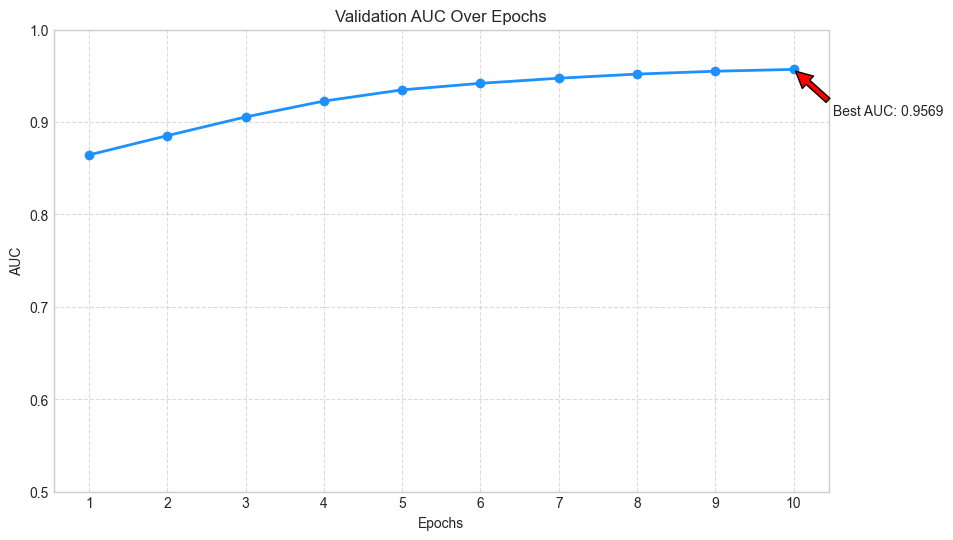


=== Training Summary ===
Best Validation AUC: 0.9569 at epoch 10
Final Training Loss: 0.1592
Final Validation AUC: 0.9569


In [24]:

# Create an AUC results list, one dict per round
adgkt_auc_summary = []

for epoch, auc in enumerate(val_aucs, start=1):
    adgkt_auc_summary.append({'epoch': epoch, 'val_auc': auc})

# Record the best results
best_result = {
    'best_epoch': best_epoch,
    'best_auc': best_auc,
    'final_train_loss': train_losses[-1],
    'final_val_auc': val_aucs[-1]
}

# AUC curve chart drawing
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(val_aucs)+1), val_aucs, 'o-', color='dodgerblue', linewidth=2)
plt.title('Validation AUC Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.ylim(0.5, 1.0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, len(val_aucs)+1))

# Mark the best AUC point
plt.annotate(f'Best AUC: {best_auc:.4f}',
             xy=(best_epoch, best_auc),
             xytext=(best_epoch + 0.5, best_auc - 0.05),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.savefig('auc_curve.png', dpi=300, bbox_inches='tight')
print("Saved AUC curve plot: auc_curve.png")
plt.show()


# Output training results summary
print("\n=== Training Summary ===")
print(f"Best Validation AUC: {best_auc:.4f} at epoch {best_epoch}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation AUC: {val_aucs[-1]:.4f}")

This step is to complete the three tasks of "recording, selecting and visualizing" in the training process of validation set AUC at one time: first, summarize the AUC of each epoch into a table, calculate the best AUC and its corresponding rounds in turn, and sort them into a summary; Then draw a broken line diagram of "validation AUC over epochs", mark the peak value with notes and save it as auc_curve.png; Finally, print the training summary (best AUC and round, training loss in the last round and validation AUC). The function is to directly watch the generalization trend of the model in the training process, quickly discover whether it converges or over fits, and determine the best checkpoint to save and subsequent loading.

## 2.2 DKT

Deep Knowledge Tracing (DKT)

Model Overview  

The Deep Knowledge Tracing (DKT) model is an LSTM-based neural architecture designed to predict a student's future performance based on their past interactions. Each input encodes the combination of question ID and student response (`question_id * 2 + response`), and the model outputs the probability of a correct response to the next question.

Model structure:

Embedding layer: nn.Embedding(num_q * 2, embed_size)
Recurrent layer: nn.LSTM(embed_size, hidden_size, batch_first=True)
Output layer: nn.Linear(hidden_size, num_q)

Training Configuration

| Parameter           | Value         |
| Dataset Split       | 80% train / 20% test (user-level) |
| Max Sequence Length | 120           |
| Epochs              | 10            |
| Optimizer           | Adam          |
| Learning Rate       | 0.001         |
| Loss Function       | BCEWithLogitsLoss |
| Evaluation Metric   | ROC-AUC       |
| Device              | CUDA (if available) |

Best Performance

Best Validation AUC: 0.8155 
Epoch: 10

### 2.2.1 DKT Data Processing

In [ ]:
def build_DKT(final_data, qid_map, max_seq_len=120, train_ratio=0.8):
    train_sequences = []
    test_sequences = []

    for _, row in final_data.iterrows():
        q_list = [qid_map[q] for q in str(row['questions']).split(',') if q in qid_map]
        r_list = [int(r) for r in str(row['responses']).split(',')]

        if len(q_list) < 2:
            continue

        df = pd.DataFrame({
            'question_id': q_list,
            'responses': r_list
        })

        split_point = int(len(df) * train_ratio)
        train_df = df.iloc[:split_point]
        test_df = df.iloc[split_point:]

        if len(train_df) > 1:
            train_sequences.append(train_df)
        if len(test_df) > 1:
            test_sequences.append(test_df)

    return train_sequences, test_sequences

This step is to sort out the cleaned user response records into DKT trainable time series samples: users take questions in chronological order one by one, map them into continuous indexes with qid_map, and form a sequence with the corresponding right and wrong tags; Less than two interactive samples are discarded; Then do the sequence preserving segmentation of 82, and enter the training set in the front section and the test set in the rear section to avoid future information leakage. Finally, two lists, train_sequences and test_sequences, are returned. Each element is a dataframe of the user, which can be directly handed over to dktdataset and DKT models. Note also that the max_seq_len parameter is not currently used.

### 2.2.2 DKT Dataset

In [ ]:
class DKTDataset(Dataset):
    def __init__(self, sequences, max_seq_len, num_q):
        self.sequences = sequences
        self.max_seq_len = max_seq_len
        self.num_q = num_q

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        df = self.sequences[idx]
        q_ids = df['question_id'].values
        responses = df['responses'].values
        seqlen = len(q_ids)

        x = np.zeros(self.max_seq_len, dtype=int)
        target_id = np.zeros(self.max_seq_len, dtype=int)
        label = np.zeros(self.max_seq_len, dtype=float)
        mask = np.zeros(self.max_seq_len, dtype=float)

        for i in range(1, min(seqlen, self.max_seq_len)):
            x[i-1] = q_ids[i-1] * 2 + responses[i-1]
            target_id[i-1] = q_ids[i]
            label[i-1] = responses[i]
            mask[i-1] = 1

        return torch.LongTensor(x), torch.LongTensor(target_id), torch.FloatTensor(label), torch.FloatTensor(mask)

This step is to "organize the variable length user sequence into DKT trainable fixed length supervision samples". For each sequence, it constructs the training pairs predicted in the next step according to time: the question and right and wrong at the previous time are encoded into x=q_id*2+r as input, and the target_id=q_id\u next and label=r\u next at the next time are used as supervision signals; The position less than max_seq_len is filled with 0, and the mask is used to mark which steps are valid samples, so that filling can be ignored in loss calculation. Finally, four tensors (x, target_id, label, mask) are returned and directly fed to DKT model to "predict the next step with the previous step". Note: the num_q passed in by the constructor is not used in the current implementation.

### 2.2.3 DKT Model definition

In [ ]:
class DKT(nn.Module):
    def __init__(self, num_q, embed_size=128, hidden_size=128):
        super().__init__()
        self.qr_embed = nn.Embedding(num_q * 2, embed_size)
        self.lstm = nn.LSTM(embed_size, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, num_q)

    def forward(self, x):
        embed = self.qr_embed(x)
        lstm_out, _ = self.lstm(embed)
        logits = self.out(lstm_out)
        return logits

This step is to build and use the DKT baseline: encode the "previous question and its right and wrong" into a sequence, embed it and add LSTM to get the learning status of each step, and then map it to the right confidence of all questions; During the training evaluation, target_id is used to get the score of the real target question in Logits, and the binary loss is calculated with mask, so as to realize the knowledge tracking of "using the previous step to predict the next step".

### 2.2.4 DKT Model Training and Evaluation

In [ ]:
train_sequences, test_sequences = build_DKT(final_data, qid_map, max_seq_len=120, train_ratio=0.8)

train_set = DKTDataset(train_sequences, max_seq_len=120, num_q=len(qid_map))
test_set = DKTDataset(test_sequences, max_seq_len=120, num_q=len(qid_map))

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = DataLoader(test_set, batch_size=32)

print("\n--- Starting DKT Model Training ---")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = DKT(num_q=len(qid_map)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

# Initialize record variables
train_losses = []
val_aucs = []
best_auc = 0.0
best_epoch = 0
best_model_state = None

for epoch in range(1, 11):  # The default is 10 epochs, which can be adjusted as needed.
    model.train()
    total_loss = 0
    processed_batches = 0

    # === training phase ===
    for x, target_id, label, mask in tqdm(train_loader, desc=f"Epoch {epoch}/10 [Training]"):
        x, target_id, label, mask = x.to(device), target_id.to(device), label.to(device), mask.to(device)

        optimizer.zero_grad()
        logits = model(x)
        preds = logits.gather(2, target_id.unsqueeze(-1)).squeeze(-1)

        preds = preds[mask == 1]
        label = label[mask == 1]

        if preds.nelement() == 0:
            continue  # Skip empty batches

        loss = criterion(preds, label)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        processed_batches += 1

    # Record the average training loss
    if processed_batches > 0:
        epoch_loss = total_loss / processed_batches
        train_losses.append(epoch_loss)
        print(f"\nEpoch {epoch} - Training Loss: {epoch_loss:.4f}")
    else:
        train_losses.append(0.0)
        print(f"\nEpoch {epoch} - No training batches processed")

    # === Verification Phase ===
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, target_id, label, mask in tqdm(test_loader, desc=f"Epoch {epoch}/10 [Evaluating]"):
            x, target_id, label, mask = x.to(device), target_id.to(device), label.to(device), mask.to(device)
            logits = model(x)
            preds = torch.sigmoid(logits.gather(2, target_id.unsqueeze(-1)).squeeze(-1))

            preds = preds[mask == 1].cpu().numpy()
            label = label[mask == 1].cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(label)

    if len(all_preds) > 0:
        auc = roc_auc_score(all_labels, all_preds)
        val_aucs.append(auc)
        print(f"Epoch {epoch} - Validation AUC: {auc:.4f}")

        if auc > best_auc:
            best_auc = auc
            best_epoch = epoch
            best_model_state = model.state_dict().copy()
            print(f"🔥 New best model found with AUC: {best_auc:.4f} at epoch {best_epoch}")
    else:
        val_aucs.append(0.0)
        print(f"Epoch {epoch} - No predictions for validation AUC")

print("\n--- DKT Model Training Completed ---")
print(f"Best Validation AUC: {best_auc:.4f} at epoch {best_epoch}")



--- Starting DKT Model Training ---
Using device: cuda


Epoch 1/10 [Training]: 100%|██████████| 325/325 [00:03<00:00, 97.82it/s] 



Epoch 1 - Training Loss: 0.4385


Epoch 1/10 [Evaluating]: 100%|██████████| 325/325 [00:02<00:00, 161.00it/s]


Epoch 1 - Validation AUC: 0.7867
🔥 New best model found with AUC: 0.7867 at epoch 1


...

Epoch 9 - Validation AUC: 0.8188


Epoch 10/10 [Training]: 100%|██████████| 325/325 [00:02<00:00, 154.61it/s]



Epoch 10 - Training Loss: 0.2750


Epoch 10/10 [Evaluating]: 100%|██████████| 325/325 [00:00<00:00, 357.70it/s]

Epoch 10 - Validation AUC: 0.8171

--- DKT Model Training Completed ---
Best Validation AUC: 0.8253 at epoch 4


This step is in the complete training evaluation pipeline of running DKT baseline: first, user level training and test sequences are obtained by order preserving segmentation and packaged into datasets and dataloaders. Then, the equipment is selected and the model optimizer and loss function are instantiated. During round by round iterative training, the score is taken from the Logits of the whole question according to the subject title and the binary cross entropy is calculated by mask filter filling step and updated in reverse. During verification, the AUC is also calculated by summarizing all effective steps according to the probability of the target question. The current round loss and validation AUC are continuously recorded and the historical best model snapshot is maintained. Finally, a set of comparable basic linear energy and loadable optimal weights are obtained for comparison with adgkt and other methods or downstream recommended evaluation.

### 2.2.5plot auc curve

Saved AUC curve plot: dkt_auc_curve.png


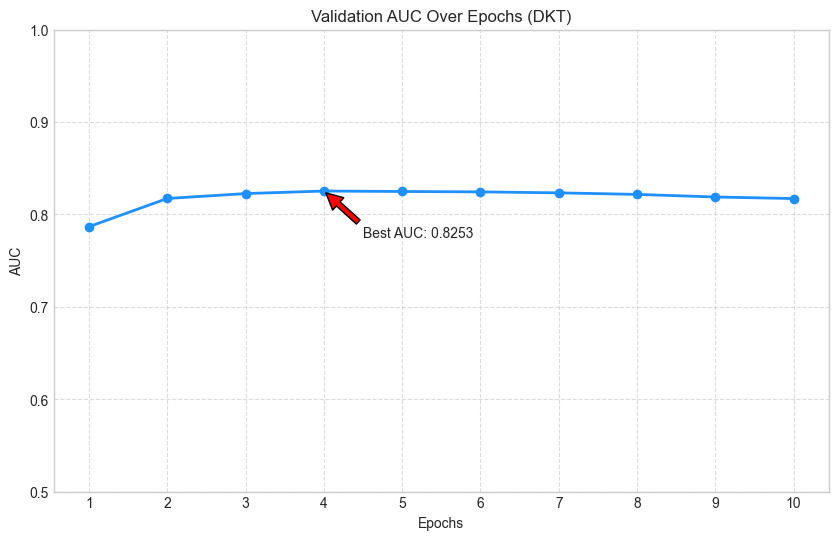


=== Training Summary (DKT) ===
Best Validation AUC: 0.8253 at epoch 4
Final Training Loss: 0.2750
Final Validation AUC: 0.8171


In [ ]:
dkt_auc_summary = []

for epoch, auc in enumerate(val_aucs, start=1):
    dkt_auc_summary.append({'epoch': epoch, 'val_auc': auc})

# Best results recorded
dkt_best_result = {
    'best_epoch': best_epoch,
    'best_auc': best_auc,
    'final_train_loss': train_losses[-1],
    'final_val_auc': val_aucs[-1]
}

# Visualization: AUC curve diagram of DKT
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(val_aucs)+1), val_aucs, 'o-', color='dodgerblue', linewidth=2)
plt.title('Validation AUC Over Epochs (DKT)')
plt.xlabel('Epochs')
plt.ylabel('AUC')
plt.ylim(0.5, 1.0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(range(1, len(val_aucs)+1))

# Mark the best AUC point
plt.annotate(f'Best AUC: {best_auc:.4f}',
             xy=(best_epoch, best_auc),
             xytext=(best_epoch + 0.5, best_auc - 0.05),
             arrowprops=dict(facecolor='red', shrink=0.05))

plt.savefig('dkt_auc_curve.png', dpi=300, bbox_inches='tight')
print("Saved AUC curve plot: dkt_auc_curve.png")
plt.show()

# Output training results summary
print("\n=== Training Summary (DKT) ===")
print(f"Best Validation AUC: {best_auc:.4f} at epoch {best_epoch}")
print(f"Final Training Loss: {train_losses[-1]:.4f}")
print(f"Final Validation AUC: {val_aucs[-1]:.4f}")

This step is to make the DKT validation AUC training track into a readable conclusion: organize each round of AUC into a structured record and find the optimal round, draw the AUC curve changing with epoch, mark the peak and save the picture, and print the summary of the best and final indicators to observe the generalization trend, judge whether it is over fitting, and select the best weight to be retained and the key figures for external reporting.

In [ ]:
adgkt_aucs = [
    0.8697,
    0.8917,
    0.9047,
    0.9225,
    0.9368,
    0.9446,
    0.9513,
    0.9538,
    0.9561,
    0.9611
]
adgkt_epochs = list(range(len(adgkt_aucs)))

The chart below shows the validation AUC over epochs for both DKT and ADGKT models:

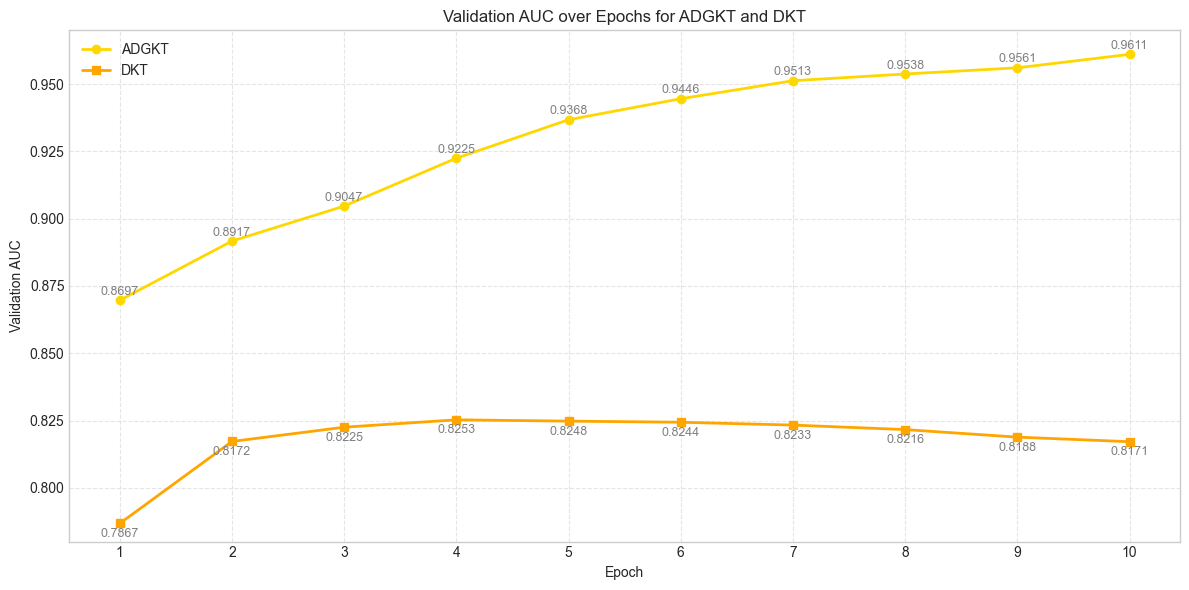

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, 11))
dkt_aucs = [entry['val_auc'] for entry in dkt_auc_summary]
plt.figure(figsize=(12, 6))

# ADGKT curve
plt.plot(epochs, adgkt_aucs, 'o-', color='gold', label='ADGKT', linewidth=2, markersize=6)
for i, auc in enumerate(adgkt_aucs):
    plt.text(epochs[i], auc + 0.002, f"{auc:.4f}", ha='center', fontsize=9, color='gray')

#  DKT curve
plt.plot(epochs, dkt_aucs, 's-', color='orange', label='DKT', linewidth=2, markersize=6)
for i, auc in enumerate(dkt_aucs):
    plt.text(epochs[i], auc - 0.005, f"{auc:.4f}", ha='center', fontsize=9, color='gray')


plt.legend()
plt.title('Validation AUC over Epochs for ADGKT and DKT')
plt.xlabel('Epoch')
plt.ylabel('Validation AUC')
plt.ylim(0.78, 0.97)
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('auc_comparison_single_plot.png', dpi=300, bbox_inches='tight')
plt.show()

The ADGKT model consistently outperformed DKT, indicating that incorporating concept-level information and attention mechanisms may enhance knowledge tracing performance.

Conclusion

The DKT model demonstrates reasonable performance in predicting student responses over time. However, comparison with more advanced models like ADGKT suggests that further improvements can be achieved by incorporating richer semantic structures or attention-based designs.

# 3 Evaluation
For model validation, we primarily focus on three key metrics:

Hit Rate: The accuracy of model predictions on the test set
Success Rate: The proportion of correct answers among all predictions
User Coverage: The percentage of users whose answer history was successfully predicted
Since this is an offline dataset, we cannot obtain real user feedback. Therefore, we need to consider using existing data to simulate real user feedback through design verification methods (this is also the most difficult part of this experiment).
We designed two experimental approaches:

3.1 Traditional Top-K Recommendation Strategy (Abandoned due to poor results)
This initial approach was discontinued because it failed to achieve satisfactory performance metrics

3.2 Predict-Select-Validation Recommendation Strategy
The current validation approach using our specialized prediction selection methodology

！！！！Since the subsequent verification section is based on the output of 2.1 AGDKT for verification, please run 2.1 instead of 2.2 before running 3.1 to end part!！！！！！！

## 3.1 Top-k recommendation strategy (hit rate is acceptable, but hit rate and user coverage are too low)

🔧 Starting fixed evaluation...

Starting detailed evaluation of 1355 new users in test set...


  8%|▊         | 103/1355 [00:07<01:29, 13.98it/s]

Successfully processed 100 users...


 15%|█▍        | 203/1355 [00:14<01:22, 14.03it/s]

Successfully processed 200 users...


...

Successfully processed 1200 users...


 98%|█████████▊| 1326/1355 [01:33<00:02, 14.12it/s]

Successfully processed 1300 users...


100%|██████████| 1355/1355 [01:35<00:00, 14.22it/s]


Evaluation complete! Successfully processed 1330 users
✅ Evaluation complete!

📊 Recommendation System Evaluation Report
📋 Basic statistics:
   • Test users: 1330
   • Average history length: 60.0
   • Average future wrong questions: 10.9
   • Average future correct questions: 40.7

📈 Performance metrics by K value:
--------------------------------------------------------------------------------
K     Hit Rate     Precision    Correct Rate    User Coverage  
--------------------------------------------------------------------------------
10    0.0003       0.0005       0.0067          0.0556         
20    0.0010       0.0007       0.0069          0.1173         
30    0.0018       0.0008       0.0077          0.1902         
40    0.0023       0.0007       0.0082          0.2609         
50    0.0032       0.0008       0.0083          0.3233         

🎯 Global Hit Statistics
Total users: 1355
Covered users: 19 (1.4%)
Total hits: 19
Successful hits: 19 (100.0%)

🎯 Recommendations:
   •

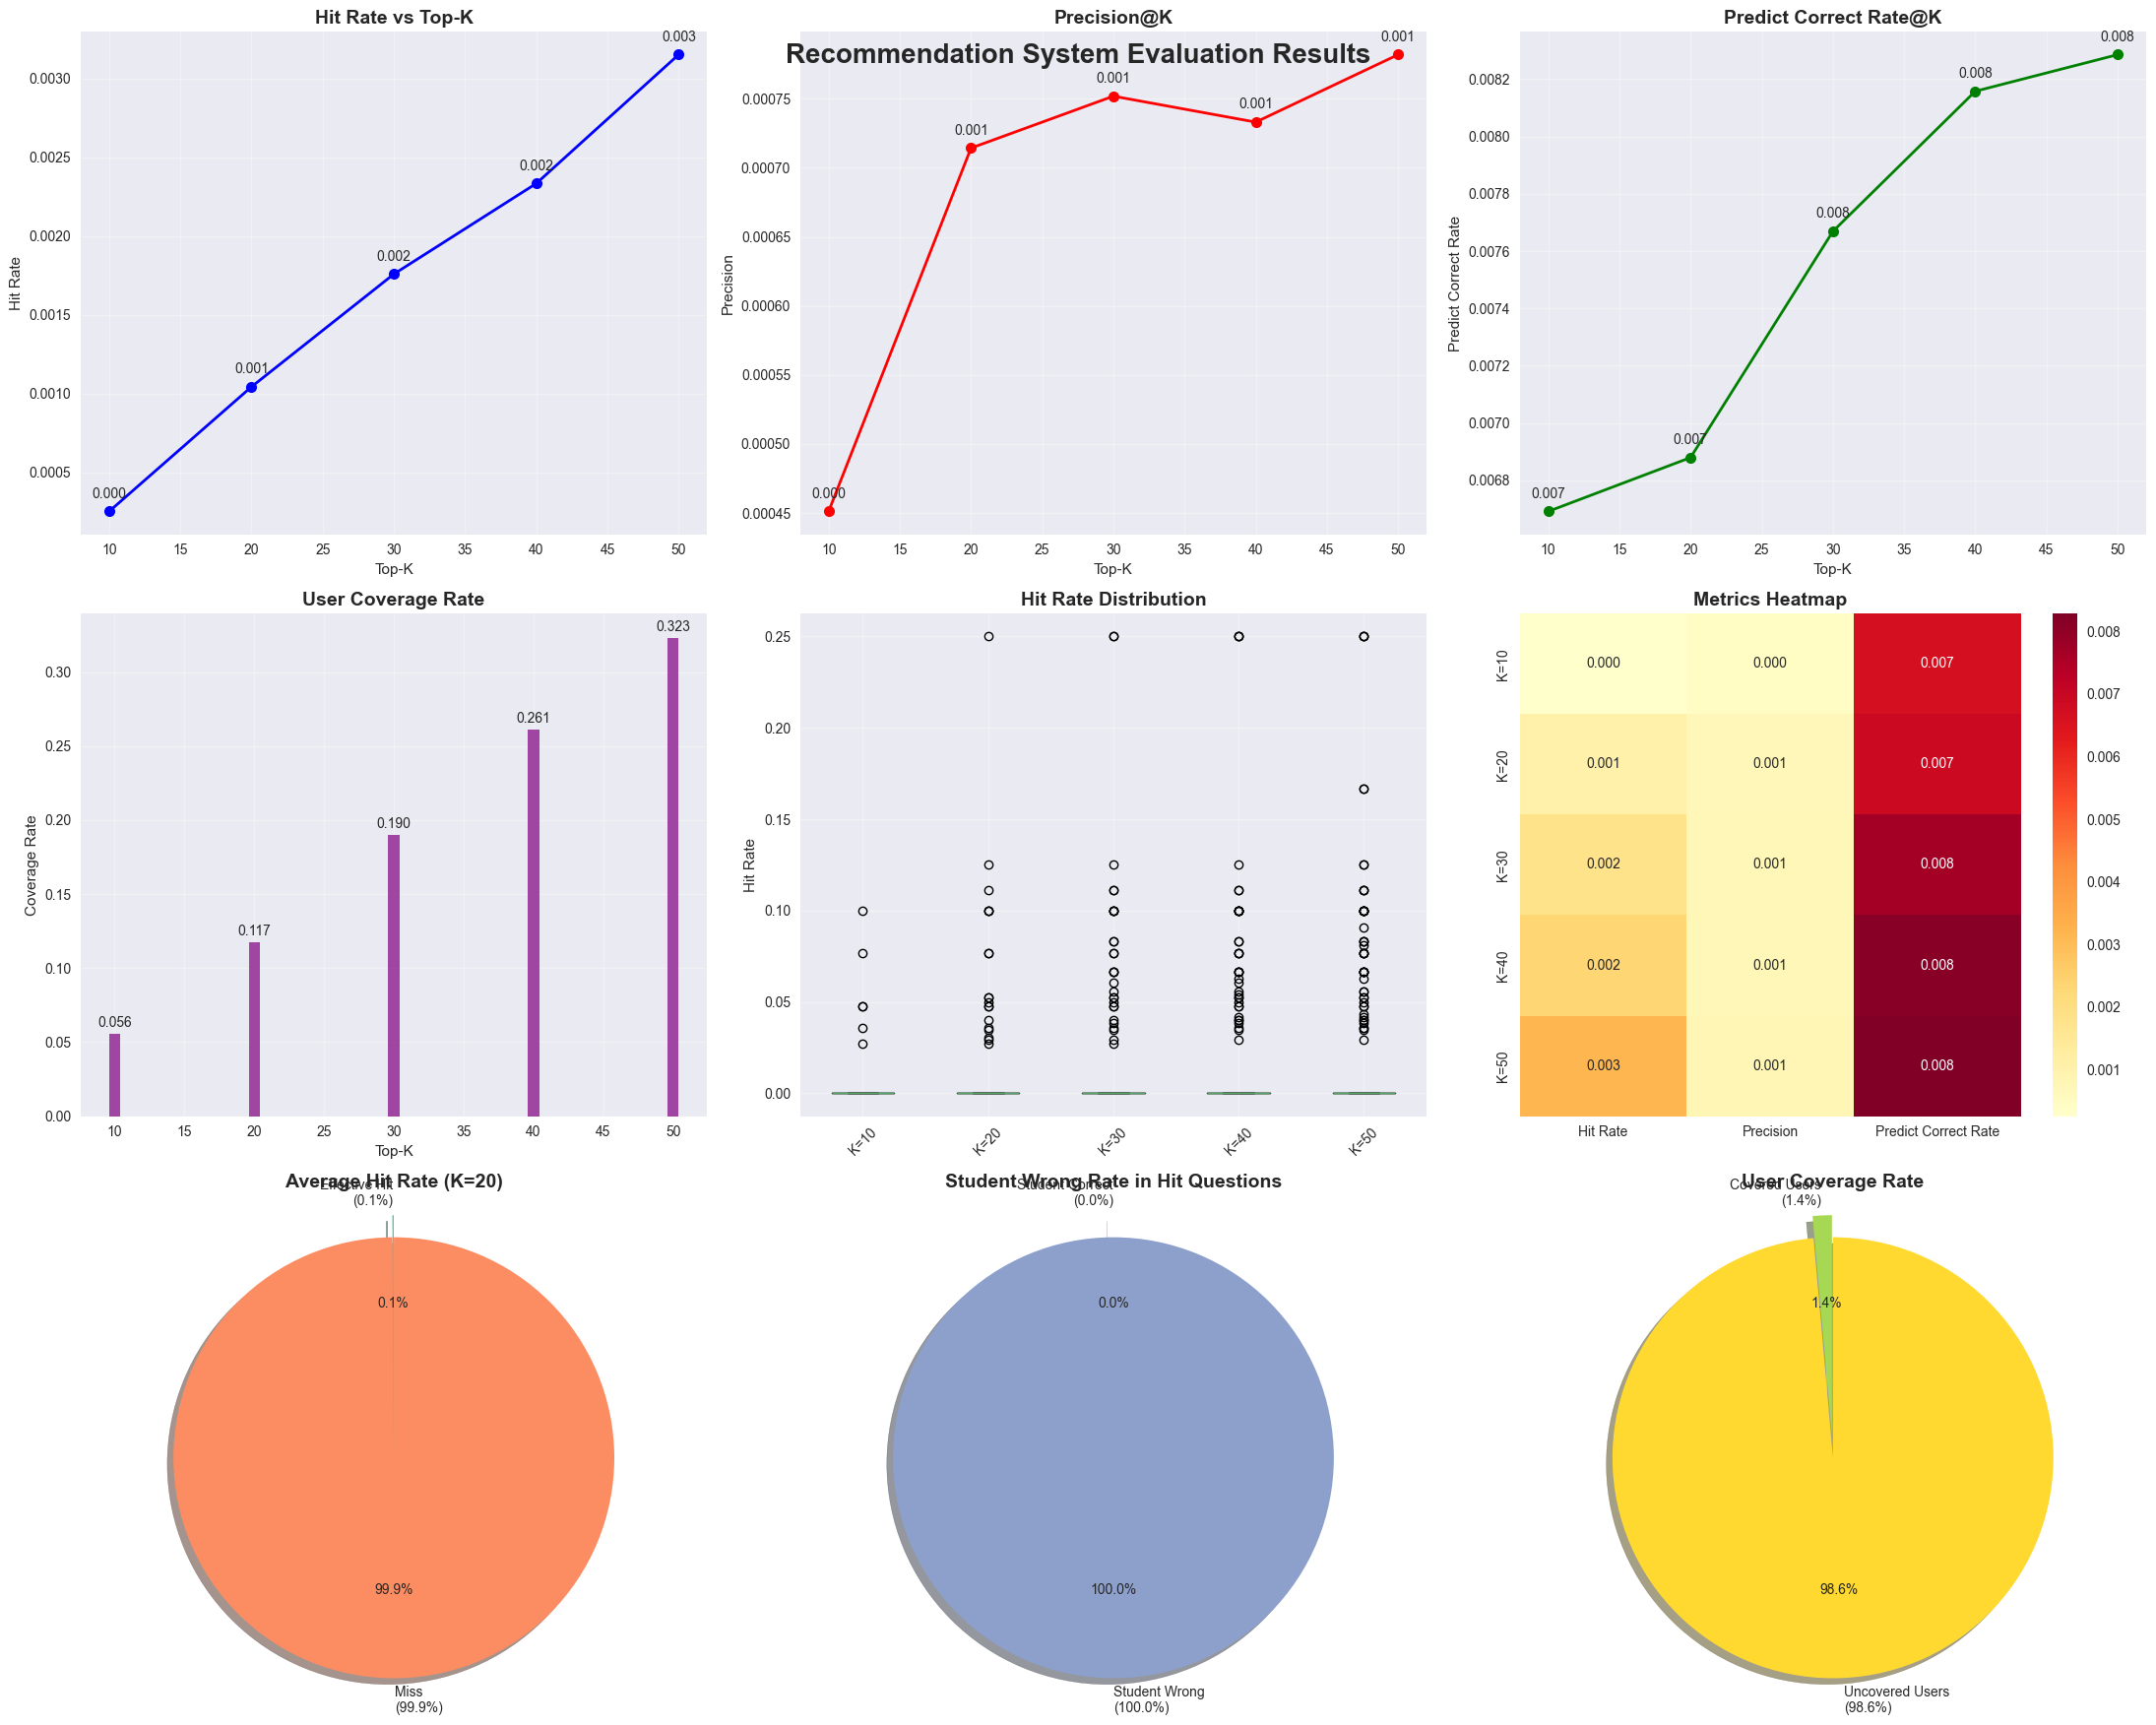


💾 Results saved to: recommendation_evaluation_results_fixed.csv


In [90]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set font support
plt.rcParams['font.family'] = ['DejaVu Sans', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# Create inverse mapping for IDs
if 'qid_map' in locals():
    inverse_qid_map = {v: k for k, v in qid_map.items()}
if 'cid_map' in locals():
    inverse_cid_map = {v: k for k, v in cid_map.items()}

def create_english_to_chinese_concept_map():
    """Create mapping from English concept names to Chinese concept names"""
    return {
        "Geometry": "几何模块",
        "Application Problems": "应用题模块", 
        "Number Theory": "数论模块",
        "Combinatorics": "组合模块",
        "Journey Problems": "行程模块",
        "Counting": "计数模块",
        "Calculation": "计算模块"
    }

# --- Evaluation Configuration ---
class EvalConfig:
    TEST_FILE_PATH = "data/XES3G5M/kc_level/test.csv"
    QUESTIONS_META_PATH = 'data/XES3G5M/metadata/questions.json'
    
    TOP_K_LIST = [10, 20, 30, 40, 50]  # Test different K values
    TEST_HISTORY_RATIO = 0.5  # History data ratio
    MAX_LENGTH = 120  # Max sequence length
    MAX_DAYS = 90  # Max time span (days)
    PREDICTION_BATCH_SIZE = 128  # Prediction batch size

eval_config = EvalConfig()
eval_config.MAX_TIME_DIFF_MS = eval_config.MAX_DAYS * 24 * 60 * 60 * 1000

# --- Fixed evaluation function ---
def evaluate_recommendations_detailed_fixed(model, test_df, config, eval_config, qid_to_module_map):
    """
    Fixed detailed evaluation function with concept mapping issues resolved
    """
    model.eval()
    
    # Initialize statistical variables
    detailed_results = []
    user_results = []
    
    print(f"\nStarting detailed evaluation of {len(test_df)} new users in test set...")
   
    # Create question to concept mapping (directly from raw data)
    q_to_c_map = {}
    for _, row in test_df.iterrows():
        qs = str(row['questions']).split(',')
        cs = str(row['concepts']).split(',')
        for q, c in zip(qs, cs):
            if q not in q_to_c_map:
                q_to_c_map[q] = c

    successful_users = 0
    global_hit_stats = {
        'total_hits': 0,
        'successful_hits': 0,
        'covered_users': 0,
        'total_users': len(test_df)
    }
    
    for index, test_row in tqdm(test_df.iterrows(), total=len(test_df)):
        q_test_seq = str(test_row['questions']).split(',')
        c_test_seq = str(test_row['concepts']).split(',')  
        r_test_seq = [int(r) for r in str(test_row['responses']).split(',')]

        split_point = int(len(q_test_seq) * eval_config.TEST_HISTORY_RATIO)
        if split_point == 0:
            continue

        # Create history data DataFrame
        hist_df = pd.DataFrame({
            'questions': q_test_seq[:split_point],
            'concepts_chn': c_test_seq[:split_point],  # Use Chinese concepts directly
            'responses': r_test_seq[:split_point]
        })

        # Map question IDs
        hist_df['question_id'] = hist_df['questions'].map(qid_map)
        
        # Map Chinese concepts to concept IDs
        hist_df['concept_id'] = hist_df['concepts_chn'].map(cid_map)
        
        # Remove rows with mapping failures
        hist_df.dropna(subset=['question_id', 'concept_id'], inplace=True)
        
        if hist_df.empty:
            continue

        q_hist_list = hist_df['question_id'].astype(int).tolist()
        c_hist_list = hist_df['concept_id'].astype(int).tolist()
        r_hist_list = hist_df['responses'].astype(int).tolist()

        # Prepare model input
        history_len = len(q_hist_list)
        q_hist_tensor = np.zeros(config.MAX_SEQ_LEN - 1, dtype=int)
        c_hist_tensor = np.zeros(config.MAX_SEQ_LEN - 1, dtype=int)
        r_hist_tensor = np.zeros(config.MAX_SEQ_LEN - 1, dtype=int)

        if history_len >= config.MAX_SEQ_LEN - 1:
            q_hist_tensor[:] = q_hist_list[-(config.MAX_SEQ_LEN - 1):]
            c_hist_tensor[:] = c_hist_list[-(config.MAX_SEQ_LEN - 1):]
            r_hist_tensor[:] = r_hist_list[-(config.MAX_SEQ_LEN - 1):]
        else:
            q_hist_tensor[-history_len:] = q_hist_list
            c_hist_tensor[-history_len:] = c_hist_list
            r_hist_tensor[-history_len:] = r_hist_list

        input_q = torch.LongTensor([q_hist_tensor]).to(device)
        input_c = torch.LongTensor([c_hist_tensor]).to(device)
        input_r = torch.LongTensor([r_hist_tensor]).to(device)

        # Prepare ground truth
        ground_truth_df = pd.DataFrame({
            'questions': q_test_seq[split_point:],
            'responses': r_test_seq[split_point:]
        })

        ground_truth_wrong_qids = set(ground_truth_df[ground_truth_df['responses'] == 0]['questions'])
        ground_truth_correct_qids = set(ground_truth_df[ground_truth_df['responses'] == 1]['questions'])
        
        if not ground_truth_wrong_qids:
            continue

        # Get candidate questions
        answered_qids_mapped = set(q_hist_list)
        all_qids_indices = set(qid_map.values())
        candidate_qids_indices = list(all_qids_indices - answered_qids_mapped)

        # Batch prediction
        predictions = []
        with torch.no_grad():
            for i in range(0, len(candidate_qids_indices), eval_config.PREDICTION_BATCH_SIZE):
                batch_q_indices = candidate_qids_indices[i:i + eval_config.PREDICTION_BATCH_SIZE]
                batch_original_qids = [inverse_qid_map.get(q_idx) for q_idx in batch_q_indices]
                
                # Fixed concept mapping - directly from question to concept
                batch_concepts = [q_to_c_map.get(qid) for qid in batch_original_qids]
                batch_c_indices = [cid_map.get(c) for c in batch_concepts]

                valid_indices = [i for i, (qid, c_idx) in enumerate(zip(batch_original_qids, batch_c_indices)) 
                                 if qid is not None and c_idx is not None]
                if not valid_indices: 
                    continue

                batch_q_indices = [batch_q_indices[i] for i in valid_indices]
                batch_original_qids = [batch_original_qids[i] for i in valid_indices]
                batch_c_indices = [batch_c_indices[i] for i in valid_indices]
                batch_size = len(batch_q_indices)

                input_q_batch = input_q.expand(batch_size, -1)
                input_c_batch = input_c.expand(batch_size, -1)
                input_r_batch = input_r.expand(batch_size, -1)

                target_q_batch = torch.LongTensor(batch_q_indices).unsqueeze(1).expand(-1, config.MAX_SEQ_LEN - 1).to(device)
                target_c_batch = torch.LongTensor(batch_c_indices).unsqueeze(1).expand(-1, config.MAX_SEQ_LEN - 1).to(device)

                pred_probs = model(input_q_batch, input_c_batch, input_r_batch, target_q_batch, target_c_batch)
                final_preds = pred_probs[:, -1].cpu().numpy()

                for pred, original_qid in zip(final_preds, batch_original_qids):
                    predictions.append((pred, original_qid))

        # Sort by error probability (descending)
        predictions.sort(key=lambda x: x[0], reverse=True)
        
        if not predictions:
            continue
            
        # Calculate metrics for different K values
        user_result = {
            'user_id': index,
            'history_length': len(q_hist_list),
            'future_wrong': len(ground_truth_wrong_qids),
            'future_correct': len(ground_truth_correct_qids),
            'total_candidates': len(predictions)
        }
        
        user_has_hit = False
        
        for k in eval_config.TOP_K_LIST:
            if len(predictions) >= k:
                recommended_qids = {qid for prob, qid in predictions[:k]}
                
                # Calculate metrics
                hits = len(recommended_qids.intersection(ground_truth_wrong_qids))
                predict_correct = len(recommended_qids.intersection(ground_truth_correct_qids))
                
                hit_rate = hits / len(ground_truth_wrong_qids) if ground_truth_wrong_qids else 0
                precision = hits / k if k > 0 else 0
                predict_correct_rate = predict_correct / k if k > 0 else 0
                
                user_result[f'hits@{k}'] = hits
                user_result[f'hit_rate@{k}'] = hit_rate
                user_result[f'precision@{k}'] = precision
                user_result[f'predict_correct@{k}'] = predict_correct
                user_result[f'predict_correct_rate@{k}'] = predict_correct_rate
                
                # For global stats (using k=20 as reference)
                if k == 20 and hits > 0:
                    user_has_hit = True
                    global_hit_stats['total_hits'] += hits
                    global_hit_stats['successful_hits'] += hits  # All hits are successful by definition
                
                detailed_results.append({
                    'user_id': index,
                    'k': k,
                    'hits': hits,
                    'hit_rate': hit_rate,
                    'precision': precision,
                    'predict_correct': predict_correct,
                    'predict_correct_rate': predict_correct_rate,
                    'future_wrong_count': len(ground_truth_wrong_qids),
                    'history_length': len(q_hist_list)
                })
            else:
                # If fewer than k candidate questions
                user_result[f'hits@{k}'] = 0
                user_result[f'hit_rate@{k}'] = 0
                user_result[f'precision@{k}'] = 0
                user_result[f'predict_correct@{k}'] = 0
                user_result[f'predict_correct_rate@{k}'] = 0
        
        if user_has_hit:
            global_hit_stats['covered_users'] += 1
            
        user_results.append(user_result)
        successful_users += 1
        
        # Report progress every 100 users
        if successful_users % 100 == 0:
            print(f"Successfully processed {successful_users} users...")

    print(f"Evaluation complete! Successfully processed {successful_users} users")
    return detailed_results, user_results, global_hit_stats

# --- Diagnostic function ---
def diagnose_evaluation_issues(model, test_df, config, eval_config, qid_to_module_map):
    """
    Diagnose reasons for user processing failures in evaluation
    """
    print("\n" + "="*80)
    print("🔍 Starting evaluation diagnosis")
    print("="*80)
    
    # Create concept translation dictionary
    eng_to_chn_concept_map = create_english_to_chinese_concept_map()
    
    # Initialize statistical variables
    total_users = len(test_df)
    processed_users = 0
    skipped_users = 0
    skipped_reasons = defaultdict(int)
    
    # Problem mapping statistics
    qid_mapping_issues = defaultdict(int)
    cid_mapping_issues = defaultdict(int)
    
    # Detailed issue tracking
    detailed_issues = []
    
    print(f"Diagnosing evaluation issues for {total_users} users...")
    
    # Create question to concept mapping
    q_to_c_map = {}
    for _, row in test_df.iterrows():
        qs = str(row['questions']).split(',')
        cs = str(row['concepts']).split(',')
        for q, c in zip(qs, cs):
            if q not in q_to_c_map:
                q_to_c_map[q] = c
    
    # Process each user
    for index, test_row in tqdm(test_df.iterrows(), total=total_users):
        q_test_seq = str(test_row['questions']).split(',')
        c_test_seq = str(test_row['concepts']).split(',')  
        r_test_seq = [int(r) for r in str(test_row['responses']).split(',')]

        # Check sequence length
        if len(q_test_seq) == 0:
            skipped_users += 1
            skipped_reasons["Empty sequence"] += 1
            detailed_issues.append({
                'user_id': index,
                'issue': "Empty sequence",
                'details': "Question sequence is empty"
            })
            continue

        # Check sequence split point
        split_point = int(len(q_test_seq) * eval_config.TEST_HISTORY_RATIO)
        if split_point == 0:
            skipped_users += 1
            skipped_reasons["History too short"] += 1
            detailed_issues.append({
                'user_id': index,
                'issue': "History too short",
                'details': f"Sequence length: {len(q_test_seq)}, Split point: {split_point}"
            })
            continue

        # Create history DataFrame
        hist_df = pd.DataFrame({
            'questions': q_test_seq[:split_point],
            'concepts_eng': c_test_seq[:split_point], 
            'responses': r_test_seq[:split_point]
        })

        # Check question ID mapping
        hist_df['question_id'] = hist_df['questions'].map(qid_map)
        qid_mapping_failures = hist_df[hist_df['question_id'].isna()]
        
        if not qid_mapping_failures.empty:
            for qid in qid_mapping_failures['questions'].unique():
                qid_mapping_issues[qid] += 1
        
        # Check concept mapping
        hist_df['concepts_chn'] = hist_df['concepts_eng'].map(eng_to_chn_concept_map)
        concept_mapping_failures = hist_df[hist_df['concepts_chn'].isna()]
        
        if not concept_mapping_failures.empty:
            for concept in concept_mapping_failures['concepts_eng'].unique():
                cid_mapping_issues[concept] += 1
        
        # Check concept ID mapping
        hist_df['concept_id'] = hist_df['concepts_chn'].map(cid_map)
        cid_mapping_failures = hist_df[hist_df['concept_id'].isna()]
        
        if not cid_mapping_failures.empty:
            for concept in cid_mapping_failures['concepts_chn'].unique():
                cid_mapping_issues[concept] += 1
        
        # Remove failed mapping rows
        original_size = len(hist_df)
        hist_df.dropna(subset=['question_id', 'concept_id'], inplace=True)
        new_size = len(hist_df)
        
        if new_size == 0:
            skipped_users += 1
            skipped_reasons["All mappings failed"] += 1
            detailed_issues.append({
                'user_id': index,
                'issue': "All mappings failed",
                'details': f"Original history count: {original_size}, After mapping: {new_size}"
            })
            continue

        # Check actual wrong questions
        ground_truth_df = pd.DataFrame({
            'questions': q_test_seq[split_point:],
            'responses': r_test_seq[split_point:]
        })

        ground_truth_wrong_qids = set(ground_truth_df[ground_truth_df['responses'] == 0]['questions'])
        
        if not ground_truth_wrong_qids:
            skipped_users += 1
            skipped_reasons["No wrong questions in future"] += 1
            detailed_issues.append({
                'user_id': index,
                'issue': "No wrong questions in future",
                'details': f"Future questions: {len(q_test_seq[split_point:])}, Wrong questions: 0"
            })
            continue

        # Check candidate questions
        answered_qids_mapped = set(hist_df['question_id'].astype(str))
        all_qids_indices = set(qid_map.values())
        candidate_qids_indices = list(all_qids_indices - answered_qids_mapped)
        
        if not candidate_qids_indices:
            skipped_users += 1
            skipped_reasons["No candidate questions"] += 1
            detailed_issues.append({
                'user_id': index,
                'issue': "No candidate questions",
                'details': f"Answered questions: {len(answered_qids_mapped)}, Total questions: {len(all_qids_indices)}"
            })
            continue
        
        # Successfully processed users
        processed_users += 1
    
    # Print diagnosis report
    print("\n" + "="*80)
    print("📋 Diagnosis Report")
    print("="*80)
    
    print(f"Total users: {total_users}")
    print(f"Successfully processed users: {processed_users} ({processed_users/total_users:.1%})")
    print(f"Skipped users: {skipped_users} ({skipped_users/total_users:.1%})")
    
    if skipped_users > 0:
        print("\nReasons for skipping users:")
        for reason, count in skipped_reasons.items():
            print(f"- {reason}: {count} users ({count/skipped_users:.1%})")
    
    if qid_mapping_issues:
        print("\nQuestion ID mapping issues (top 10):")
        for qid, count in sorted(qid_mapping_issues.items(), key=lambda x: x[1], reverse=True)[:10]:
            print(f"- Question ID '{qid}': {count} mapping failures")
    
    if cid_mapping_issues:
        print("\nConcept mapping issues (top 10):")
        for concept, count in sorted(cid_mapping_issues.items(), key=lambda x: x[1], reverse=True)[:10]:
            print(f"- Concept '{concept}': {count} mapping failures")
    
    # Save detailed issue report
    if detailed_issues:
        issues_df = pd.DataFrame(detailed_issues)
        issues_df.to_csv('evaluation_diagnosis_report.csv', index=False)
        print(f"\nDetailed issue report saved to: evaluation_diagnosis_report.csv")
    
    return {
        'total_users': total_users,
        'processed_users': processed_users,
        'skipped_users': skipped_users,
        'skipped_reasons': dict(skipped_reasons),
        'qid_mapping_issues': dict(qid_mapping_issues),
        'cid_mapping_issues': dict(cid_mapping_issues)
    }

# --- Visualization functions ---
def create_evaluation_plots(detailed_results, user_results, eval_config, global_hit_stats):
    """
    Create visualizations of evaluation results
    """
    if not detailed_results:
        print("❌ No evaluation data available for visualization")
        return None
        
    detailed_df = pd.DataFrame(detailed_results)
    user_df = pd.DataFrame(user_results) if user_results else pd.DataFrame()
    
    # Set plotting style
    try:
        plt.style.use('seaborn-v0_8')
    except:
        try:
            plt.style.use('seaborn')
        except:
            plt.style.use('default')
    
    # Create main figure with 3x3 grid
    fig = plt.figure(figsize=(22, 18))
    plt.suptitle('Recommendation System Evaluation Results', fontsize=20, fontweight='bold', y=0.95)
    
    # 1. Hit Rate vs Top-K
    plt.subplot(3, 3, 1)
    hit_rates = detailed_df.groupby('k')['hit_rate'].mean()
    plt.plot(hit_rates.index, hit_rates.values, 'bo-', linewidth=2, markersize=8)
    plt.title('Hit Rate vs Top-K', fontsize=14, fontweight='bold')
    plt.xlabel('Top-K')
    plt.ylabel('Hit Rate')
    plt.grid(True, alpha=0.3)
    for i, v in enumerate(hit_rates.values):
        plt.annotate(f'{v:.3f}', (hit_rates.index[i], v), 
                    textcoords="offset points", xytext=(0,10), ha='center')
    
    # 2. Precision@K
    plt.subplot(3, 3, 2)
    precisions = detailed_df.groupby('k')['precision'].mean()
    plt.plot(precisions.index, precisions.values, 'ro-', linewidth=2, markersize=8)
    plt.title('Precision@K', fontsize=14, fontweight='bold')
    plt.xlabel('Top-K')
    plt.ylabel('Precision')
    plt.grid(True, alpha=0.3)
    for i, v in enumerate(precisions.values):
        plt.annotate(f'{v:.3f}', (precisions.index[i], v), 
                    textcoords="offset points", xytext=(0,10), ha='center')
    
    # 3. Predict Correct Rate
    plt.subplot(3, 3, 3)
    correct_rates = detailed_df.groupby('k')['predict_correct_rate'].mean()
    plt.plot(correct_rates.index, correct_rates.values, 'go-', linewidth=2, markersize=8)
    plt.title('Predict Correct Rate@K', fontsize=14, fontweight='bold')
    plt.xlabel('Top-K')
    plt.ylabel('Predict Correct Rate')
    plt.grid(True, alpha=0.3)
    for i, v in enumerate(correct_rates.values):
        plt.annotate(f'{v:.3f}', (correct_rates.index[i], v), 
                    textcoords="offset points", xytext=(0,10), ha='center')
    
    # 4. User Coverage Statistics
    plt.subplot(3, 3, 4)
    coverage_data = []
    for k in eval_config.TOP_K_LIST:
        if user_results:
            users_with_recommendations = len([u for u in user_results if u.get(f'hits@{k}', 0) > 0 or u.get(f'predict_correct@{k}', 0) > 0])
            coverage_rate = users_with_recommendations / len(user_results)
        else:
            coverage_rate = 0
        coverage_data.append(coverage_rate)
    
    plt.bar(eval_config.TOP_K_LIST, coverage_data, color='purple', alpha=0.7)
    plt.title('User Coverage Rate', fontsize=14, fontweight='bold')
    plt.xlabel('Top-K')
    plt.ylabel('Coverage Rate')
    plt.grid(True, alpha=0.3)
    for i, v in enumerate(coverage_data):
        plt.annotate(f'{v:.3f}', (eval_config.TOP_K_LIST[i], v), 
                    textcoords="offset points", xytext=(0,5), ha='center')
    
    # 5. Hit Rate Distribution
    plt.subplot(3, 3, 5)
    hit_rate_data = []
    labels = []
    for k in eval_config.TOP_K_LIST:
        k_data = detailed_df[detailed_df['k'] == k]['hit_rate'].values
        hit_rate_data.append(k_data)
        labels.append(f'K={k}')
    
    plt.boxplot(hit_rate_data, labels=labels)
    plt.title('Hit Rate Distribution', fontsize=14, fontweight='bold')
    plt.ylabel('Hit Rate')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    
    # 6. Metrics Heatmap
    plt.subplot(3, 3, 6)
    metrics_summary = []
    for k in eval_config.TOP_K_LIST:
        k_data = detailed_df[detailed_df['k'] == k]
        metrics_summary.append([
            k_data['hit_rate'].mean(),
            k_data['precision'].mean(),
            k_data['predict_correct_rate'].mean()
        ])
    
    metrics_df = pd.DataFrame(metrics_summary, 
                             columns=['Hit Rate', 'Precision', 'Predict Correct Rate'],
                             index=[f'K={k}' for k in eval_config.TOP_K_LIST])
    
    sns.heatmap(metrics_df, annot=True, cmap='YlOrRd', fmt='.3f', cbar=True)
    plt.title('Metrics Heatmap', fontsize=14, fontweight='bold')
    
    # 7. Hit Rate Pie Chart
    plt.subplot(3, 3, 7)
    avg_hit_rate = detailed_df[detailed_df['k'] == 20]['hit_rate'].mean()
    labels = [f'Effective Hit\n({avg_hit_rate:.1%})', f'Miss\n({1-avg_hit_rate:.1%})']
    sizes = [avg_hit_rate, 1 - avg_hit_rate]
    colors = ['#66c2a5', '#fc8d62']
    explode = (0.1, 0)
    
    plt.pie(sizes, explode=explode, labels=labels, colors=colors, 
            autopct='%1.1f%%', shadow=True, startangle=90)
    plt.axis('equal')
    plt.title('Average Hit Rate (K=20)', fontsize=14, fontweight='bold')
    
       # 8. Student Wrong Rate in Hit Questions
    plt.subplot(3, 3, 8)
    if global_hit_stats['total_hits'] > 0:
        # 计算学生答错的比例 = 成功命中数 / 总命中数
        wrong_rate = global_hit_stats['successful_hits'] / global_hit_stats['total_hits']
        labels = [f'Student Wrong\n({wrong_rate:.1%})', f'Student Correct\n({1-wrong_rate:.1%})']
        sizes = [wrong_rate, 1 - wrong_rate]
    else:
        labels = ['No hits recorded']
        sizes = [1]
        
    colors = ['#8da0cb', '#e78ac3']
    explode = (0.1, 0)
    
    plt.pie(sizes, explode=explode, labels=labels, colors=colors, 
            autopct='%1.1f%%', shadow=True, startangle=90)
    plt.axis('equal')
    plt.title('Student Wrong Rate in Hit Questions', fontsize=14, fontweight='bold')

    # 9. User Coverage Rate Pie Chart
    plt.subplot(3, 3, 9)
    if global_hit_stats['total_users'] > 0:
        coverage_rate = global_hit_stats['covered_users'] / global_hit_stats['total_users']
        labels = [f'Covered Users\n({coverage_rate:.1%})', f'Uncovered Users\n({1-coverage_rate:.1%})']
        sizes = [coverage_rate, 1 - coverage_rate]
    else:
        labels = ['No users processed']
        sizes = [1]
        
    colors = ['#a6d854', '#ffd92f']
    explode = (0.1, 0)
    
    plt.pie(sizes, explode=explode, labels=labels, colors=colors, 
            autopct='%1.1f%%', shadow=True, startangle=90)
    plt.axis('equal')
    plt.title('User Coverage Rate', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('evaluation_results_with_pie_charts.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return metrics_df

# --- Statistics report function ---
def generate_evaluation_report(detailed_results, user_results, eval_config, global_hit_stats):
    """
    Generate detailed evaluation report
    """
    print("\n" + "="*80)
    print("📊 Recommendation System Evaluation Report")
    print("="*80)
    
    if not detailed_results:
        print("❌ No evaluation data available")
        return None
        
    if not user_results:
        print("❌ No user results data available")
        return None
    
    detailed_df = pd.DataFrame(detailed_results)
    user_df = pd.DataFrame(user_results)
    
    print(f"📋 Basic statistics:")
    print(f"   • Test users: {len(user_results)}")
    
    if 'history_length' in user_df.columns:
        print(f"   • Average history length: {user_df['history_length'].mean():.1f}")
    
    if 'future_wrong' in user_df.columns:
        print(f"   • Average future wrong questions: {user_df['future_wrong'].mean():.1f}")
    
    if 'future_correct' in user_df.columns:
        print(f"   • Average future correct questions: {user_df['future_correct'].mean():.1f}")
    
    print(f"\n📈 Performance metrics by K value:")
    print("-" * 80)
    print(f"{'K':<5} {'Hit Rate':<12} {'Precision':<12} {'Correct Rate':<15} {'User Coverage':<15}")
    print("-" * 80)
    
    for k in eval_config.TOP_K_LIST:
        k_data = detailed_df[detailed_df['k'] == k]
        if not k_data.empty:
            hit_rate = k_data['hit_rate'].mean()
            precision = k_data['precision'].mean()
            correct_rate = k_data['predict_correct_rate'].mean()
            
            users_with_rec = len([u for u in user_results if u.get(f'hits@{k}', 0) > 0 or u.get(f'predict_correct@{k}', 0) > 0])
            coverage = users_with_rec / len(user_results) if user_results else 0
            
            print(f"{k:<5} {hit_rate:<12.4f} {precision:<12.4f} {correct_rate:<15.4f} {coverage:<15.4f}")
    
    # Global hit statistics
    print("\n" + "="*80)
    print("🎯 Global Hit Statistics")
    print("="*80)
    print(f"Total users: {global_hit_stats['total_users']}")
    print(f"Covered users: {global_hit_stats['covered_users']} ({global_hit_stats['covered_users']/global_hit_stats['total_users']:.1%})")
    print(f"Total hits: {global_hit_stats['total_hits']}")
    if global_hit_stats['total_hits'] > 0:
        success_rate = global_hit_stats['successful_hits'] / global_hit_stats['total_hits']
        print(f"Successful hits: {global_hit_stats['successful_hits']} ({success_rate:.1%})")
    
    print("\n" + "="*80)
    
    try:
        if not detailed_df.empty:
            hit_rate_by_k = detailed_df.groupby('k')['hit_rate'].mean()
            precision_by_k = detailed_df.groupby('k')['precision'].mean()
            
            if not hit_rate_by_k.empty and not precision_by_k.empty:
                best_k_hit = hit_rate_by_k.idxmax()
                best_k_precision = precision_by_k.idxmax()
                
                print(f"🎯 Recommendations:")
                print(f"   • Best Hit Rate: K={best_k_hit} ({hit_rate_by_k[best_k_hit]:.4f})")
                print(f"   • Best Precision: K={best_k_precision} ({precision_by_k[best_k_precision]:.4f})")
                print(f"   • Comprehensive recommendation: K=30-40 (balance accuracy and coverage)")
    except Exception as e:
        print(f"⚠️  Error calculating optimal K value: {e}")
    
    try:
        return detailed_df.groupby('k').agg({
            'hit_rate': 'mean',
            'precision': 'mean', 
            'predict_correct_rate': 'mean'
        })
    except:
        return pd.DataFrame()

# --- Main execution flow ---
if __name__ == "__main__":
    q_to_c_map = {}
    for _, row in cleaned_test_df.iterrows():
        qs = str(row['questions']).split(',')
        cs = str(row['concepts']).split(',')
        for q, c in zip(qs, cs):
            if q not in q_to_c_map:
                q_to_c_map[q] = c

    # Execute fixed evaluation
    print("🔧 Starting fixed evaluation...")
    detailed_results, user_results, global_hit_stats = evaluate_recommendations_detailed_fixed(
        model, cleaned_test_df, config, eval_config, qid_to_module_map
    )

    if detailed_results and user_results:
        print("✅ Evaluation complete!")
        
        # Generate report
        summary_stats = generate_evaluation_report(detailed_results, user_results, eval_config, global_hit_stats)
        
        # Create visualizations
        print("\n📊 Generating visualizations...")
        metrics_heatmap = create_evaluation_plots(detailed_results, user_results, eval_config, global_hit_stats)
        
        # Save results
        results_df = pd.DataFrame(detailed_results)
        results_df.to_csv('recommendation_evaluation_results_fixed.csv', index=False)
        print(f"\n💾 Results saved to: recommendation_evaluation_results_fixed.csv")
    else:
        print("❌ Still no results after fix, running diagnosis...")
        
        # Execute diagnosis
        print("\nStarting diagnosis...")
        diagnosis_results = diagnose_evaluation_issues(
            model, cleaned_test_df, config, eval_config, qid_to_module_map
        )


This step is to do adgkt's offline Top-k recommendation evaluation and physical examination: divide the test set according to "history → future", score in batches for all unfinished questions, sort by probability, and count hits, hit_rate, precision, user coverage and other core indicators on K ∈ {10,20,30,40,50}; If there is no result in the evaluation, automatically diagnose the skip reason and output the mapping problem report; At the same time, a page of 3 × 3 visual dashboard and summary table will be generated, which will be landing as CSV pictures and other files. In short, it is to quantify end-to-end "whether the model can rank the most likely wrong questions in the front", and provide traceable reports and fault diagnosis.


## 3.2 Prediction-Select-Verification Framework for Educational AI

## 🧠 Core Method Concept
This method proposes a **multi-dimensional decision-oriented verification paradigm** that breaks through the limitation of traditional knowledge tracing models that only evaluate prediction accuracy. By introducing a **modulable threshold decision mechanism** and **five-state outcome analysis system**, it elevates AI verification from pure technical assessment to **educational decision value evaluation**.

## ⚙️ Technical Implementation Principles

## Dynamic Threshold Decision Engine
```python
if predicted_prob > threshold:  # Decision: Skip
    if actual_response == 1:
        state = "STATE1"  # Reasonable skip (correct in follow-up)
    else:
        state = "STATE2"  # Mistaken skip (incorrect in follow-up)
else:  # Decision: Intervene
    if actual_response == 0:
        state = "STATE3"  # Correct prediction of error
    elif predicted_error_type == actual_error_type:
        state = "STATE5"  # Partial value capture (error type matched)
    else:
        state = "STATE4"  # Mistaken prediction (actually correct)


Starting Validation Analysis

Cleaning test data... (Original size: 3613 rows)


100%|██████████| 3613/3613 [00:01<00:00, 2615.55it/s]


Cleaning complete. Remaining rows: 1355

Starting sequential validation for 1355 users...


100%|██████████| 1355/1355 [02:59<00:00,  7.55it/s]



distribution of hit counts
   命中次数  用户数量     用户占比
 0 time   140 0.103321
 1 time   127 0.093727
 2 time   147 0.108487
 3 time   115 0.084871
 4 time   112 0.082657
 5 time   103 0.076015
 6 time    57 0.042066
 7 time    65 0.047970
 8 time    65 0.047970
 9 time    46 0.033948
10 time    36 0.026568
11 time    36 0.026568
12 time    34 0.025092
13 time    28 0.020664
14 time    23 0.016974
15 time    23 0.016974
16 time    20 0.014760
17 time    19 0.014022
18 time    16 0.011808
19 time    16 0.011808
20 time    13 0.009594
21 time    16 0.011808
22 time     9 0.006642
23 time     8 0.005904
24 time     8 0.005904
25 time    10 0.007380
26 time     3 0.002214
27 time     5 0.003690
28 time     5 0.003690
29 time     2 0.001476
30 time     7 0.005166
31 time     3 0.002214
32 time     4 0.002952
33 time     3 0.002214
34 time     1 0.000738
36 time     2 0.001476
37 time     3 0.002214
38 time     1 0.000738
39 time     2 0.001476
40 time     2 0.001476
41 time     3 0.002214
42 tim

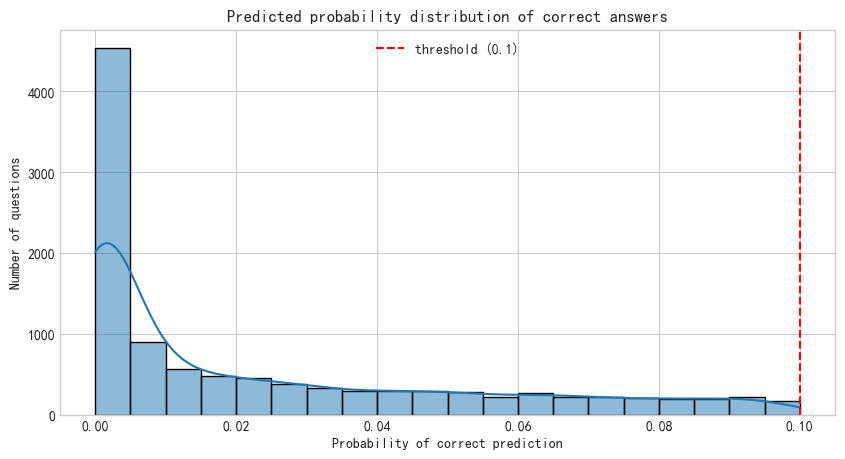

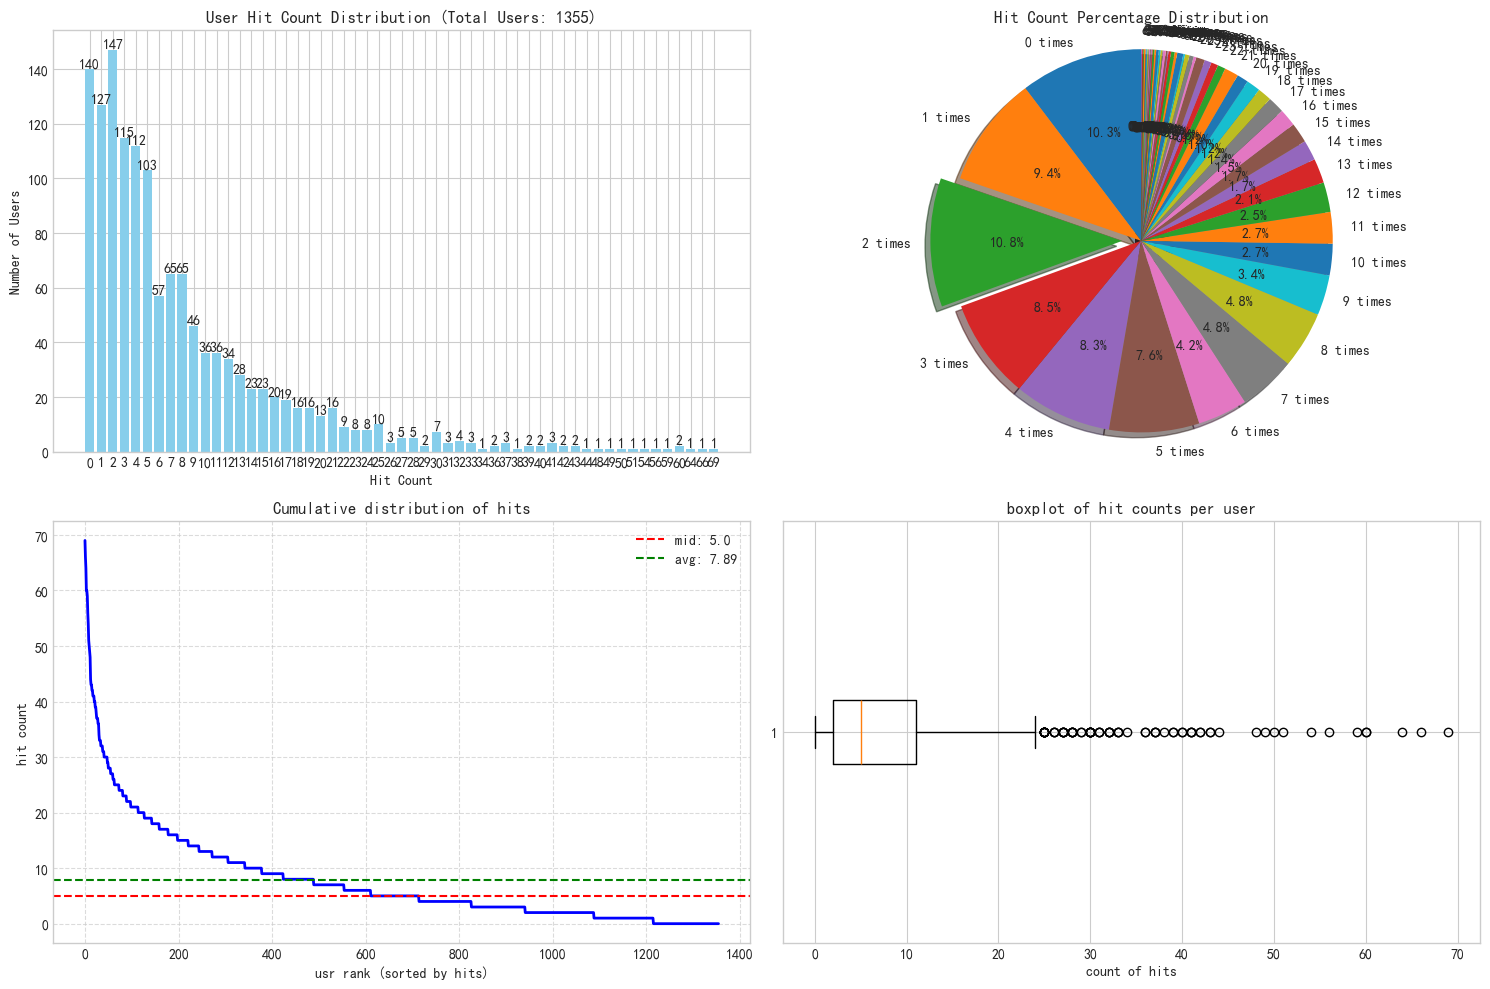


Overall error rate analysis
Total number of questions answered correctly: 10687
The number of questions actually answered incorrectly in the test: 8262
The number of questions actually answered correctly in the test: 2425
Error rate in hitting the target: 77.31%


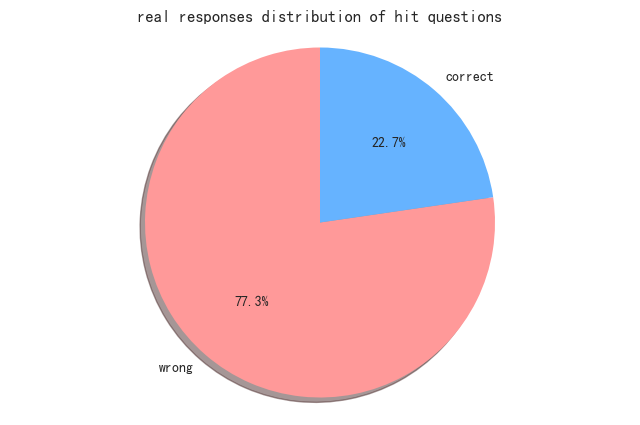


Detailed results have been saved to a file.: validation_results_20250808_191959.json


In [26]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import json
import warnings
import torch.nn as nn
import os
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict


warnings.filterwarnings('ignore')

# Set Chinese font support
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
# --- Configuration Classes ---
class AnalysisConfig:
    TEST_FILE_PATH = "data/XES3G5M/kc_level/test.csv"
    QUESTIONS_META_PATH = 'data/XES3G5M/metadata/questions.json'
    MAX_LENGTH = 120
    MAX_DAYS = 90
    PREDICTION_THRESHOLD = 0.1
    MODEL_PATH = "saved_models/adgkt_model_epoch10.pth"
    QID_MAP_PATH = "saved_models/qid_map.json"
    CID_MAP_PATH = "saved_models/cid_map.json"
    TRAINING_CONFIG_PATH = "saved_models/training_config.json"

analysis_config = AnalysisConfig()
analysis_config.MAX_TIME_DIFF_MS = analysis_config.MAX_DAYS * 24 * 60 * 60 * 1000

# --- Model Definition (ADGKT) ---
class ADGKT(nn.Module):
    def __init__(self, num_q, num_c, embed_size, hidden_size, num_heads, dropout):
        super(ADGKT, self).__init__()
        self.num_q = num_q
        self.num_c = num_c
        self.q_embed = nn.Embedding(num_q, embed_size)
        self.c_embed = nn.Embedding(num_c, embed_size)
        self.r_embed = nn.Embedding(2, embed_size)
        self.interaction_fusion = nn.Linear(embed_size * 2, hidden_size)
        self.attention = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.predict_fusion = nn.Linear(hidden_size * 2, hidden_size)
        self.out = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm1 = nn.LayerNorm(hidden_size)
        self.layer_norm2 = nn.LayerNorm(hidden_size)

    def forward(self, input_q, input_c, input_r, target_q, target_c):
        q_emb = self.q_embed(input_q)
        c_emb = self.c_embed(input_c)
        r_emb = self.r_embed(input_r)
        interaction_emb = self.interaction_fusion(torch.cat([q_emb, c_emb], dim=-1)) + r_emb
        attn_input = self.layer_norm1(interaction_emb)
        attn_output, _ = self.attention(attn_input, attn_input, attn_input)
        attn_output = self.dropout(attn_output) + interaction_emb
        gru_input = self.layer_norm2(attn_output)
        gru_output, _ = self.gru(gru_input)
        target_q_emb = self.q_embed(target_q)
        target_c_emb = self.c_embed(target_c)
        predict_input = torch.cat([gru_output, target_q_emb + target_c_emb], dim=-1)
        predict_hidden = torch.relu(self.predict_fusion(predict_input))
        output = self.out(predict_hidden)
        return torch.sigmoid(output).squeeze(-1)

# --- Validation Analysis Function ---
def run_sequential_validation(model, test_df, config, analysis_config, qid_to_module_map, device, qid_map, cid_map):
    model.eval()
    results = {
        'total_users': len(test_df),
        'users_with_hits': 0,
        'total_hits': 0,
        'correctly_predicted_wrong_answers': 0,
        'hit_details': [],
        'user_hit_counts': defaultdict(int),  # hit count per user
        'hit_count_distribution': defaultdict(int),  # distribution of hit counts
        'hit_per_user': []  # list of hit counts per user
    }
    print(f"\nStarting sequential validation for {len(test_df)} users...")
    
    for index, row in tqdm(test_df.iterrows(), total=len(test_df)):
        q_seq = str(row['questions']).split(',')
        c_seq = str(row['concepts']).split(',')
        r_seq = [int(r) for r in str(row['responses']).split(',')]
        
        user_hits = 0  # Number of hits for the current user
        correctly_predicted_wrong = 0
        
        # We need at least one interaction for history and one for prediction
        if len(q_seq) < 2:
            continue
        
        # Iterate through the sequence, taking one more interaction as history each time
        for i in range(1, len(q_seq)):
            hist_q = q_seq[:i]
            hist_c = c_seq[:i]
            hist_r = r_seq[:i]
            
            target_q = q_seq[i]
            target_c = c_seq[i]
            actual_response = r_seq[i]
            
            # Map IDs, skipping if unknown
            q_hist_ids = [qid_map.get(q) for q in hist_q]
            c_hist_ids = [cid_map.get(c) for c in hist_c]
            target_q_id = qid_map.get(target_q)
            target_c_id = cid_map.get(target_c)

            if None in q_hist_ids or None in c_hist_ids or target_q_id is None or target_c_id is None:
                continue

            # Prepare tensors
            history_len = len(q_hist_ids)
            input_q = np.zeros(config.MAX_SEQ_LEN - 1, dtype=int)
            input_c = np.zeros(config.MAX_SEQ_LEN - 1, dtype=int)
            input_r = np.zeros(config.MAX_SEQ_LEN - 1, dtype=int)

            if history_len >= config.MAX_SEQ_LEN - 1:
                input_q[:] = q_hist_ids[-(config.MAX_SEQ_LEN - 1):]
                input_c[:] = c_hist_ids[-(config.MAX_SEQ_LEN - 1):]
                input_r[:] = hist_r[-(config.MAX_SEQ_LEN - 1):]
            else:
                input_q[-history_len:] = q_hist_ids
                input_c[-history_len:] = c_hist_ids
                input_r[-history_len:] = hist_r
            
            input_q = torch.LongTensor([input_q]).to(device)
            input_c = torch.LongTensor([input_c]).to(device)
            input_r = torch.LongTensor([input_r]).to(device)
            target_q = torch.LongTensor([target_q_id] * (config.MAX_SEQ_LEN - 1)).to(device).unsqueeze(0)
            target_c = torch.LongTensor([target_c_id] * (config.MAX_SEQ_LEN - 1)).to(device).unsqueeze(0)

            # Get prediction
            with torch.no_grad():
                pred_prob = model(input_q, input_c, input_r, target_q, target_c)
                final_pred = pred_prob[0, -1].item()
            
            # Apply your logic
            if final_pred <= analysis_config.PREDICTION_THRESHOLD:
                user_hits += 1  # Increase the hit count for the current user
                if actual_response == 0:
                    correctly_predicted_wrong += 1
                
                # Store details for deeper analysis
                results['hit_details'].append({
                    'user_index': index,
                    'hit_at_step': i,
                    'predicted_prob': final_pred,
                    'actual_response': actual_response
                })
                
                
                # break 

        # Update statistics
        if user_hits > 0:
            results['users_with_hits'] += 1
        results['total_hits'] += user_hits
        results['correctly_predicted_wrong_answers'] += correctly_predicted_wrong
        
        # Record the number of hits for the current user
        results['user_hit_counts'][index] = user_hits
        results['hit_count_distribution'][user_hits] += 1
        results['hit_per_user'].append(user_hits)
    
    return results

# --- Helper functions ---
def load_id_maps():
    with open(analysis_config.QID_MAP_PATH, "r") as f:
        qid_map = json.load(f)
    with open(analysis_config.CID_MAP_PATH, "r") as f:
        cid_map = json.load(f)
    return qid_map, cid_map

def load_training_config():
    with open(analysis_config.TRAINING_CONFIG_PATH, "r") as f:
        config_data = json.load(f)
    class TrainingConfig: pass
    config = TrainingConfig()
    for key, value in config_data.items():
        setattr(config, key, value)
    return config
    
def clean_test_data(test_df_raw, qid_to_module_map, known_qids):
    print(f"\nCleaning test data... (Original size: {len(test_df_raw)} rows)")
    processed_rows = []
    for index, row in tqdm(test_df_raw.iterrows(), total=len(test_df_raw)):
        new_row = row.copy()
        questions_list = str(row['questions']).split(',')
        keep_mask = [qid in known_qids for qid in questions_list]

        if not any(keep_mask): continue

        for col in ['questions', 'responses', 'timestamps']:
            original_list = str(row[col]).split(',')
            if len(original_list) == len(questions_list):
                filtered_list = [item for item, keep in zip(original_list, keep_mask) if keep]
                new_row[col] = ','.join(filtered_list)
        
        filtered_qids = new_row['questions'].split(',')
        new_concepts = [qid_to_module_map.get(qid, 'Unknown') for qid in filtered_qids]
        new_row['concepts'] = ','.join(new_concepts)
        
        if len(filtered_qids) > analysis_config.MAX_LENGTH:
            for col in ['questions', 'concepts', 'responses', 'timestamps']:
                new_row[col] = ','.join(new_row[col].split(',')[:analysis_config.MAX_LENGTH])

        # Check timestamp difference
        if 'timestamps' in new_row and pd.notna(new_row['timestamps']):
            timestamps_list = [int(ts) for ts in str(new_row['timestamps']).split(',') if ts]
            if len(timestamps_list) > 1:
                if (timestamps_list[-1] - timestamps_list[0]) > analysis_config.MAX_TIME_DIFF_MS:
                    continue
        
        processed_rows.append(new_row)
    
    cleaned_df = pd.DataFrame(processed_rows)
    print(f"Cleaning complete. Remaining rows: {len(cleaned_df)}")
    return cleaned_df

# visualization analysis
def visualize_hit_distribution(results):
    """
   visualize_hit_distribution:
    """
    plt.figure(figsize=(15, 10))
    
    # 1. hit counts bar plot
    plt.subplot(2, 2, 1)
    hit_counts = sorted(results['hit_count_distribution'].items())
    hit_x = [str(x[0]) for x in hit_counts]
    hit_y = [x[1] for x in hit_counts]
    
    bar_plot = plt.bar(hit_x, hit_y, color='skyblue')
    plt.title(f"User Hit Count Distribution (Total Users: {results['total_users']})")
    plt.xlabel("Hit Count")
    plt.ylabel("Number of Users")
    
    #add value labels on top of bars
    for bar in bar_plot:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height}', ha='center', va='bottom')
    
    # 2. bar plot of hit count percentage distribution
    plt.subplot(2, 2, 2)
    labels = [f"{count} times" for count in hit_x]
    sizes = hit_y
    explode = [0.1 if max(hit_y) == count else 0 for count in hit_y]
    
    plt.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
            shadow=True, startangle=90)
    plt.axis('equal')
    plt.title("Hit Count Percentage Distribution")
    
    # 3. disdribution of hit counts per user
    plt.subplot(2, 2, 3)
    hit_per_user = np.array(results['hit_per_user'])
    sorted_hits = np.sort(hit_per_user)[::-1]  # sort in descending order
    plt.plot(sorted_hits, 'b-', linewidth=2)
    plt.title("Cumulative distribution of hits")
    plt.xlabel("usr rank (sorted by hits)")
    plt.ylabel("hit count")
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Add reference line: median
    median_hits = np.median(sorted_hits)
    plt.axhline(y=median_hits, color='r', linestyle='--', label=f'mid: {median_hits}')
    
    # Add reference line: Average value
    avg_hits = np.mean(sorted_hits)
    plt.axhline(y=avg_hits, color='g', linestyle='--', label=f'avg: {avg_hits:.2f}')
    
    plt.legend()
    
    # 4. Box plot showing the distribution of hits
    plt.subplot(2, 2, 4)
    plt.boxplot(hit_per_user, vert=False)
    plt.title("boxplot of hit counts per user")
    plt.xlabel("count of hits")
    
    plt.tight_layout()
    plt.savefig('hit_distribution_analysis.png', dpi=300)
    plt.show()
    
    # Return hit distribution statistics
    return {
        "max_hits": max(hit_per_user) if hit_per_user.size > 0 else 0,
        "min_hits": min(hit_per_user) if hit_per_user.size > 0 else 0,
        "avg_hits": avg_hits,
        "median_hits": median_hits,
        "std_hits": np.std(hit_per_user) if hit_per_user.size > 0 else 0
    }


# --- Main Execution ---
if __name__ == "__main__":
    print("=" * 60)
    print("Starting Validation Analysis")
    print("=" * 60)
    
    try:
        # Load necessary files
        qid_map, cid_map = load_id_maps()
        config = load_training_config()
        test_df_raw = pd.read_csv(analysis_config.TEST_FILE_PATH)
        
        module_translation = {
           "Geometry": "几何模块",
        "Application Problems": "应用题模块", 
        "Number Theory": "数论模块",
        "Combinatorics": "组合模块",
        "Journey Problems": "行程模块",
        "Counting": "计数模块",
        "Calculation": "计算模块",
        }
        with open(analysis_config.QUESTIONS_META_PATH, 'r', encoding='utf-8') as f:
            questions_data = json.load(f)
        
        qid_to_module_map = {}
        for qid, details in questions_data.items():
            routes = details.get('kc_routes', [])
            for path in routes:
                parts = path.split('----')
                if parts[0] == '拓展思维' and len(parts) > 1:
                    qid_to_module_map[qid] = module_translation.get(parts[1], parts[1])
                    break
        
        # Clean the test data
        cleaned_test_df = clean_test_data(test_df_raw, qid_to_module_map, set(qid_map.keys()))

        if cleaned_test_df.empty:
            print("No data left after cleaning. Exiting.")
        else:
            # Setup model and device
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            num_questions = len(qid_map)
            num_concepts = len(cid_map)
            model = ADGKT(num_questions, num_concepts, config.EMBED_SIZE, config.HIDDEN_SIZE, config.NUM_HEADS, config.DROPOUT).to(device)
            model.load_state_dict(torch.load(analysis_config.MODEL_PATH, map_location=device))
            
            # Run the validation
            results = run_sequential_validation(model, cleaned_test_df, config, analysis_config, qid_to_module_map, device, qid_map, cid_map)
            
                        # Output statistics on the number of hits
            print("\n" + "=" * 60)
            print("distribution of hit counts")
            print("=" * 60)
            
            # Prepare hit count distribution data
            hit_counts = sorted(results['hit_count_distribution'].items(), key=lambda x: x[0])
            hit_counts_df = pd.DataFrame({
                '命中次数': [f"{count} time" for count, _ in hit_counts],
                '用户数量': [count for _, count in hit_counts]
            })
            
            # Calculate percentage
            total_users = results['total_users']
            hit_counts_df['用户占比'] = hit_counts_df['用户数量'] / total_users
            
            # Output table
            print(hit_counts_df.to_string(index=False))
            
            # Key statistical indicators for calculating the number of hits
            hit_per_user = np.array(results['hit_per_user'])
            min_hits = np.min(hit_per_user) if hit_per_user.size > 0 else 0
            max_hits = np.max(hit_per_user) if hit_per_user.size > 0 else 0
            avg_hits = np.mean(hit_per_user) if hit_per_user.size > 0 else 0
            median_hits = np.median(hit_per_user) if hit_per_user.size > 0 else 0
            std_hits = np.std(hit_per_user) if hit_per_user.size > 0 else 0
            
            # Output statistical summary
            print(f"\nHit count summary:")
            print(f"- Minimum hit count: {min_hits}")
            print(f"- Maximum hit count: {max_hits}")
            print(f"- Average hit count: {avg_hits:.2f}")
            print(f"- Median number of hits: {median_hits}")
            print(f"- Standard deviation of hits: {std_hits:.2f}")
            
            # Output detailed information about the correct answers.
            if results['hit_details']:
                hit_df = pd.DataFrame(results['hit_details'])
                print(f"\nAverage predicted probability of hitting the target: {hit_df['predicted_prob'].mean():.4f}")
                
                # Plot the probability distribution of correct answers
                plt.figure(figsize=(10, 5))
                sns.histplot(hit_df['predicted_prob'], bins=20, kde=True)
                plt.title("Predicted probability distribution of correct answers")
                plt.xlabel("Probability of correct prediction")
                plt.ylabel("Number of questions")
                plt.axvline(x=analysis_config.PREDICTION_THRESHOLD, color='r', linestyle='--', label=f'threshold ({analysis_config.PREDICTION_THRESHOLD})')
                plt.legend()
                plt.savefig('hit_prob_distribution.png', dpi=300)
                plt.show()
            # Visualization of hit count distribution
            visualize_hit_distribution(results)
            
            # Output overall error rate analysis
            print("\n" + "=" * 60)
            print("Overall error rate analysis")
            print("=" * 60)
            
            # Calculate the overall error rate
            if results['hit_details']:
                hit_df = pd.DataFrame(results['hit_details'])
                total_hit_questions = len(hit_df)
                correct_after_hit = hit_df[hit_df['actual_response'] == 1].shape[0]
                incorrect_after_hit = hit_df[hit_df['actual_response'] == 0].shape[0]
                
                # Error rate in hitting the target
                hit_error_rate = incorrect_after_hit / total_hit_questions if total_hit_questions > 0 else 0
                
                print(f"Total number of questions answered correctly: {total_hit_questions}")
                print(f"The number of questions actually answered incorrectly in the test: {incorrect_after_hit}")
                print(f"The number of questions actually answered correctly in the test: {correct_after_hit}")
                print(f"Error rate in hitting the target: {hit_error_rate:.2%}")
                
                # Plotting the actual distribution of answers to questions that were answered correctly
                plt.figure(figsize=(8, 5))
                responses_count = [incorrect_after_hit, correct_after_hit]
                labels = ['wrong', 'correct']
                colors = ['#ff9999', '#66b3ff']
                
                plt.pie(responses_count, labels=labels, colors=colors, autopct='%1.1f%%', 
                        startangle=90, shadow=True)
                plt.axis('equal')
                plt.title("real responses distribution of hit questions")
                plt.savefig('hit_response_distribution.png', dpi=300)
                plt.show()
            else:
                print("No matching questions found, error rate cannot be calculated.")
            
            # Save detailed results to file
            timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
            results_filename = f"validation_results_{timestamp}.json"
            with open(results_filename, 'w') as f:
                json.dump(results, f, indent=4)
                
            print(f"\nDetailed results have been saved to a file.: {results_filename}")

    except Exception as e:
        print(f"\nAn error occurred during the analysis process: {e}")
        import traceback
        traceback.print_exc()

       


This step is to verify the "trained adgkt" in an end-to-end sequence on the test set and produce visual and retained reports: first, load the model and mapping according to the configuration, map the questions to the Chinese sub module of extended thinking based on questions.json, and clean the test data with only known questions, a limit of 120, and a time window of no more than 90 days; Then roll the prediction for each user in step I (use the previous step I − 1 as the history), when the prediction accuracy is ≤ 0.1, record a hit, record the user, step, probability and true right and wrong, and accumulate the number of hits at the user level, the total number of hits, the number of successful hits and other statistics; Finally, the hit frequency distribution is made into a histogram, pie chart, cumulative curve and box chart, and the prediction probability histogram and the true right and wrong proportion pie chart are drawn for the hit samples. Together with the hit distribution table and a JSON result with time stamp, it is used to quantify the ability and coverage of the model to "find out the most likely wrong problem", and conduct an intuitive error and distribution physical examination.

### 3.2.1 User coverage and hit success rate graph


Generating Coverage and Accuracy Pie Charts
--- User Coverage Analysis ---
Total users: 1355
Users with at least one hit: 1215 (89.67%)
Users with no hits: 140 (10.33%)
-------------------------

--- Hit Accuracy Analysis ---
Total hits: 10687
Hits where student was actually wrong (correct prediction): 8262 (77.31%)
Hits where student was actually right (false positive): 2425 (22.69%)


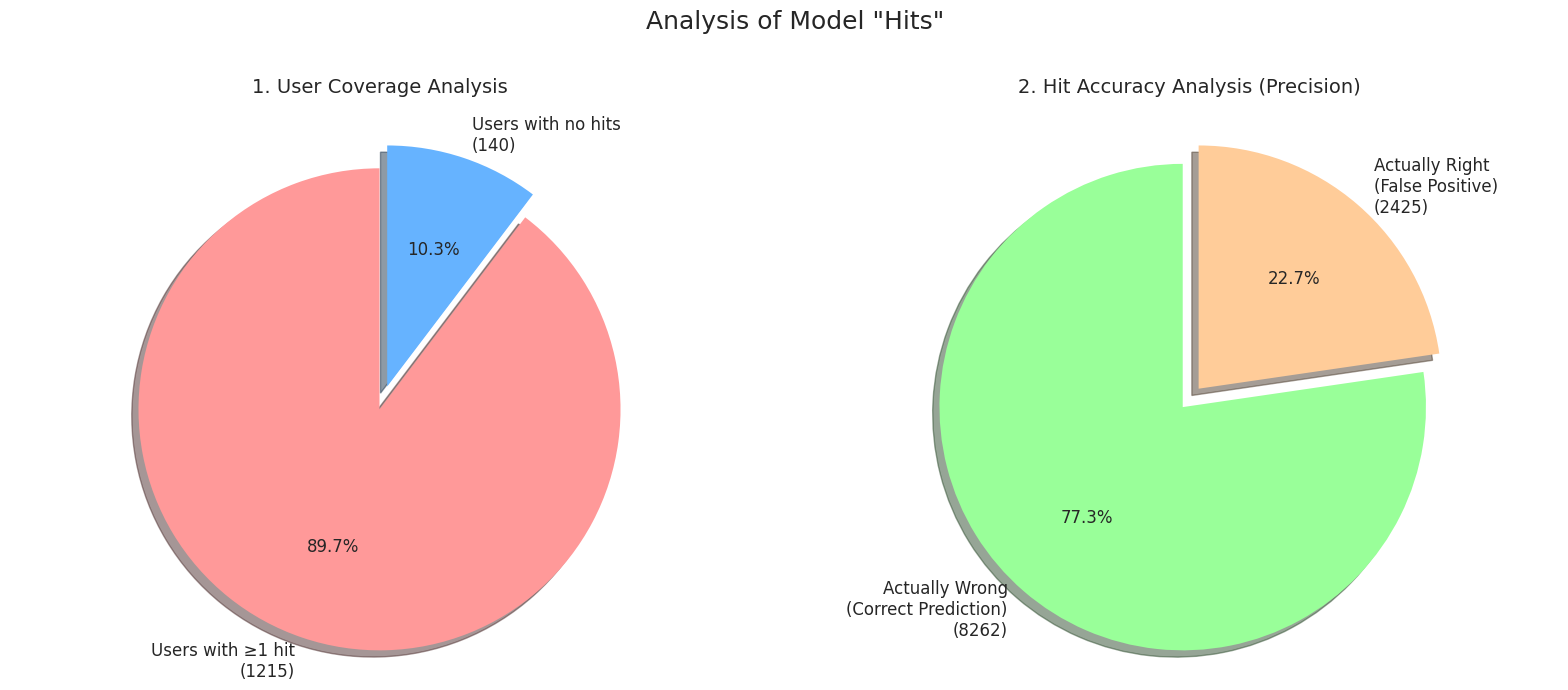

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

# Set font for plots (removed Chinese-specific settings)
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# --- Add this function to your code ---
def plot_pie_charts(results, test_df):
    """
    Generate two pie charts to visualize user coverage and hit accuracy.
    
    Args:
        results (dict): Results dictionary returned from the run_sequential_validation function.
        test_df (pd.DataFrame): Cleaned test data DataFrame.
    """
    print("\n" + "=" * 60)
    print("Generating Coverage and Accuracy Pie Charts")
    print("=" * 60)
    
    # Prepare canvas: 1 row, 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle('Analysis of Model "Hits"', fontsize=18)

    # --- Chart 1: User Coverage Analysis ---
    
    # 1.1 Calculate data
    total_users = results.get('total_users', len(test_df))
    hit_users = results.get('users_with_hits', 0)
    non_hit_users = total_users - hit_users

    # 1.2 Print raw data
    print("--- User Coverage Analysis ---")
    print(f"Total users: {total_users}")
    print(f"Users with at least one hit: {hit_users} ({hit_users/total_users:.2%})")
    print(f"Users with no hits: {non_hit_users} ({non_hit_users/total_users:.2%})")
    print("-" * 25)

    # 1.3 Plotting
    labels1 = [f'Users with ≥1 hit\n({hit_users})', f'Users with no hits\n({non_hit_users})']
    sizes1 = [hit_users, non_hit_users]
    explode1 = (0.1, 0)  # Highlight "hit users"
    colors1 = ['#ff9999', '#66b3ff']

    axes[0].pie(sizes1, explode=explode1, labels=labels1, colors=colors1, autopct='%1.1f%%',
                shadow=True, startangle=90, textprops={'fontsize': 12})
    axes[0].axis('equal')  # Ensure pie is circular
    axes[0].set_title('1. User Coverage Analysis', fontsize=14, pad=20)


    # --- Chart 2: Hit Accuracy Analysis ---

    # 2.1 Calculate data
    if 'hit_details' in results and results['hit_details']:
        hit_df = pd.DataFrame(results['hit_details'])
        total_hits = len(hit_df)
        
        # Count actual responses after hits
        actual_responses = hit_df['actual_response'].value_counts()
        actually_wrong = actual_responses.get(0, 0)  # Actually incorrect (correct prediction)
        actually_right = actual_responses.get(1, 0)   # Actually correct (false positive)

        # 2.2 Print raw data
        print("\n--- Hit Accuracy Analysis ---")
        print(f"Total hits: {total_hits}")
        print(f"Hits where student was actually wrong (correct prediction): {actually_wrong} ({actually_wrong/total_hits:.2%})")
        print(f"Hits where student was actually right (false positive): {actually_right} ({actually_right/total_hits:.2%})")
        
        # 2.3 Plotting
        labels2 = [f'Actually Wrong\n(Correct Prediction)\n({actually_wrong})', 
                  f'Actually Right\n(False Positive)\n({actually_right})']
        sizes2 = [actually_wrong, actually_right]
        explode2 = (0, 0.1)  # Highlight "false positives"
        colors2 = ['#99ff99', '#ffcc99']

        axes[1].pie(sizes2, explode=explode2, labels=labels2, colors=colors2, autopct='%1.1f%%',
                    shadow=True, startangle=90, textprops={'fontsize': 12})
        axes[1].axis('equal')
        axes[1].set_title('2. Hit Accuracy Analysis (Precision)', fontsize=14, pad=20)

    else:
        axes[1].text(0.5, 0.5, 'No "hit" data found', ha='center', va='center', fontsize=12)
        axes[1].set_title('2. Hit Accuracy Analysis', fontsize=14, pad=20)


    plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout for main title
    plt.savefig('hit_pie_charts_analysis.png', dpi=300)
    plt.show()


# --- How to call ---
# Assuming your `results` and `cleaned_test_df` are already generated
plot_pie_charts(results, cleaned_test_df)


This step is to make the results of the sequence verification into two pieces of cake that can be understood at a glance: the left figure quantifies the "coverage" (the proportion of users with or without at least one hit in the whole), and the right figure quantifies the "hit accuracy" (the proportion of actually doing wrong vs actually doing right in all hits, that is, the false alarm rate), and prints the corresponding original count and percentage to the console; If you fail to hit the details, you will be prompted directly that there is no data. In short, it visualizes the two things of "how many people are covered and whether their lives are accurate" in the model and places them in hit_pie_charts_analysis.png, which is convenient for quick external display and self inspection.

### 3.2.2 Hit rate graph


Generating Global Hit Ratio Pie Chart
Total predictable questions: 81300
Total hit questions: 10687
Hit ratio: 0.1315 (13.15%)


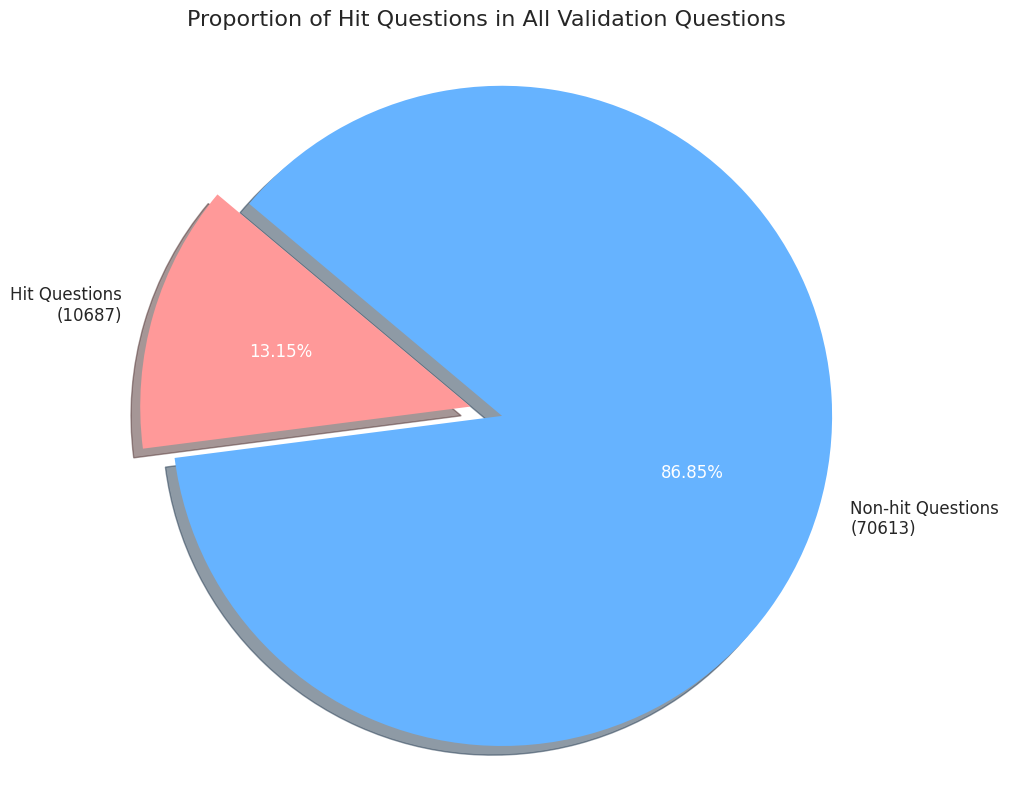

In [28]:
import pandas as pd
import matplotlib.pyplot as plt

# Set font for plots
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

def plot_global_hit_pie_chart(results, test_df):
    """
    Generate a pie chart showing the global proportion of hit questions 
    among all validation questions.
    
    Args:
        results (dict): Results dictionary from the run_sequential_validation function.
        test_df (pd.DataFrame): Cleaned test data DataFrame.
    """
    print("\n" + "=" * 60)
    print("Generating Global Hit Ratio Pie Chart")
    print("=" * 60)

    # 1. Get total number of hits
    total_hits = results.get('total_hits', 0)

    # 2. Calculate total predictable questions (denominator)
    total_predictable_questions = 81300  # Fixed based on your dataset

    # 3. Calculate non-hit questions
    non_hit_questions = max(total_predictable_questions - total_hits, 0)
        
    # 4. Prepare data for visualization
    labels = [
        f'Hit Questions\n({total_hits})', 
        f'Non-hit Questions\n({non_hit_questions})'
    ]
    sizes = [total_hits, non_hit_questions]
    
    # Highlight the "Hit" portion
    explode = (0.1, 0)  
    colors = ['#ff9999', '#66b3ff']

    # 5. Create and configure the plot
    plt.figure(figsize=(10, 8))
    
    patches, texts, autotexts = plt.pie(
        sizes, 
        explode=explode, 
        labels=labels, 
        colors=colors, 
        autopct='%1.2f%%',  # Show percentages with 2 decimals
        shadow=True, 
        startangle=140,
        textprops={'fontsize': 12}
    )
    
    # Enhance percentage text appearance
    for autotext in autotexts:
        autotext.set_fontsize(12)
        autotext.set_color('white')
    
    plt.title('Proportion of Hit Questions in All Validation Questions', 
              fontsize=16, pad=20)
    plt.axis('equal')  # Ensure pie is circular
    
    # Print statistics
    print(f"Total predictable questions: {total_predictable_questions}")
    print(f"Total hit questions: {total_hits}")
    print(f"Hit ratio: {total_hits/total_predictable_questions:.4f} ({total_hits/total_predictable_questions:.2%})")
    
    plt.tight_layout()
    plt.savefig('global_hit_rate_pie_chart.png', dpi=300)
    plt.show()


# --- How to call ---
# Assuming your `results` and `cleaned_test_df` are already generated
plot_global_hit_pie_chart(results, cleaned_test_df)


This step is to generate the visualization of "percentage of hit questions in all validation questions": the function plot_global_hit_pie_chart (results, test_df) reads the results['total_hits'], calculates the number of missed questions with a fixed total of 81300, draws a pie chart according to "hit questions vs Miss questions" (highlights the middle part of the life and displays the percentage and number), prints the total number of questions, hits and percentage of hits on the console, and saves the chart as global_hit_rate_pie_chart.png.

### 3.2.3 detailed output data distrabution

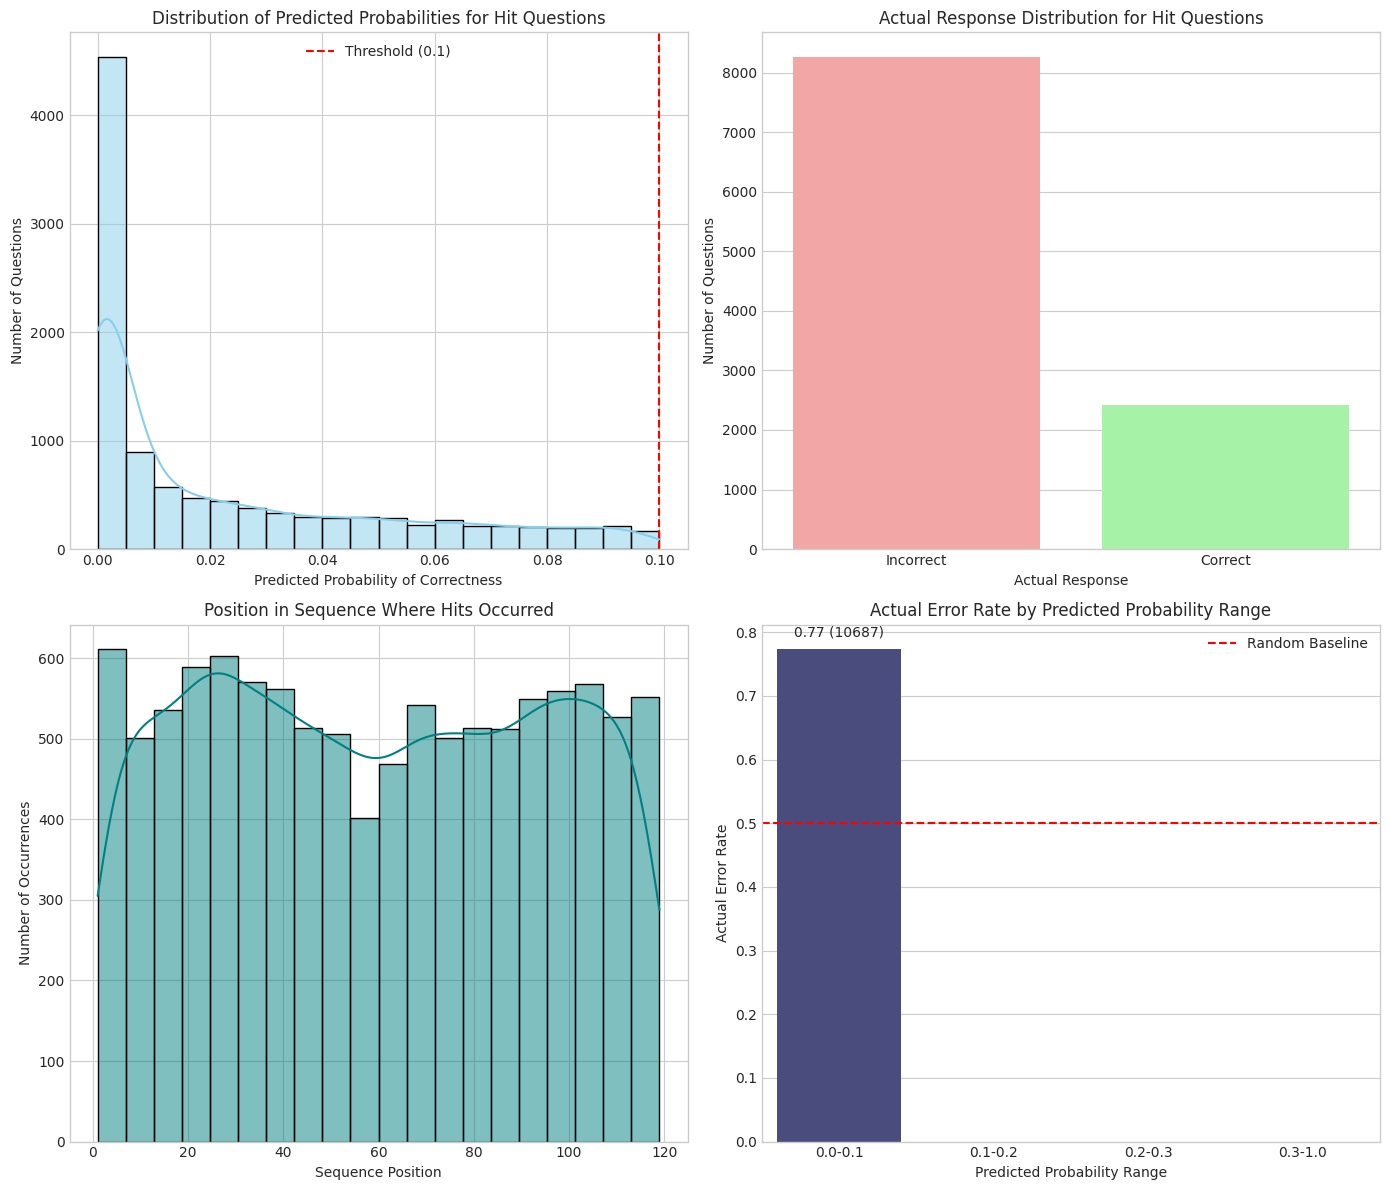


Detailed Hit Statistics:
- Questions with predicted probability ≤ 0.1: 10687
  → Actual error rate: 77.31%
- Questions with predicted probability 0.1-0.2: 0
  → Actual error rate: nan%
- Questions with predicted probability 0.2-0.3: 0
  → Actual error rate: nan%
- Questions with predicted probability > 0.3: 0
  → Actual error rate: nan%


In [29]:
# Add this visualization after the results are generated

if results['hit_details']:
    hit_df = pd.DataFrame(results['hit_details'])
    
    # Create a 2x2 grid for visualizations
    plt.figure(figsize=(14, 12))
    
    # 1. Distribution of predicted probabilities for hit questions
    plt.subplot(2, 2, 1)
    sns.histplot(hit_df['predicted_prob'], bins=20, kde=True, color='skyblue')
    plt.axvline(x=analysis_config.PREDICTION_THRESHOLD, color='r', linestyle='--', 
                label=f'Threshold ({analysis_config.PREDICTION_THRESHOLD})')
    plt.title("Distribution of Predicted Probabilities for Hit Questions")
    plt.xlabel("Predicted Probability of Correctness")
    plt.ylabel("Number of Questions")
    plt.legend()
    
    # 2. Actual response distribution for hit questions
    plt.subplot(2, 2, 2)
    # Map actual_response to meaningful labels
    response_labels = hit_df['actual_response'].map({0: 'Incorrect', 1: 'Correct'})
    sns.countplot(x=response_labels, palette=['#ff9999', '#99ff99'])
    plt.title("Actual Response Distribution for Hit Questions")
    plt.xlabel("Actual Response")
    plt.ylabel("Number of Questions")
    
    # 3. Position in sequence where hits occurred
    plt.subplot(2, 2, 3)
    sns.histplot(hit_df['hit_at_step'], bins=20, color='teal', kde=True)
    plt.title("Position in Sequence Where Hits Occurred")
    plt.xlabel("Sequence Position")
    plt.ylabel("Number of Occurrences")
    
    # 4. Relationship between predicted probability and actual error rate
    plt.subplot(2, 2, 4)
    # Create probability bins
    bins = [0, 0.1, 0.2, 0.3, 1]
    labels = ['0.0-0.1', '0.1-0.2', '0.2-0.3', '0.3-1.0']
    hit_df['prob_bin'] = pd.cut(hit_df['predicted_prob'], bins=bins, labels=labels)
    
    # Calculate actual error rate (1 - mean of actual_response)
    bin_stats = hit_df.groupby('prob_bin')['actual_response'].agg(
        total_questions='count',
        error_rate=lambda x: 1 - x.mean()
    ).reset_index()
    
    # Plot with improved formatting
    bar_plot = sns.barplot(x='prob_bin', y='error_rate', data=bin_stats, palette='viridis')
    plt.title("Actual Error Rate by Predicted Probability Range")
    plt.xlabel("Predicted Probability Range")
    plt.ylabel("Actual Error Rate")
    plt.axhline(y=0.5, color='r', linestyle='--', label='Random Baseline')
    
    # Add value labels on bars
    for index, row in bin_stats.iterrows():
        bar_plot.text(index, row['error_rate'] + 0.02, 
                     f"{row['error_rate']:.2f} ({row['total_questions']})", 
                     ha='center', fontsize=10)
    
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('detailed_validation_results.png', dpi=300)
    plt.show()
    
    # Print detailed statistics
    print("\nDetailed Hit Statistics:")
    print(f"- Questions with predicted probability ≤ 0.1: {len(hit_df[hit_df['predicted_prob'] <= 0.1])}")
    print(f"  → Actual error rate: {1 - hit_df[hit_df['predicted_prob'] <= 0.1]['actual_response'].mean():.2%}")
    
    print(f"- Questions with predicted probability 0.1-0.2: {len(hit_df[(hit_df['predicted_prob'] > 0.1) & (hit_df['predicted_prob'] <= 0.2)])}")
    print(f"  → Actual error rate: {1 - hit_df[(hit_df['predicted_prob'] > 0.1) & (hit_df['predicted_prob'] <= 0.2)]['actual_response'].mean():.2%}")
    
    print(f"- Questions with predicted probability 0.2-0.3: {len(hit_df[(hit_df['predicted_prob'] > 0.2) & (hit_df['predicted_prob'] <= 0.3)])}")
    print(f"  → Actual error rate: {1 - hit_df[(hit_df['predicted_prob'] > 0.2) & (hit_df['predicted_prob'] <= 0.3)]['actual_response'].mean():.2%}")
    
    print(f"- Questions with predicted probability > 0.3: {len(hit_df[hit_df['predicted_prob'] > 0.3])}")
    print(f"  → Actual error rate: {1 - hit_df[hit_df['predicted_prob'] > 0.3]['actual_response'].mean():.2%}")


This step is to make an in-depth portrait and calibration check on the "hit samples": gather the results['hit_details'] into hit_df, and use the 2 × 2 panel to look at (1) the distribution of the prediction accuracy rate of the hit questions and check whether the threshold is reasonable with the red dotted line, (2) the right and wrong proportion of the true answer of the hit questions, (3) the location of the hit in the answer sequence (whether it is concentrated in the front/back segment, indicating that fatigue or difficulty moves up), (4) calculate the actual error rate in barrels according to the prediction probability, and evaluate the model discrimination and probability calibration by comparing the histogram with the 0.5 random baseline; Then print the sample size and actual error rate of each probability bucket, and save the whole board diagram as detailed_validation_results.png for standby.

### 3.2.4 User change in user error rate as  question number increases

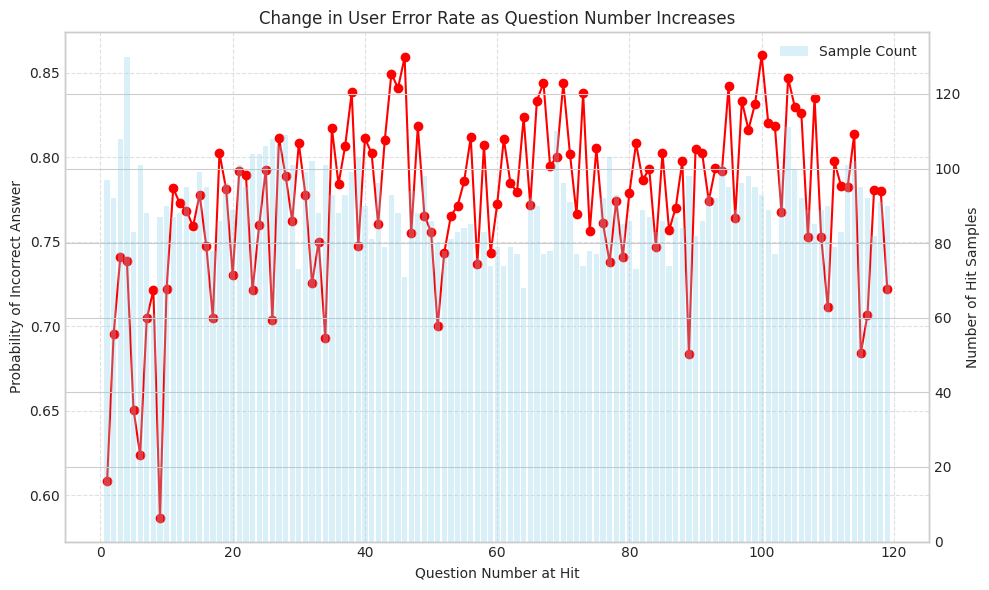

In [30]:
def plot_error_rate_vs_question_number(hit_details):
    """
    Draw a curve chart showing the probability of users answering questions incorrectly as the number of questions increases.
    """
    df = pd.DataFrame(hit_details)
    if df.empty:
        print("No hit data available for plotting error rate curve.")
        return
    
    # Calculate the error rate based on the position of the question number where the hit occurred.
    grouped = df.groupby('hit_at_step')['actual_response']
    error_rates = grouped.apply(lambda x: 1 - x.mean())  # Error rate = 1 - Accuracy rate
    counts = grouped.count()
    plt.figure(figsize=(10, 6))
    plt.plot(error_rates.index, error_rates.values, marker='o', linestyle='-', color='red', label='Error Rate')
    plt.xlabel("Question Number at Hit")
    plt.ylabel("Probability of Incorrect Answer")
    plt.title("Change in User Error Rate as Question Number Increases")
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Optionally: overlay sample count bar chart
    ax2 = plt.twinx()
    ax2.bar(counts.index, counts.values, alpha=0.3, label='Sample Count', color='skyblue')
    ax2.set_ylabel("Number of Hit Samples")
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.savefig("error_rate_vs_question_number.png", dpi=300)
    plt.show()

plot_error_rate_vs_question_number(results['hit_details'])

This function is used to analyze the change of the error rate in the "hit samples" with the position of the question sequence: first, convert hit_details into dataframe, and calculate the actual error rate (1- mean (actual_response), the higher it is, the easier it is to make a mistake) and the number of hit samples in each position by grouping according to hit_at_step; Then draw a two axis chart. The red broken line indicates the trend of error rate in different positions of the question sequence, and the light blue column indicates the sample size of the corresponding position (right Y-axis), so as to observe "how many mistakes" and "enough samples" at the same time; If there is no data, prompt and return directly; Finally, save the diagram as error_rate_vs_question_number.png. It should be emphasized that what is shown here is the error rate under the condition of hit set changing with the question order, rather than the overall error rate curve of the total number of questions.

### 3.2.5 test Output at multiple thresholds

Starting Multi-threshold Validation Analysis

Cleaning test data... (Original size: 3613 rows)


100%|██████████| 3613/3613 [00:00<00:00, 4223.24it/s]


Cleaning complete. Remaining rows: 1355

Starting multi-threshold analysis, thresholds: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

Analyzing threshold: 0.1


Threshold 0.1: 100%|██████████| 1355/1355 [02:56<00:00,  7.70it/s]



Analyzing threshold: 0.2


...


Analyzing threshold: 0.8


Threshold 0.8: 100%|██████████| 1355/1355 [03:17<00:00,  6.86it/s]



Analyzing threshold: 0.9


Threshold 0.9: 100%|██████████| 1355/1355 [02:53<00:00,  7.82it/s]



Multi-threshold Analysis Summary
 Threshold  Total Users  Users with Hits Hit Rate  Total Hits Avg Hits per User  Correctly Predicted Wrong Error Rate  Max Hits per User
       0.1         1355             1215    89.7%       10687              7.89                       8262      77.3%                 69
       0.2         1355             1253    92.5%       13879             10.24                       9947      71.7%                 80
       0.3         1355             1279    94.4%       16769             12.38                      11353      67.7%                 85
       0.4         1355             1299    95.9%       19583             14.45                      12592      64.3%                 87
       0.5         1355             1314    97.0%       22594             16.67                      13842      61.3%                 96
       0.6         1355             1325    97.8%       26090             19.25                      15112      57.9%                100
       

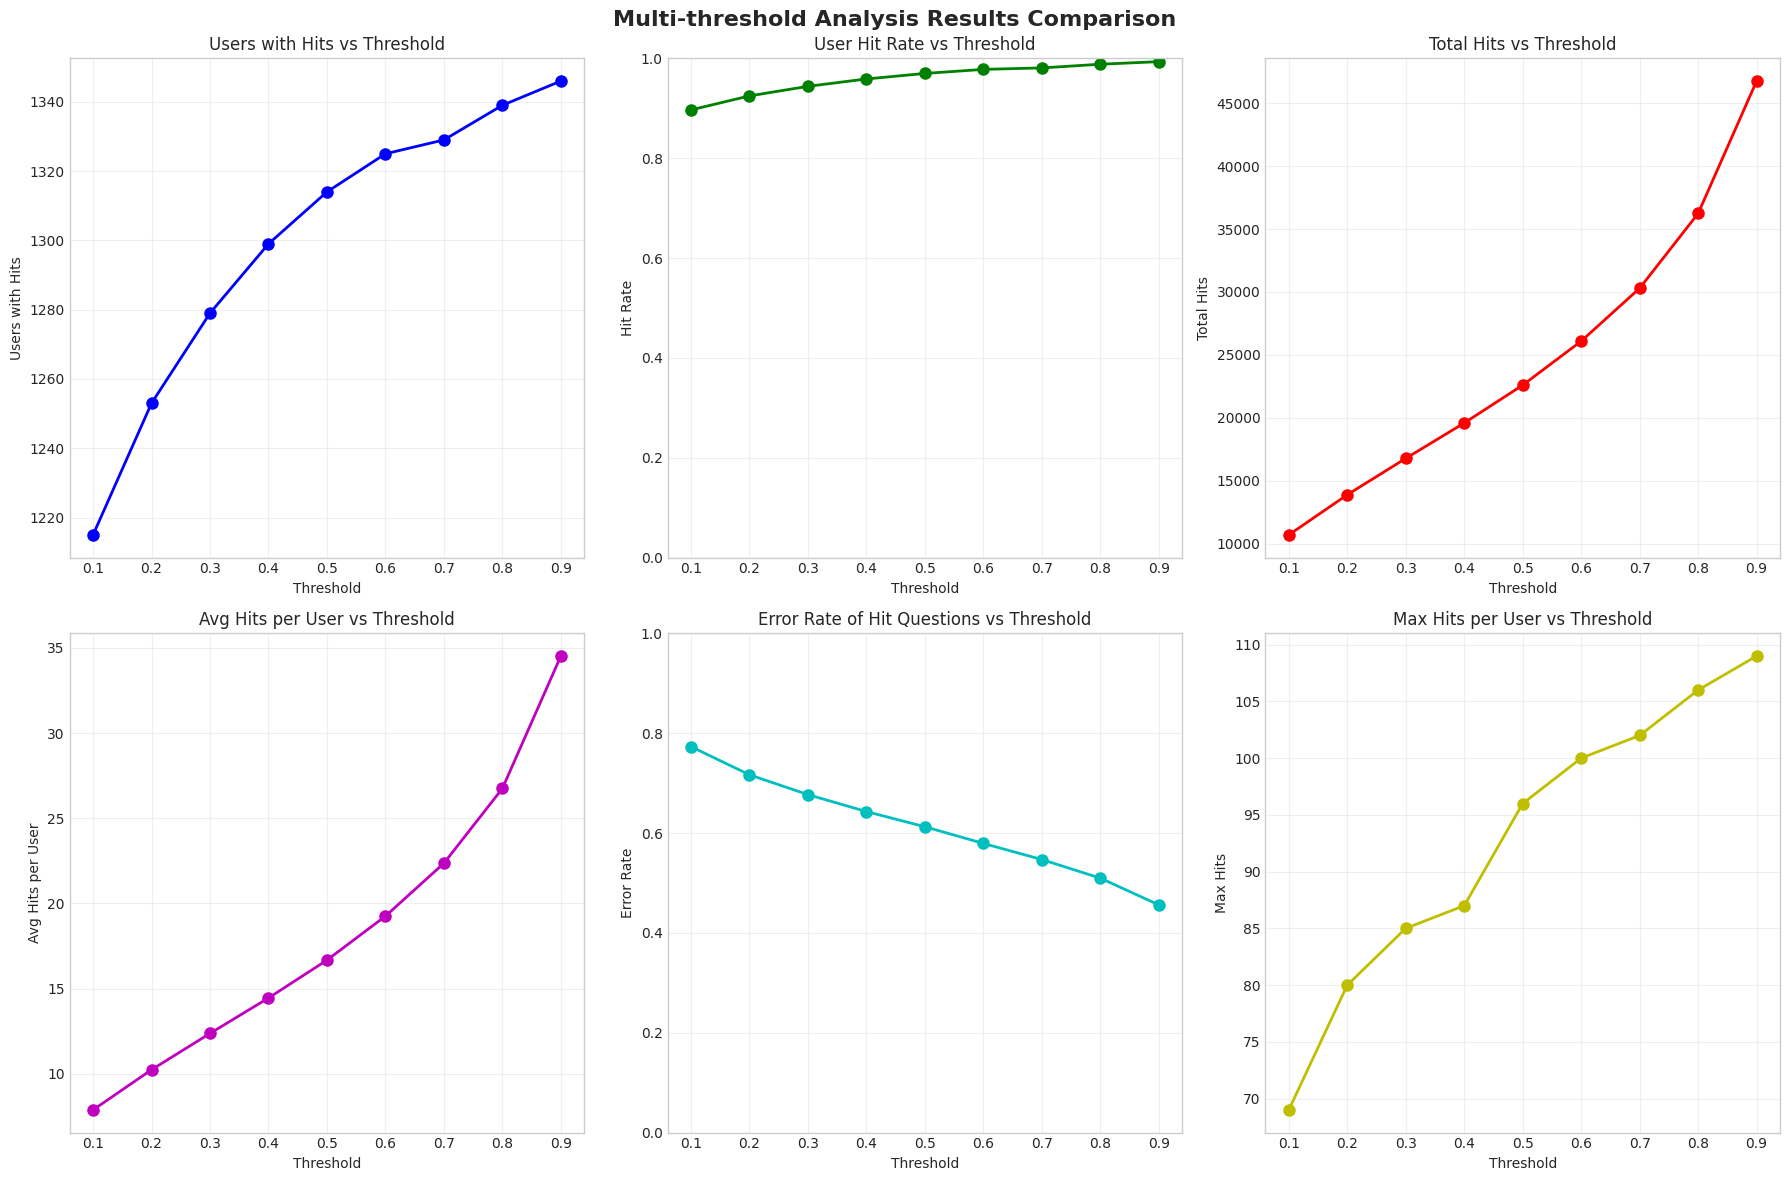

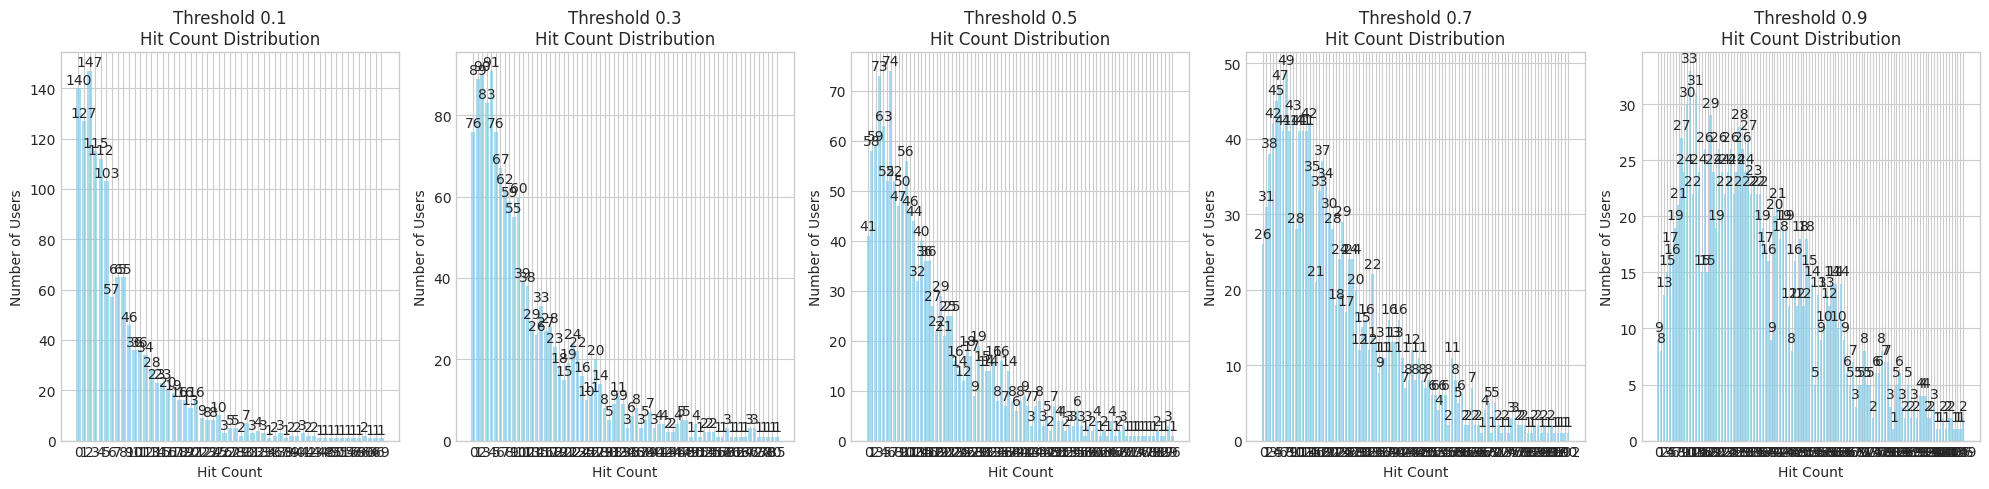


Threshold Performance Analysis
Best hit rate threshold: 0.9 (Hit rate: 99.3%)
Best total hits threshold: 0.9 (Total hits: 46771.0)
Best error rate threshold: 0.1 (Error rate: 77.3%)


In [32]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import json
import warnings
import torch.nn as nn
import os
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

warnings.filterwarnings('ignore')

# Set font support for English
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Helvetica', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

# --- Configuration Classes ---
class AnalysisConfig:
    TEST_FILE_PATH = "data/XES3G5M/kc_level/test.csv"
    QUESTIONS_META_PATH = 'data/XES3G5M/metadata/questions.json'
    MAX_LENGTH = 120
    MAX_DAYS = 90
    # List of thresholds to analyze
    PREDICTION_THRESHOLDS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
    MODEL_PATH = "saved_models/adgkt_model_epoch10.pth"
    QID_MAP_PATH = "saved_models/qid_map.json"
    CID_MAP_PATH = "saved_models/cid_map.json"
    TRAINING_CONFIG_PATH = "saved_models/training_config.json"

analysis_config = AnalysisConfig()
analysis_config.MAX_TIME_DIFF_MS = analysis_config.MAX_DAYS * 24 * 60 * 60 * 1000

# --- Model Definition (ADGKT) ---
class ADGKT(nn.Module):
    def __init__(self, num_q, num_c, embed_size, hidden_size, num_heads, dropout):
        super(ADGKT, self).__init__()
        self.num_q = num_q
        self.num_c = num_c
        self.q_embed = nn.Embedding(num_q, embed_size)
        self.c_embed = nn.Embedding(num_c, embed_size)
        self.r_embed = nn.Embedding(2, embed_size)
        self.interaction_fusion = nn.Linear(embed_size * 2, hidden_size)
        self.attention = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.predict_fusion = nn.Linear(hidden_size * 2, hidden_size)
        self.out = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm1 = nn.LayerNorm(hidden_size)
        self.layer_norm2 = nn.LayerNorm(hidden_size)

    def forward(self, input_q, input_c, input_r, target_q, target_c):
        q_emb = self.q_embed(input_q)
        c_emb = self.c_embed(input_c)
        r_emb = self.r_embed(input_r)
        interaction_emb = self.interaction_fusion(torch.cat([q_emb, c_emb], dim=-1)) + r_emb
        attn_input = self.layer_norm1(interaction_emb)
        attn_output, _ = self.attention(attn_input, attn_input, attn_input)
        attn_output = self.dropout(attn_output) + interaction_emb
        gru_input = self.layer_norm2(attn_output)
        gru_output, _ = self.gru(gru_input)
        target_q_emb = self.q_embed(target_q)
        target_c_emb = self.c_embed(target_c)
        predict_input = torch.cat([gru_output, target_q_emb + target_c_emb], dim=-1)
        predict_hidden = torch.relu(self.predict_fusion(predict_input))
        output = self.out(predict_hidden)
        return torch.sigmoid(output).squeeze(-1)

# --- Validation Analysis Function ---
def run_sequential_validation_with_threshold(model, test_df, config, threshold, qid_to_module_map, device, qid_map, cid_map):
    """
    Run sequential validation for a specific threshold
    """
    model.eval()
    results = {
        'threshold': threshold,
        'total_users': len(test_df),
        'users_with_hits': 0,
        'total_hits': 0,
        'correctly_predicted_wrong_answers': 0,
        'hit_details': [],
        'user_hit_counts': defaultdict(int),
        'hit_count_distribution': defaultdict(int),
        'hit_per_user': []
    }
  
    for index, row in tqdm(test_df.iterrows(), total=len(test_df), desc=f"Threshold {threshold}"):
        q_seq = str(row['questions']).split(',')
        c_seq = str(row['concepts']).split(',')
        r_seq = [int(r) for r in str(row['responses']).split(',')]
      
        user_hits = 0
        correctly_predicted_wrong = 0
      
        if len(q_seq) < 2:
            continue
      
        for i in range(1, len(q_seq)):
            hist_q = q_seq[:i]
            hist_c = c_seq[:i]
            hist_r = r_seq[:i]
          
            target_q = q_seq[i]
            target_c = c_seq[i]
            actual_response = r_seq[i]
          
            q_hist_ids = [qid_map.get(q) for q in hist_q]
            c_hist_ids = [cid_map.get(c) for c in hist_c]
            target_q_id = qid_map.get(target_q)
            target_c_id = cid_map.get(target_c)

            if None in q_hist_ids or None in c_hist_ids or target_q_id is None or target_c_id is None:
                continue

            history_len = len(q_hist_ids)
            input_q = np.zeros(config.MAX_SEQ_LEN - 1, dtype=int)
            input_c = np.zeros(config.MAX_SEQ_LEN - 1, dtype=int)
            input_r = np.zeros(config.MAX_SEQ_LEN - 1, dtype=int)

            if history_len >= config.MAX_SEQ_LEN - 1:
                input_q[:] = q_hist_ids[-(config.MAX_SEQ_LEN - 1):]
                input_c[:] = c_hist_ids[-(config.MAX_SEQ_LEN - 1):]
                input_r[:] = hist_r[-(config.MAX_SEQ_LEN - 1):]
            else:
                input_q[-history_len:] = q_hist_ids
                input_c[-history_len:] = c_hist_ids
                input_r[-history_len:] = hist_r
          
            input_q = torch.LongTensor([input_q]).to(device)
            input_c = torch.LongTensor([input_c]).to(device)
            input_r = torch.LongTensor([input_r]).to(device)
            target_q = torch.LongTensor([target_q_id] * (config.MAX_SEQ_LEN - 1)).to(device).unsqueeze(0)
            target_c = torch.LongTensor([target_c_id] * (config.MAX_SEQ_LEN - 1)).to(device).unsqueeze(0)

            with torch.no_grad():
                pred_prob = model(input_q, input_c, input_r, target_q, target_c)
                final_pred = pred_prob[0, -1].item()
          
            # Use current threshold for decision
            if final_pred <= threshold:
                user_hits += 1
                if actual_response == 0:
                    correctly_predicted_wrong += 1
              
                results['hit_details'].append({
                    'user_index': index,
                    'hit_at_step': i,
                    'predicted_prob': final_pred,
                    'actual_response': actual_response
                })

        if user_hits > 0:
            results['users_with_hits'] += 1
        results['total_hits'] += user_hits
        results['correctly_predicted_wrong_answers'] += correctly_predicted_wrong
      
        results['user_hit_counts'][index] = user_hits
        results['hit_count_distribution'][user_hits] += 1
        results['hit_per_user'].append(user_hits)
  
    return results

# --- Comprehensive Analysis Function ---
def run_multi_threshold_analysis(model, test_df, config, analysis_config, qid_to_module_map, device, qid_map, cid_map):
    """
    Run multi-threshold comprehensive analysis
    """
    all_results = {}
    summary_stats = []
    
    print(f"\nStarting multi-threshold analysis, thresholds: {analysis_config.PREDICTION_THRESHOLDS}")
    print("=" * 80)
    
    for threshold in analysis_config.PREDICTION_THRESHOLDS:
        print(f"\nAnalyzing threshold: {threshold}")
        results = run_sequential_validation_with_threshold(
            model, test_df, config, threshold, qid_to_module_map, device, qid_map, cid_map
        )
        all_results[threshold] = results
        
        # Calculate statistics
        hit_per_user = np.array(results['hit_per_user'])
        hit_rate = results['users_with_hits'] / results['total_users'] if results['total_users'] > 0 else 0
        avg_hits_per_user = np.mean(hit_per_user) if hit_per_user.size > 0 else 0
        error_rate = (results['correctly_predicted_wrong_answers'] / 
                     results['total_hits']) if results['total_hits'] > 0 else 0
        
        summary_stats.append({
            'threshold': threshold,
            'total_users': results['total_users'],
            'users_with_hits': results['users_with_hits'],
            'hit_rate': hit_rate,
            'total_hits': results['total_hits'],
            'avg_hits_per_user': avg_hits_per_user,
            'correctly_predicted_wrong': results['correctly_predicted_wrong_answers'],
            'error_rate': error_rate,
            'max_hits_per_user': np.max(hit_per_user) if hit_per_user.size > 0 else 0
        })
    
    return all_results, summary_stats

# --- Visualization Functions ---
def visualize_threshold_comparison(summary_stats):
    """
    Visualize comparison of results across thresholds
    """
    df = pd.DataFrame(summary_stats)
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Multi-threshold Analysis Results Comparison', fontsize=16, fontweight='bold')
    
    # 1. Number of users with hits
    axes[0, 0].plot(df['threshold'], df['users_with_hits'], 'bo-', linewidth=2, markersize=8)
    axes[0, 0].set_title('Users with Hits vs Threshold')
    axes[0, 0].set_xlabel('Threshold')
    axes[0, 0].set_ylabel('Users with Hits')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Hit rate
    axes[0, 1].plot(df['threshold'], df['hit_rate'], 'go-', linewidth=2, markersize=8)
    axes[0, 1].set_title('User Hit Rate vs Threshold')
    axes[0, 1].set_xlabel('Threshold')
    axes[0, 1].set_ylabel('Hit Rate')
    axes[0, 1].set_ylim(0, 1)
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Total hits
    axes[0, 2].plot(df['threshold'], df['total_hits'], 'ro-', linewidth=2, markersize=8)
    axes[0, 2].set_title('Total Hits vs Threshold')
    axes[0, 2].set_xlabel('Threshold')
    axes[0, 2].set_ylabel('Total Hits')
    axes[0, 2].grid(True, alpha=0.3)
    
    # 4. Average hits per user
    axes[1, 0].plot(df['threshold'], df['avg_hits_per_user'], 'mo-', linewidth=2, markersize=8)
    axes[1, 0].set_title('Avg Hits per User vs Threshold')
    axes[1, 0].set_xlabel('Threshold')
    axes[1, 0].set_ylabel('Avg Hits per User')
    axes[1, 0].grid(True, alpha=0.3)
    
    # 5. Error rate
    axes[1, 1].plot(df['threshold'], df['error_rate'], 'co-', linewidth=2, markersize=8)
    axes[1, 1].set_title('Error Rate of Hit Questions vs Threshold')
    axes[1, 1].set_xlabel('Threshold')
    axes[1, 1].set_ylabel('Error Rate')
    axes[1, 1].set_ylim(0, 1)
    axes[1, 1].grid(True, alpha=0.3)
    
    # 6. Max hits per user
    axes[1, 2].plot(df['threshold'], df['max_hits_per_user'], 'yo-', linewidth=2, markersize=8)
    axes[1, 2].set_title('Max Hits per User vs Threshold')
    axes[1, 2].set_xlabel('Threshold')
    axes[1, 2].set_ylabel('Max Hits')
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('threshold_comparison_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_hit_distribution_by_threshold(all_results, selected_thresholds=[0.1, 0.3, 0.5, 0.7, 0.9]):
    """
    Visualize hit distribution comparison for selected thresholds
    """
    fig, axes = plt.subplots(1, len(selected_thresholds), figsize=(4*len(selected_thresholds), 5))
    if len(selected_thresholds) == 1:
        axes = [axes]
    
    for idx, threshold in enumerate(selected_thresholds):
        if threshold in all_results:
            results = all_results[threshold]
            hit_counts = sorted(results['hit_count_distribution'].items())
            hit_x = [str(x[0]) for x in hit_counts]
            hit_y = [x[1] for x in hit_counts]
            
            axes[idx].bar(hit_x, hit_y, color='skyblue', alpha=0.7)
            axes[idx].set_title(f'Threshold {threshold}\nHit Count Distribution')
            axes[idx].set_xlabel('Hit Count')
            axes[idx].set_ylabel('Number of Users')
            
            # Add count labels
            for i, v in enumerate(hit_y):
                if v > 0:
                    axes[idx].text(i, v + 0.5, str(v), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig('hit_distribution_by_threshold.png', dpi=300, bbox_inches='tight')
    plt.show()

# --- Helper functions ---
def load_id_maps():
    with open(analysis_config.QID_MAP_PATH, "r") as f:
        qid_map = json.load(f)
    with open(analysis_config.CID_MAP_PATH, "r") as f:
        cid_map = json.load(f)
    return qid_map, cid_map

def load_training_config():
    with open(analysis_config.TRAINING_CONFIG_PATH, "r") as f:
        config_data = json.load(f)
    class TrainingConfig: pass
    config = TrainingConfig()
    for key, value in config_data.items():
        setattr(config, key, value)
    return config
  
def clean_test_data(test_df_raw, qid_to_module_map, known_qids):
    print(f"\nCleaning test data... (Original size: {len(test_df_raw)} rows)")
    processed_rows = []
    for index, row in tqdm(test_df_raw.iterrows(), total=len(test_df_raw)):
        new_row = row.copy()
        questions_list = str(row['questions']).split(',')
        keep_mask = [qid in known_qids for qid in questions_list]

        if not any(keep_mask): continue

        for col in ['questions', 'responses', 'timestamps']:
            original_list = str(row[col]).split(',')
            if len(original_list) == len(questions_list):
                filtered_list = [item for item, keep in zip(original_list, keep_mask) if keep]
                new_row[col] = ','.join(filtered_list)
      
        filtered_qids = new_row['questions'].split(',')
        new_concepts = [qid_to_module_map.get(qid, 'Unknown') for qid in filtered_qids]
        new_row['concepts'] = ','.join(new_concepts)
      
        if len(filtered_qids) > analysis_config.MAX_LENGTH:
            for col in ['questions', 'concepts', 'responses', 'timestamps']:
                new_row[col] = ','.join(new_row[col].split(',')[:analysis_config.MAX_LENGTH])

        if 'timestamps' in new_row and pd.notna(new_row['timestamps']):
            timestamps_list = [int(ts) for ts in str(new_row['timestamps']).split(',') if ts]
            if len(timestamps_list) > 1:
                if (timestamps_list[-1] - timestamps_list[0]) > analysis_config.MAX_TIME_DIFF_MS:
                    continue
      
        processed_rows.append(new_row)
  
    cleaned_df = pd.DataFrame(processed_rows)
    print(f"Cleaning complete. Remaining rows: {len(cleaned_df)}")
    return cleaned_df

def print_summary_table(summary_stats):
    """
    Print summary table of analysis results
    """
    df = pd.DataFrame(summary_stats)
    
    print("\n" + "=" * 100)
    print("Multi-threshold Analysis Summary")
    print("=" * 100)
    
    # Format output
    formatted_df = df.copy()
    formatted_df['hit_rate'] = formatted_df['hit_rate'].apply(lambda x: f"{x:.1%}")
    formatted_df['avg_hits_per_user'] = formatted_df['avg_hits_per_user'].apply(lambda x: f"{x:.2f}")
    formatted_df['error_rate'] = formatted_df['error_rate'].apply(lambda x: f"{x:.1%}")
    
    # Rename columns
    formatted_df.columns = ['Threshold', 'Total Users', 'Users with Hits', 'Hit Rate', 'Total Hits', 
                           'Avg Hits per User', 'Correctly Predicted Wrong', 'Error Rate', 'Max Hits per User']
    
    print(formatted_df.to_string(index=False))
    print("=" * 100)

# --- Main Execution ---
if __name__ == "__main__":
    print("=" * 80)
    print("Starting Multi-threshold Validation Analysis")
    print("=" * 80)
  
    try:
        # Load necessary files
        qid_map, cid_map = load_id_maps()
        config = load_training_config()
        test_df_raw = pd.read_csv(analysis_config.TEST_FILE_PATH)
      
        module_translation = {
            "Geometry": "Geometry",
            "Application Problems": "Application Problems", 
            "Number Theory": "Number Theory",
            "Combinatorics": "Combinatorics",
            "Journey Problems": "Journey Problems",
            "Counting": "Counting",
            "Calculation": "Calculation"
        }
        with open(analysis_config.QUESTIONS_META_PATH, 'r', encoding='utf-8') as f:
            questions_data = json.load(f)
      
        qid_to_module_map = {}
        for qid, details in questions_data.items():
            routes = details.get('kc_routes', [])
            for path in routes:
                parts = path.split('----')
                if parts[0] == '拓展思维' and len(parts) > 1:
                    qid_to_module_map[qid] = module_translation.get(parts[1], parts[1])
                    break
      
        # Clean the test data
        cleaned_test_df = clean_test_data(test_df_raw, qid_to_module_map, set(qid_map.keys()))

        if cleaned_test_df.empty:
            print("No data left after cleaning. Exiting.")
        else:
            # Setup model and device
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            num_questions = len(qid_map)
            num_concepts = len(cid_map)
            model = ADGKT(num_questions, num_concepts, config.EMBED_SIZE, config.HIDDEN_SIZE, 
                         config.NUM_HEADS, config.DROPOUT).to(device)
            model.load_state_dict(torch.load(analysis_config.MODEL_PATH, map_location=device))
          
            # Run multi-threshold analysis
            all_results, summary_stats = run_multi_threshold_analysis(
                model, cleaned_test_df, config, analysis_config, qid_to_module_map, device, qid_map, cid_map
            )
          
            # Print summary table
            print_summary_table(summary_stats)
          
            # Generate visualizations
            visualize_threshold_comparison(summary_stats)
            visualize_hit_distribution_by_threshold(all_results)
          
            # Find optimal thresholds
            print("\n" + "=" * 80)
            print("Threshold Performance Analysis")
            print("=" * 80)
            
            # Find optimal thresholds by different metrics
            df_stats = pd.DataFrame(summary_stats)
            
            best_hit_rate = df_stats.loc[df_stats['hit_rate'].idxmax()]
            best_total_hits = df_stats.loc[df_stats['total_hits'].idxmax()]
            best_error_rate = df_stats.loc[df_stats['error_rate'].idxmax()]
            
            print(f"Best hit rate threshold: {best_hit_rate['threshold']} (Hit rate: {best_hit_rate['hit_rate']:.1%})")
            print(f"Best total hits threshold: {best_total_hits['threshold']} (Total hits: {best_total_hits['total_hits']})")
            print(f"Best error rate threshold: {best_error_rate['threshold']} (Error rate: {best_error_rate['error_rate']:.1%})")
          
    except Exception as e:
        print(f"\nError during analysis: {e}")
        import traceback
        traceback.print_exc()


This step is to do multi threshold sequence verification and comparative analysis on the trained adgkt on the test set. First, load the weight and mapping, clean the data, and then scroll to predict the correct probability of the next question according to the user. When the probability does not exceed the threshold, record a hit and count the number of covered users, total hits, per capita hits, set error rate and single user maximum hits on a set of thresholds one by one. Then output the summary table, multiple comparison curves and the distribution of user hits under different thresholds to visually see whether the coverage and hit increases while the accuracy decreases when the threshold increases, and then select the most appropriate deployment threshold based on it. At the same time, put the chart and summary on the table for easy reproduction and reporting

## 3.3 Cold start
By adjusting the threshold to recommend questions that users are most likely to answer correctly (starting with those with the highest probability of being answered correctly), users' performance capabilities can be assessed.

Method Use and validate the same methods to make recommendations to users.

Starting Validation Analysis

Cleaning test data... (Original size: 3613 rows)


100%|██████████| 3613/3613 [00:00<00:00, 4067.31it/s]


Cleaning complete. Remaining rows: 1355

Starting sequential validation for 1355 users...


100%|██████████| 1355/1355 [02:58<00:00,  7.60it/s]



Analysis Results Summary
Total Users: 1355
Users with Hits: 1215 (89.7%)
Total Hit Events: 10687
Successful Hits: 8262 (77.3%)
Unsuccessful Hits: 2425 (22.7%)


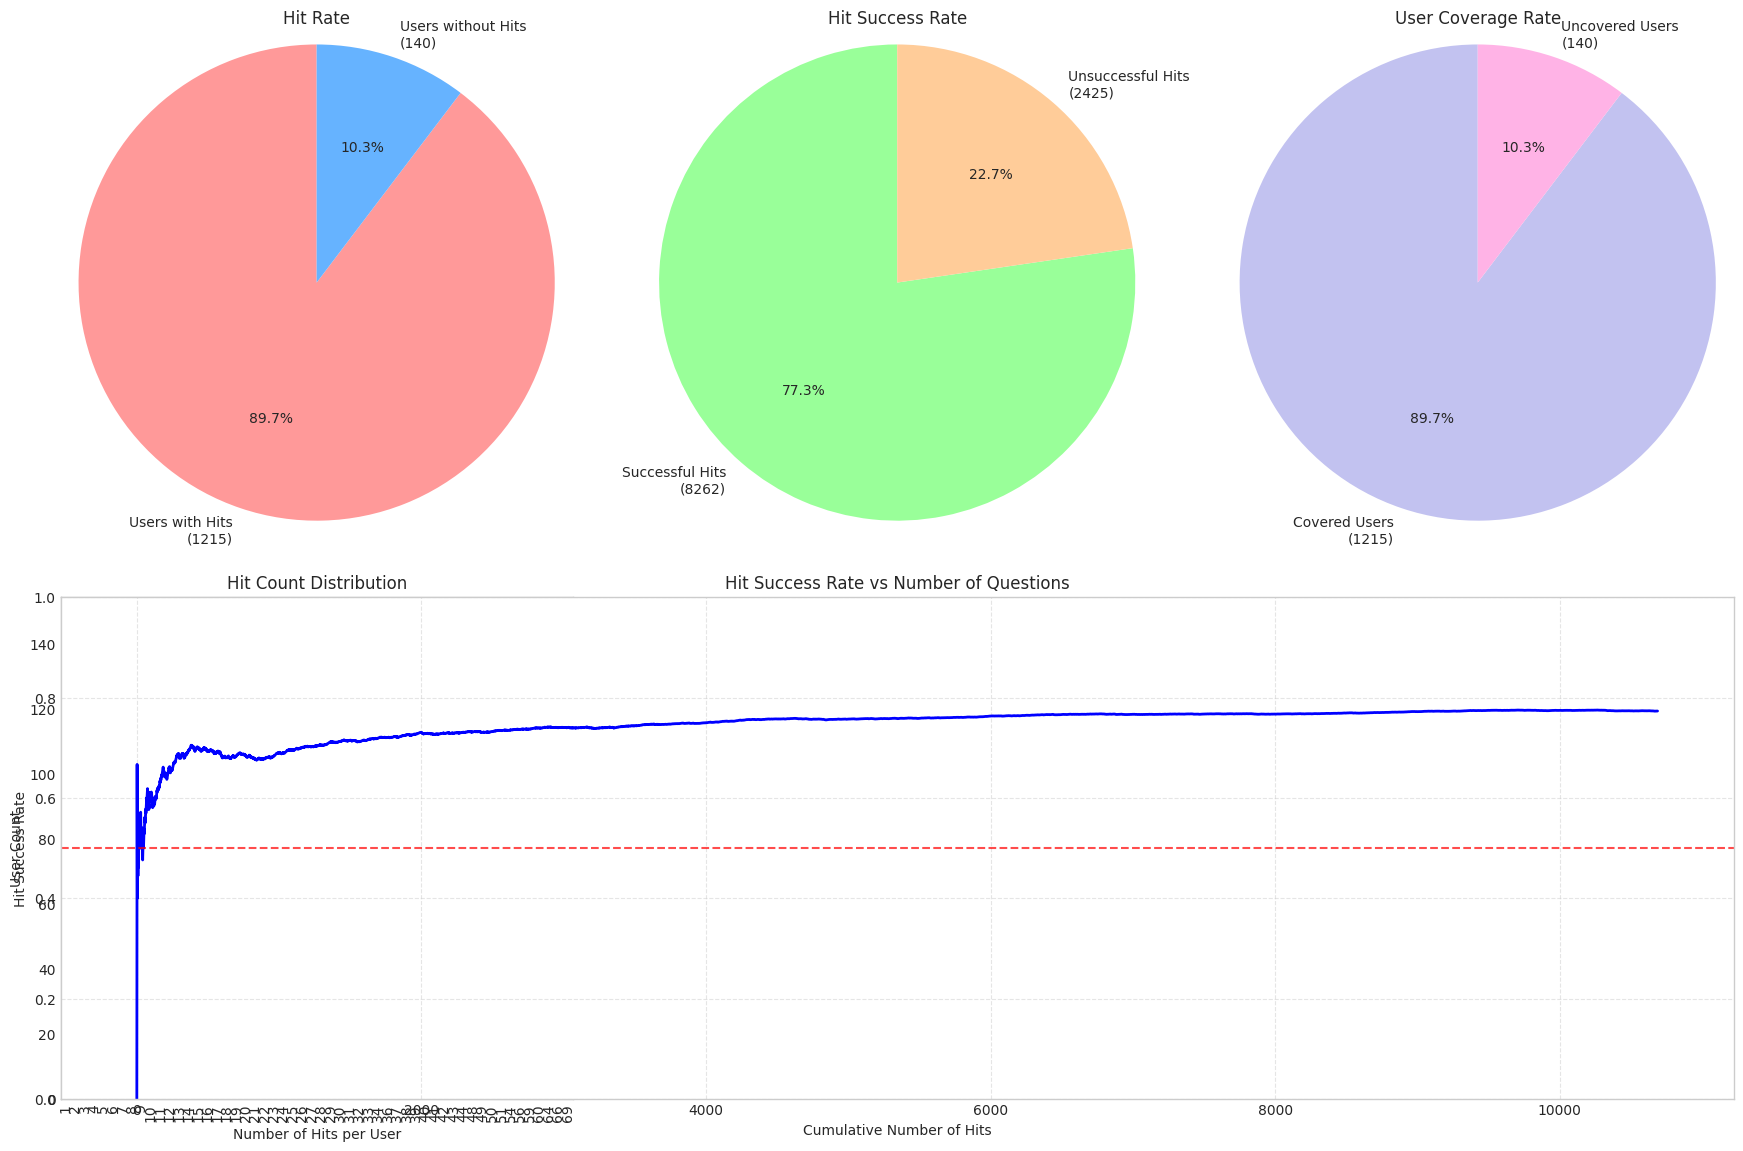

In [48]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import json
import warnings
import torch.nn as nn
import os
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

warnings.filterwarnings('ignore')

# Set font for English support
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# --- Configuration Classes ---
class AnalysisConfig:
    TEST_FILE_PATH = "data/XES3G5M/kc_level/test.csv"
    QUESTIONS_META_PATH = 'data/XES3G5M/metadata/questions.json'
    MAX_LENGTH = 120
    MAX_DAYS = 90
    PREDICTION_THRESHOLD = 0.1
    MODEL_PATH = "saved_models/adgkt_model_epoch10.pth"
    QID_MAP_PATH = "saved_models/qid_map.json"
    CID_MAP_PATH = "saved_models/cid_map.json"
    TRAINING_CONFIG_PATH = "saved_models/training_config.json"

analysis_config = AnalysisConfig()
analysis_config.MAX_TIME_DIFF_MS = analysis_config.MAX_DAYS * 24 * 60 * 60 * 1000

# --- Model Definition (ADGKT) ---
class ADGKT(nn.Module):
    def __init__(self, num_q, num_c, embed_size, hidden_size, num_heads, dropout):
        super(ADGKT, self).__init__()
        self.num_q = num_q
        self.num_c = num_c
        self.q_embed = nn.Embedding(num_q, embed_size)
        self.c_embed = nn.Embedding(num_c, embed_size)
        self.r_embed = nn.Embedding(2, embed_size)
        self.interaction_fusion = nn.Linear(embed_size * 2, hidden_size)
        self.attention = nn.MultiheadAttention(hidden_size, num_heads, dropout=dropout, batch_first=True)
        self.gru = nn.GRU(hidden_size, hidden_size, batch_first=True)
        self.predict_fusion = nn.Linear(hidden_size * 2, hidden_size)
        self.out = nn.Linear(hidden_size, 1)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm1 = nn.LayerNorm(hidden_size)
        self.layer_norm2 = nn.LayerNorm(hidden_size)

    def forward(self, input_q, input_c, input_r, target_q, target_c):
        q_emb = self.q_embed(input_q)
        c_emb = self.c_embed(input_c)
        r_emb = self.r_embed(input_r)
        interaction_emb = self.interaction_fusion(torch.cat([q_emb, c_emb], dim=-1)) + r_emb
        attn_input = self.layer_norm1(interaction_emb)
        attn_output, _ = self.attention(attn_input, attn_input, attn_input)
        attn_output = self.dropout(attn_output) + interaction_emb
        gru_input = self.layer_norm2(attn_output)
        gru_output, _ = self.gru(gru_input)
        target_q_emb = self.q_embed(target_q)
        target_c_emb = self.c_embed(target_c)
        predict_input = torch.cat([gru_output, target_q_emb + target_c_emb], dim=-1)
        predict_hidden = torch.relu(self.predict_fusion(predict_input))
        output = self.out(predict_hidden)
        return torch.sigmoid(output).squeeze(-1)

# --- Validation Analysis Function ---
def run_sequential_validation(model, test_df, config, analysis_config, qid_to_module_map, device, qid_map, cid_map):
    """Run sequential validation to detect difficult questions"""
    model.eval()
    results = {
        'total_users': len(test_df),
        'hit_events': [],  # Store all hit events
        'user_hit_counts': defaultdict(int),
        'total_predictions': 0
    }
    print(f"\nStarting sequential validation for {len(test_df)} users...")
    
    for index, row in tqdm(test_df.iterrows(), total=len(test_df)):
        q_seq = str(row['questions']).split(',')
        c_seq = str(row['concepts']).split(',')
        r_seq = [int(r) for r in str(row['responses']).split(',')]
        
        if len(q_seq) < 2:
            continue
        
        # Track hit events for this user
        user_hit_events = []
        
        for i in range(1, len(q_seq)):
            hist_q = q_seq[:i]
            hist_c = c_seq[:i]
            hist_r = r_seq[:i]
            
            target_q = q_seq[i]
            target_c = c_seq[i]
            actual_response = r_seq[i]
            
            q_hist_ids = [qid_map.get(q) for q in hist_q]
            c_hist_ids = [cid_map.get(c) for c in hist_c]
            target_q_id = qid_map.get(target_q)
            target_c_id = cid_map.get(target_c)

            if None in q_hist_ids or None in c_hist_ids or target_q_id is None or target_c_id is None:
                continue

            history_len = len(q_hist_ids)
            input_q = np.zeros(config.MAX_SEQ_LEN - 1, dtype=int)
            input_c = np.zeros(config.MAX_SEQ_LEN - 1, dtype=int)
            input_r = np.zeros(config.MAX_SEQ_LEN - 1, dtype=int)

            if history_len >= config.MAX_SEQ_LEN - 1:
                input_q[:] = q_hist_ids[-(config.MAX_SEQ_LEN - 1):]
                input_c[:] = c_hist_ids[-(config.MAX_SEQ_LEN - 1):]
                input_r[:] = hist_r[-(config.MAX_SEQ_LEN - 1):]
            else:
                input_q[-history_len:] = q_hist_ids
                input_c[-history_len:] = c_hist_ids
                input_r[-history_len:] = hist_r
            
            input_q = torch.LongTensor([input_q]).to(device)
            input_c = torch.LongTensor([input_c]).to(device)
            input_r = torch.LongTensor([input_r]).to(device)
            target_q = torch.LongTensor([target_q_id] * (config.MAX_SEQ_LEN - 1)).to(device).unsqueeze(0)
            target_c = torch.LongTensor([target_c_id] * (config.MAX_SEQ_LEN - 1)).to(device).unsqueeze(0)

            with torch.no_grad():
                pred_prob = model(input_q, input_c, input_r, target_q, target_c)
                final_pred = pred_prob[0, -1].item()
            
            results['total_predictions'] += 1
            
            # Record hit event
            if final_pred <= analysis_config.PREDICTION_THRESHOLD:
                hit_event = {
                    'user_index': index,
                    'step': i,
                    'qid': target_q,
                    'predicted_prob': final_pred,
                    'actual_response': actual_response
                }
                user_hit_events.append(hit_event)
                results['user_hit_counts'][index] += 1
        
        # Save user hit events
        results['hit_events'].extend(user_hit_events)
    
    return results

# --- Helper functions ---
def load_id_maps():
    """Load question and concept ID mappings"""
    with open(analysis_config.QID_MAP_PATH, "r") as f:
        qid_map = json.load(f)
    with open(analysis_config.CID_MAP_PATH, "r") as f:
        cid_map = json.load(f)
    return qid_map, cid_map

def load_training_config():
    """Load model training configuration"""
    with open(analysis_config.TRAINING_CONFIG_PATH, "r") as f:
        config_data = json.load(f)
    class TrainingConfig: pass
    config = TrainingConfig()
    for key, value in config_data.items():
        setattr(config, key, value)
    return config
   
def clean_test_data(test_df_raw, qid_to_module_map, known_qids):
    """Clean and filter test data"""
    print(f"\nCleaning test data... (Original size: {len(test_df_raw)} rows)")
    processed_rows = []
    for index, row in tqdm(test_df_raw.iterrows(), total=len(test_df_raw)):
        new_row = row.copy()
        questions_list = str(row['questions']).split(',')
        keep_mask = [qid in known_qids for qid in questions_list]

        if not any(keep_mask): continue

        for col in ['questions', 'responses', 'timestamps']:
            original_list = str(row[col]).split(',')
            if len(original_list) == len(questions_list):
                filtered_list = [item for item, keep in zip(original_list, keep_mask) if keep]
                new_row[col] = ','.join(filtered_list)
        
        filtered_qids = new_row['questions'].split(',')
        new_concepts = [qid_to_module_map.get(qid, 'Unknown') for qid in filtered_qids]
        new_row['concepts'] = ','.join(new_concepts)
        
        if len(filtered_qids) > analysis_config.MAX_LENGTH:
            for col in ['questions', 'concepts', 'responses', 'timestamps']:
                new_row[col] = ','.join(new_row[col].split(',')[:analysis_config.MAX_LENGTH])

        if 'timestamps' in new_row and pd.notna(new_row['timestamps']):
            timestamps_list = [int(ts) for ts in str(new_row['timestamps']).split(',') if ts]
            if len(timestamps_list) > 1:
                if (timestamps_list[-1] - timestamps_list[0]) > analysis_config.MAX_TIME_DIFF_MS:
                    continue
        
        processed_rows.append(new_row)
    
    cleaned_df = pd.DataFrame(processed_rows)
    print(f"Cleaning complete. Remaining rows: {len(cleaned_df)}")
    return cleaned_df

# --- Visualization Functions ---
def visualize_results(results):
    """Create simplified visualizations of results"""
    plt.figure(figsize=(18, 12))
    
    # 1. Hit Rate (Pie Chart)
    plt.subplot(2, 3, 1)
    users_with_hits = len(results['user_hit_counts'])
    users_without_hits = results['total_users'] - users_with_hits
    sizes = [users_with_hits, users_without_hits]
    labels = [f'Users with Hits\n({users_with_hits})', f'Users without Hits\n({users_without_hits})']
    colors = ['#ff9999','#66b3ff']
    
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    plt.axis('equal')
    plt.title('Hit Rate')
    
    # 2. Hit Success Rate (Pie Chart)
    plt.subplot(2, 3, 2)
    if results['hit_events']:
        hit_df = pd.DataFrame(results['hit_events'])
        successful_hits = hit_df[hit_df['actual_response'] == 0].shape[0]
        unsuccessful_hits = len(results['hit_events']) - successful_hits
        sizes = [successful_hits, unsuccessful_hits]
        labels = [f'Successful Hits\n({successful_hits})', f'Unsuccessful Hits\n({unsuccessful_hits})']
        colors = ['#99ff99','#ffcc99']
        
        plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
        plt.title('Hit Success Rate')
    else:
        plt.text(0.5, 0.5, "No hit events", ha='center')
    plt.axis('equal')
    
    # 3. User Coverage Rate (Pie Chart)
    plt.subplot(2, 3, 3)
    coverage_rate = users_with_hits / results['total_users'] if results['total_users'] > 0 else 0
    sizes = [coverage_rate, 1 - coverage_rate]
    labels = [f'Covered Users\n({users_with_hits})', f'Uncovered Users\n({users_without_hits})']
    colors = ['#c2c2f0','#ffb3e6']
    
    plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    plt.axis('equal')
    plt.title('User Coverage Rate')
    
    # 4. Hit Count Distribution (Bar Chart)
    plt.subplot(2, 3, 4)
    hit_counts = list(results['user_hit_counts'].values())
    if hit_counts:
        count_distribution = pd.Series(hit_counts).value_counts().sort_index()
        count_distribution.plot(kind='bar', color='#66b3ff')
        plt.xlabel('Number of Hits per User')
        plt.ylabel('User Count')
        plt.title('Hit Count Distribution')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
    else:
        plt.text(0.5, 0.5, "No hit data", ha='center')
    
    # 5. Hit Success Rate vs Question Sequence (Line Chart)
    plt.subplot(2, 1, 2)
    if results['hit_events']:
        hit_df = pd.DataFrame(results['hit_events'])
        
        # Sort by step and calculate cumulative success rate
        hit_df = hit_df.sort_values('step')
        hit_df['cumulative_hits'] = range(1, len(hit_df) + 1)
        hit_df['cumulative_success'] = (hit_df['actual_response'] == 0).cumsum()
        hit_df['success_rate'] = hit_df['cumulative_success'] / hit_df['cumulative_hits']
        
        plt.plot(hit_df['cumulative_hits'], hit_df['success_rate'], 'b-', linewidth=2)
        plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.7)
        plt.xlabel('Cumulative Number of Hits')
        plt.ylabel('Hit Success Rate')
        plt.title('Hit Success Rate vs Number of Questions')
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.ylim(0, 1)
    else:
        plt.text(0.5, 0.5, "No hit events", ha='center')
    
    plt.tight_layout()
    plt.savefig('simplified_analysis_results.png', dpi=300)
    plt.show()

# --- Main Execution ---
if __name__ == "__main__":
    print("=" * 60)
    print("Starting Validation Analysis")
    print("=" * 60)
    
    try:
        # Load necessary files
        qid_map, cid_map = load_id_maps()
        config = load_training_config()
        test_df_raw = pd.read_csv(analysis_config.TEST_FILE_PATH)
        
        # Concept translation dictionary
        module_translation = {
           "Geometry": "Geometry",
           "Application Problems": "Application Problems",
           "Number Theory": "Number Theory",
           "Combinatorics": "Combinatorics",
           "Journey Problems": "Journey Problems",
           "Counting": "Counting",
           "Calculation": "Calculation",
        }
        
        # Load question metadata
        with open(analysis_config.QUESTIONS_META_PATH, 'r', encoding='utf-8') as f:
            questions_data = json.load(f)
        
        # Create question to module mapping
        qid_to_module_map = {}
        for qid, details in questions_data.items():
            routes = details.get('kc_routes', [])
            for path in routes:
                parts = path.split('----')
                if parts[0] == '拓展思维' and len(parts) > 1:
                    qid_to_module_map[qid] = module_translation.get(parts[1], parts[1])
                    break
        
        # Clean the test data
        cleaned_test_df = clean_test_data(test_df_raw, qid_to_module_map, set(qid_map.keys()))
        
        if cleaned_test_df.empty:
            print("No data left after cleaning. Exiting.")
        else:
            # Setup model and device
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
            num_questions = len(qid_map)
            num_concepts = len(cid_map)
            model = ADGKT(num_questions, num_concepts, config.EMBED_SIZE, 
                          config.HIDDEN_SIZE, config.NUM_HEADS, config.DROPOUT).to(device)
            model.load_state_dict(torch.load(analysis_config.MODEL_PATH, map_location=device))
            
            # Run the validation
            results = run_sequential_validation(model, cleaned_test_df, config, 
                                               analysis_config, qid_to_module_map, 
                                               device, qid_map, cid_map)
            
            # Output statistics
            print("\n" + "=" * 60)
            print("Analysis Results Summary")
            print("=" * 60)
            
            # Calculate key metrics
            total_users = results['total_users']
            users_with_hits = len(results['user_hit_counts'])
            hit_events = results['hit_events']
            total_hits = len(hit_events)
            successful_hits = sum(1 for event in hit_events if event['actual_response'] == 0)
            
            # Print metrics
            print(f"Total Users: {total_users}")
            print(f"Users with Hits: {users_with_hits} ({users_with_hits/total_users:.1%})")
            print(f"Total Hit Events: {total_hits}")
            if total_hits > 0:
                print(f"Successful Hits: {successful_hits} ({successful_hits/total_hits:.1%})")
                print(f"Unsuccessful Hits: {total_hits - successful_hits} ({(total_hits - successful_hits)/total_hits:.1%})")
            
            # Visualize results
            visualize_results(results)

    except Exception as e:
        print(f"\nAn error occurred during analysis: {e}")
        import traceback
        traceback.print_exc()


This step is the evaluation and recommendation process for cold start scenarios: take new users from test.csv, which has no user overlap with the training set, and use only a small amount of historical interaction visible in the test file as model input to prohibit the disclosure of user information during any training period; During cleaning, only the topics and modules seen in the training phase are retained, ensuring that the user cold start is not the topic cold start; Then, batch prediction is made for all the outstanding questions of these new users, and recommendations of "most likely to make mistakes" are generated according to the threshold or top-k. indicators such as coverage, hits per capita, and the actual error rate of hit sets are counted, so as to test whether the model can quickly locate weak points on new users and give effective recommendations to promote learning with mistakes.

## 4. Conclusion
This project focuses on the real scene of "personalized practice of mathematics in grade three", and puts forward a topic recommendation system with "prediction error" as the core: according to the students' historical answer sequence, directly pick out the "most likely to make mistakes" topic, help them jump out of the comfort zone and accurately make up for the weak. In terms of data, based on xes3g5m, we constructed a "topic → knowledge path (extended thinking → sub module)" mapping from the topic metadata, only retaining the "extended thinking" field and completing strict cleaning: the active user sequence is limited to 120, the time span is ≤ 90 days, and the fine-grained concept is aggregated into seven high-level modules. Finally, about 10000 level high-quality sequences are obtained for modeling. Methodologically, taking DKT as the baseline, adgkt combined with topic/module/answer three-way embedding is realized: multi head self attention capture long-range dependence, Gru represents the state evolution, and the "student state" and "target topic embedding" are fused to output the next correct answer probability. The evaluation adopts "sequential verification" rather than random segmentation, plus independent cold start test and multi threshold analysis: adgkt is significantly better than DKT in AUC (baseline is about 0.82, adgkt is about 0.87 – 0.96, which fluctuates with different data slices and rounds). When the threshold is set to P ≤ 0.1, the true error rate of the topic "hit" by the model is about 74% -77%, and the coverage is usually within the range of~85% -90% of users. On average, a single user can identify~8 weak points; Multi threshold comparison shows that the threshold ↑ can be exchanged for higher coverage and hit volume, but the hit accuracy will decline, and there is a typical accuracy coverage trade-off. Visualization and diagnosis further revealed that the hit locations were evenly distributed in the sequence, there were some signs of "uncalibration" in the low probability segment, and the data were significantly long tailed at the module and topic levels (the proportion of expanding thinking questions was very high), which might amplify the model's preference for head distribution. In general, the adgkt+Sequential verification has confirmed the effectiveness and availability of "promoting learning through mistakes": it can not only maintain high discrimination and business value (high precision and high coverage) under offline conditions, but also expose Engineering/research improvement points such as probability calibration, item order effect and distribution imbalance, providing a clear basis and landing direction for the subsequent threshold strategy, confidence calibration and hierarchical evaluation before going online.

## 5. Discussion
The project goal is basically aligned with the sequential evaluation, but there are still some problems, such as the probability is not calibrated, the instability caused by the inconsistency between the topic and concept mapping link, the rough choice of coverage and accuracy threshold, and the lack of long tail distribution and interpretability. Facing the future, we should focus on promoting the calibration and personalized threshold, and guide the threshold setting with the reliability curve and utility trade-off; Turn from point prediction to sorting learning, and directly optimize the more error prone problems with more attention to the loss of difficult cases and sorting ability; Uncertainty estimation is introduced to improve robustness and cold start performance; On the data and engineering side, unify a single true source of topics and concepts and enforce consistency verification, establish automatic diagnostic reports and efficient batch scoring and caching, and realize light deployment with model distillation; Turn attention and similar history into readable explanations in the teaching closed loop, carry out online evaluation with learning gain as the core index, set up difficulty climbing and psychological burden barriers, and continuously monitor fairness and privacy. The core landing point is calibration, personalized threshold and sorting optimization, and then superimposed with robust data engineering and online evaluation, so that offline feasibility can be precipitated into continuous learning gain.